# LLaMA-3-8B-Instruct Official RAGTruth Detector and SQuAD-v2 Controller with Signal Ablation

This notebook is designed for a **Google Colab A100** runtime.

## Frozen detector protocol

- Train the CEV and IAV probes on all 15,090 official
  `wandb/RAGTruth-processed` training examples.
- Select epochs, temperatures, fusion, Platt calibration, and detector
  thresholds only from training-set out-of-fold predictions.
- Evaluate once on the untouched 2,700-example official RAGTruth test split.

## SQuAD-v2-only controller protocol

- Divide SQuAD-v2 training data into disjoint retrieval-calibration,
  answerability-calibration, and candidate-quality/controller subsets.
- Use SQuAD-v2 validation only for the final balanced answerable/unanswerable
  benchmark.
- Treat the auxiliary NLI and cross-encoder outputs as support and relevance
  scores, not as calibrated probabilities.
- Evaluate answerability accuracy, false-answer rate, false abstention,
  answerable coverage, answer quality, latency, and paired bootstrap intervals.
- Select varied qualitative demonstrations automatically from the frozen final
  evaluation rather than using manually written demo questions.

## Signal ablation

The notebook compares:

1. vanilla LLaMA delivery;
2. answerability gating only;
3. external verification without CEV/IAV;
4. full first-pass signals with CEV/IAV;
5. the complete multi-action Controller-v5.

Rows 3 and 4 use the same frozen first-pass response, so their paired difference
isolates the contribution of the internal CEV/IAV signal.

## Optional cross-domain diagnostic

- HaluEval-QA is optional and controlled by `config.run_optional_halueval`.
- It is never used for detector training, calibration, controller development,
  or threshold selection.
- When enabled, it reports CEV, IAV, and fused cross-domain AUROC with ROC
  curves.

## 1. Install dependencies

In [1]:
!pip -q install -U \
    "transformers>=4.51.0,<5.0.0" \
    "datasets>=3.0.0,<5.0.0" \
    "accelerate>=1.0.0,<2.0.0" \
    "sentence-transformers>=3.0.0,<6.0.0" \
    "faiss-cpu>=1.8.0,<2.0.0" \
    "rank-bm25>=0.2.2,<1.0.0" \
    "scikit-learn>=1.5.0,<2.0.0" \
    "scipy>=1.13.0,<2.0.0" \
    "pandas>=2.0.0,<3.0.0" \
    "matplotlib>=3.8.0,<4.0.0" \
    "tqdm>=4.66.0,<5.0.0" \
    "safetensors>=0.4.0,<1.0.0" \
    "sentencepiece>=0.2.0,<1.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 145.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 123.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 152.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 143.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Imports, Google Drive, reproducibility, and configuration

In [2]:
import gc
import hashlib
import json
import math
import os
import pickle
import random
import re
import string
import time
from collections import Counter
from copy import deepcopy
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from datasets import Dataset, load_dataset
from rank_bm25 import BM25Okapi
from scipy.optimize import minimize_scalar
from scipy.special import expit, logsumexp
from sentence_transformers import CrossEncoder, SentenceTransformer
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoModelForQuestionAnswering,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_cosine_schedule_with_warmup,
)

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    IN_COLAB = True
except Exception:
    IN_COLAB = False

os.environ.setdefault(
    "PYTORCH_CUDA_ALLOC_CONF",
    "expandable_segments:True",
)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


@dataclass
class Config:
    # Backbone and generation
    model_name: str = "meta-llama/Meta-Llama-3-8B-Instruct"
    max_context_length: int = 2048
    generation_max_new_tokens: int = 32
    generation_do_sample: bool = False
    regeneration_max_new_tokens: int = 32
    regeneration_do_sample: bool = False
    query_rewrite_max_new_tokens: int = 40
    response_max_words: int = 20

    # Probe architecture and official RAGTruth protocol
    probe_hidden_size: int = 256
    feature_batch_size: int = 4
    feature_cache_dtype: str = "float16"
    probe_batch_size: int = 256
    probe_lr: float = 1e-3
    probe_weight_decay: float = 1e-4
    probe_max_epochs: int = 25
    probe_patience: int = 5
    oof_folds: int = 3
    label_smoothing: float = 0.05
    probe_text_builder_version: str = "context_query_response_v2"
    fusion_grid_points: int = 101
    abstain_precision_target: float = 0.90

    # SQuAD-v2-only retrieval and controller protocol
    embedding_model: str = "BAAI/bge-base-en-v1.5"
    reranker_model: str = "cross-encoder/ms-marco-MiniLM-L6-v2"
    retrieval_query_instruction: str = (
        "Represent this sentence for searching relevant passages: "
    )
    retrieval_k: int = 5
    max_retrieval_k: int = 10
    retrieval_candidate_pool: int = 30
    reretrieval_candidate_pool: int = 60
    retrieval_context_max_characters: int = 6000
    retrieval_quality_top_n: int = 3
    squad_v2_train_distractor_contexts: int = 25000
    bm25_rrf_constant: int = 60
    use_bm25_for_reretrieval: bool = True

    # Disjoint SQuAD-v2 training partitions
    retrieval_calibration_queries: int = 1500
    retrieval_oof_folds: int = 5
    retrieval_failure_threshold: float = 0.50

    answerability_examples_per_class: int = 750
    answerability_oof_folds: int = 5
    answerable_coverage_target: float = 0.95
    no_answer_threshold: float = 0.50

    controller_dev_answerable_queries: int = 500
    controller_dev_unanswerable_queries: int = 500
    candidate_quality_oof_folds: int = 5
    controller_bad_answer_f1_threshold: float = 0.50
    controller_min_answerable_coverage: float = 0.70
    controller_max_unanswerable_false_answer_rate: float = 0.15
    candidate_bad_accept_threshold: float = 0.50
    candidate_bad_abstain_threshold: float = 0.80

    # Support/relevance are diagnostic features, not hard acceptance gates
    support_diagnostic_threshold: float = 0.10
    relevance_diagnostic_threshold: float = 0.20

    # Controller-v5 auxiliary models
    qa_model_name: str = "deepset/roberta-base-squad2"
    support_model_name: str = "cross-encoder/nli-deberta-v3-small"
    controller_aux_device: str = "cuda"
    qa_max_length: int = 384
    qa_doc_stride: int = 128
    qa_max_answer_length: int = 30
    qa_top_documents: int = 2
    support_top_documents: int = 3

    # Deterministic action budget
    controller_code_version: str = "controller_v5_squadv2_paper_llama3_ablation_v2"
    max_attempts: int = 3
    max_regenerations: int = 1
    max_reretrievals: int = 1

    # Fresh SQuAD-v2 final evaluation.
    # Previous V4 and previous V5 samples are reconstructed and excluded.
    previous_v4_squad_v2_answerable: int = 300
    previous_v4_squad_v2_unanswerable: int = 300
    previous_v4_squad_v2_seed: int = 4042
    previous_v5_squad_v2_answerable: int = 400
    previous_v5_squad_v2_unanswerable: int = 400
    previous_v5_squad_v2_seed: int = 6061

    squad_v2_answerable_eval_queries: int = 500
    squad_v2_unanswerable_eval_queries: int = 500
    squad_v2_eval_seed: int = 7071

    # Optional HaluEval cross-domain diagnostic
    run_optional_halueval: bool = True
    halueval_eval_pairs: int = 10000
    halueval_batch_size: int = 8
    halueval_seed: int = 8081

    # Statistics
    bootstrap_samples: int = 1000
    random_seed: int = 42

    # Storage
    run_name: str = "llama_ragtruth_controller_v5_squadv2_paper_ablation"
    base_dir: str = (
        "/content/drive/MyDrive/llama_colab_a100_ragtruth18k_test_run"
        if IN_COLAB
        else "/content/llama_colab_a100_ragtruth18k_test_run"
    )

    # Filled after detector fitting
    hidden_size: int = 0
    intermediate_size: int = 0
    target_layer: int = -1
    cev_temperature: float = 1.0
    iav_temperature: float = 1.0
    fusion_weight_cev: float = 0.5
    platt_a: float = 1.0
    platt_b: float = 0.0
    hallucination_threshold: float = 0.5
    abstain_threshold: float = 0.8

config = Config()

BASE_DIR = Path(config.base_dir)
CACHE_DIR = BASE_DIR / "feature_cache"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
OUTPUT_DIR = BASE_DIR / "outputs"
CONTROLLER_OUTPUT_DIR = BASE_DIR / "controller_v5_squadv2_paper_ablation_outputs"
TRACE_DIR = CONTROLLER_OUTPUT_DIR / "traces"
DEMO_DIR = CONTROLLER_OUTPUT_DIR / "controller_demonstrations"
SQUAD_V2_DIR = CONTROLLER_OUTPUT_DIR / "squad_v2_evaluation"
HALUEVAL_DIR = CONTROLLER_OUTPUT_DIR / "optional_halueval"

for directory in (
    BASE_DIR,
    CACHE_DIR,
    CHECKPOINT_DIR,
    OUTPUT_DIR,
    CONTROLLER_OUTPUT_DIR,
    TRACE_DIR,
    DEMO_DIR,
    SQUAD_V2_DIR,
    HALUEVAL_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def cuda_sync() -> None:
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def json_safe(value: Any) -> Any:
    if isinstance(value, dict):
        return {
            str(key): json_safe(item)
            for key, item in value.items()
        }
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, np.ndarray):
        return [
            json_safe(item)
            for item in value.tolist()
        ]
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, (np.floating, float)):
        numeric = float(value)
        return (
            None
            if not math.isfinite(numeric)
            else numeric
        )
    if isinstance(value, (np.bool_, bool)):
        return bool(value)
    if isinstance(value, Path):
        return str(value)
    return value


def write_json(
    path: Path,
    payload: Any,
) -> None:
    path.write_text(
        json.dumps(
            json_safe(payload),
            indent=2,
            allow_nan=False,
        ),
        encoding="utf-8",
    )


seed_everything(config.random_seed)

print(json.dumps({
    "run_name": config.run_name,
    "base_dir": str(BASE_DIR),
    "cuda_available": torch.cuda.is_available(),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "controller_dataset": "SQuAD v2 only",
    "retrieval_calibration_queries": (
        config.retrieval_calibration_queries
    ),
    "answerability_examples": (
        2 * config.answerability_examples_per_class
    ),
    "controller_development_examples": (
        config.controller_dev_answerable_queries
        + config.controller_dev_unanswerable_queries
    ),
    "fresh_squad_v2_evaluation_queries": (
        config.squad_v2_answerable_eval_queries
        + config.squad_v2_unanswerable_eval_queries
    ),
    "optional_halueval_enabled": (
        config.run_optional_halueval
    ),
}, indent=2))


Mounted at /content/drive
{
  "run_name": "llama_ragtruth_controller_v5_squadv2_paper_ablation",
  "base_dir": "/content/drive/MyDrive/llama_colab_a100_ragtruth18k_test_run",
  "cuda_available": true,
  "gpu": "NVIDIA A100-SXM4-40GB",
  "controller_dataset": "SQuAD v2 only",
  "retrieval_calibration_queries": 1500,
  "answerability_examples": 1500,
  "controller_development_examples": 1000,
  "fresh_squad_v2_evaluation_queries": 1000,
  "optional_halueval_enabled": true
}


## 3. Load RAGTruth and construct disjoint SQuAD-v2-only controller partitions

RAGTruth remains the sole detector-supervision benchmark. SQuAD v2 is the sole
controller-development and controller-evaluation dataset. Its training split is
divided deterministically into mutually disjoint retrieval-calibration,
answerability-calibration, and controller-quality subsets.

In [3]:
print("Loading official datasets...")

ragtruth_data = load_dataset(
    "wandb/RAGTruth-processed"
)
squad_v2_train = load_dataset(
    "rajpurkar/squad_v2",
    split="train",
)
squad_v2_validation = load_dataset(
    "rajpurkar/squad_v2",
    split="validation",
)

required_ragtruth_splits = {
    "train",
    "test",
}
missing_splits = (
    required_ragtruth_splits
    .difference(
        ragtruth_data.keys()
    )
)
if missing_splits:
    raise RuntimeError(
        "Missing RAGTruth split(s): "
        f"{sorted(missing_splits)}"
    )

print("\nRAGTruth")
print(
    f"  train: "
    f"{len(ragtruth_data['train']):,}"
)
print(
    f"  test : "
    f"{len(ragtruth_data['test']):,}"
)
print(
    "  columns: "
    f"{ragtruth_data['train'].column_names}"
)

print("\nSQuAD v2")
print(
    f"  train     : "
    f"{len(squad_v2_train):,}"
)
print(
    f"  validation: "
    f"{len(squad_v2_validation):,}"
)

assert len(
    ragtruth_data["train"]
) == 15090
assert len(
    ragtruth_data["test"]
) == 2700
assert len(
    squad_v2_train
) > 0
assert len(
    squad_v2_validation
) > 0

squad_v2_train_answerable_all = [
    index
    for index, answers
    in enumerate(
        squad_v2_train["answers"]
    )
    if len(
        answers.get("text", [])
    ) > 0
]
squad_v2_train_unanswerable_all = [
    index
    for index, answers
    in enumerate(
        squad_v2_train["answers"]
    )
    if len(
        answers.get("text", [])
    ) == 0
]

rng_partition = np.random.default_rng(
    config.random_seed + 77
)
answerable_permutation = (
    rng_partition.permutation(
        squad_v2_train_answerable_all
    )
    .astype(int)
    .tolist()
)
unanswerable_permutation = (
    rng_partition.permutation(
        squad_v2_train_unanswerable_all
    )
    .astype(int)
    .tolist()
)

answerability_answerable_count = int(
    min(
        config.answerability_examples_per_class,
        len(answerable_permutation),
    )
)
answerability_unanswerable_count = int(
    min(
        config.answerability_examples_per_class,
        len(unanswerable_permutation),
    )
)
retrieval_count = int(
    min(
        config.retrieval_calibration_queries,
        max(
            0,
            len(answerable_permutation)
            - answerability_answerable_count,
        ),
    )
)
controller_answerable_count = int(
    min(
        config.controller_dev_answerable_queries,
        max(
            0,
            len(answerable_permutation)
            - answerability_answerable_count
            - retrieval_count,
        ),
    )
)
controller_unanswerable_count = int(
    min(
        config.controller_dev_unanswerable_queries,
        max(
            0,
            len(unanswerable_permutation)
            - answerability_unanswerable_count,
        ),
    )
)

selected_answerable_train = (
    answerable_permutation[
        :answerability_answerable_count
    ]
)
selected_unanswerable_train = (
    unanswerable_permutation[
        :answerability_unanswerable_count
    ]
)
answerability_indices = sorted(
    selected_answerable_train
    + selected_unanswerable_train
)

retrieval_start = (
    answerability_answerable_count
)
retrieval_end = (
    retrieval_start
    + retrieval_count
)
selected_retrieval_calibration_indices = (
    answerable_permutation[
        retrieval_start:retrieval_end
    ]
)

controller_answerable_start = (
    retrieval_end
)
controller_answerable_end = (
    controller_answerable_start
    + controller_answerable_count
)
controller_dev_answerable_indices = (
    answerable_permutation[
        controller_answerable_start:
        controller_answerable_end
    ]
)

controller_unanswerable_start = (
    answerability_unanswerable_count
)
controller_unanswerable_end = (
    controller_unanswerable_start
    + controller_unanswerable_count
)
controller_dev_unanswerable_indices = (
    unanswerable_permutation[
        controller_unanswerable_start:
        controller_unanswerable_end
    ]
)
controller_dev_indices = sorted(
    controller_dev_answerable_indices
    + controller_dev_unanswerable_indices
)

if (
    len(
        selected_retrieval_calibration_indices
    )
    != config.retrieval_calibration_queries
):
    raise RuntimeError(
        "Insufficient answerable SQuAD-v2 "
        "training rows for retrieval calibration."
    )
if (
    len(
        controller_dev_answerable_indices
    )
    != config.controller_dev_answerable_queries
    or len(
        controller_dev_unanswerable_indices
    )
    != config.controller_dev_unanswerable_queries
):
    raise RuntimeError(
        "Insufficient SQuAD-v2 training rows "
        "for controller development."
    )

answerability_set = set(
    answerability_indices
)
retrieval_set = set(
    selected_retrieval_calibration_indices
)
controller_dev_set = set(
    controller_dev_indices
)

assert answerability_set.isdisjoint(
    retrieval_set
)
assert answerability_set.isdisjoint(
    controller_dev_set
)
assert retrieval_set.isdisjoint(
    controller_dev_set
)

squad_v2_partition_metadata = {
    "source": "rajpurkar/squad_v2:train",
    "answerability_answerable": len(
        selected_answerable_train
    ),
    "answerability_unanswerable": len(
        selected_unanswerable_train
    ),
    "retrieval_calibration_answerable": len(
        selected_retrieval_calibration_indices
    ),
    "controller_dev_answerable": len(
        controller_dev_answerable_indices
    ),
    "controller_dev_unanswerable": len(
        controller_dev_unanswerable_indices
    ),
    "all_partitions_pairwise_disjoint": True,
    "partition_seed": (
        config.random_seed + 77
    ),
}
write_json(
    CONTROLLER_OUTPUT_DIR
    / "squad_v2_training_partitions.json",
    squad_v2_partition_metadata,
)

print(
    json.dumps(
        squad_v2_partition_metadata,
        indent=2,
    )
)

Loading official datasets...


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/train-00000-of-00001.parquet:   0%|          | 0.00/22.3M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/3.88M [00:00<?, ?B/s]

...

squad_v2/train-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

squad_v2/validation-00000-of-00001.parqu(…):   0%|          | 0.00/1.35M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/130319 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11873 [00:00<?, ? examples/s]


RAGTruth
  train: 15,090
  test : 2,700
  columns: ['id', 'query', 'context', 'output', 'task_type', 'quality', 'model', 'temperature', 'hallucination_labels', 'hallucination_labels_processed', 'input_str']

SQuAD v2
  train     : 130,319
  validation: 11,873
{
  "source": "rajpurkar/squad_v2:train",
  "answerability_answerable": 750,
  "answerability_unanswerable": 750,
  "retrieval_calibration_answerable": 1500,
  "controller_dev_answerable": 500,
  "controller_dev_unanswerable": 500,
  "all_partitions_pairwise_disjoint": true,
  "partition_seed": 119
}


## 4. Build or load the SQuAD-v2-only retrieval index

The index contains all unique SQuAD-v2 validation contexts, all contexts needed
for the disjoint controller-development subsets, and additional SQuAD-v2
training contexts as distractors.

In [4]:
def ordered_unique(values: Iterable[str]) -> List[str]:
    return list(
        dict.fromkeys(
            str(value)
            for value in values
            if str(value).strip()
        )
    )


def stable_text_digest(values: Sequence[str]) -> str:
    digest = hashlib.sha256()
    for value in values:
        digest.update(str(value).encode("utf-8"))
        digest.update(b"\0")
    return digest.hexdigest()


class RAGPipeline:
    def __init__(
        self,
        embedding_model_name: str,
        query_instruction: str,
        cache_dir: Path,
        quality_top_n: int,
        context_max_characters: int,
        build_device: str = "cuda",
    ):
        self.embedding_model_name = embedding_model_name
        self.query_instruction = str(query_instruction)
        self.quality_top_n = max(1, int(quality_top_n))
        self.context_max_characters = max(1000, int(context_max_characters))

        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.index_path = self.cache_dir / "squad_v2_paper_faiss.index"
        self.docs_path = self.cache_dir / "squad_v2_paper_documents.json"
        self.meta_path = self.cache_dir / "squad_v2_paper_index_metadata.json"

        effective_device = (
            build_device
            if build_device == "cpu" or torch.cuda.is_available()
            else "cpu"
        )
        print(
            f"Loading retrieval encoder on {effective_device}: "
            f"{embedding_model_name}"
        )
        self.embed_model = SentenceTransformer(
            embedding_model_name,
            device=effective_device,
        )
        self.embed_dim = int(
            self.embed_model.get_sentence_embedding_dimension()
        )
        self.index: Optional[faiss.Index] = None
        self.documents: List[Dict[str, str]] = []
        self.index_metadata: Dict[str, Any] = {}

    def encode_documents(
        self,
        texts: Sequence[str],
        batch_size: int = 64,
        show_progress_bar: bool = False,
    ) -> np.ndarray:
        return self.embed_model.encode(
            list(texts),
            batch_size=batch_size,
            show_progress_bar=show_progress_bar,
            normalize_embeddings=True,
            convert_to_numpy=True,
        ).astype(np.float32)

    def encode_queries(
        self,
        queries: Sequence[str],
        batch_size: int = 64,
        show_progress_bar: bool = False,
    ) -> np.ndarray:
        prepared = [
            f"{self.query_instruction}{str(query).strip()}"
            for query in queries
        ]
        return self.embed_model.encode(
            prepared,
            batch_size=batch_size,
            show_progress_bar=show_progress_bar,
            normalize_embeddings=True,
            convert_to_numpy=True,
        ).astype(np.float32)

    def build_or_load(
        self,
        validation_contexts: List[str],
        training_distractors: List[str],
        batch_size: int = 64,
    ) -> None:
        documents = (
            [
                {"text": text, "source": "squad_v2_primary"}
                for text in validation_contexts
            ]
            + [
                {"text": text, "source": "squad_v2_train_distractor"}
                for text in training_distractors
            ]
        )
        document_texts = [item["text"] for item in documents]

        expected_meta = {
            "index_version": "bge_cosine_squad_v2_paper_v3",
            "embedding_model": self.embedding_model_name,
            "embedding_dim": self.embed_dim,
            "query_instruction": self.query_instruction,
            "n_validation_contexts": len(validation_contexts),
            "n_training_distractors": len(training_distractors),
            "n_documents": len(documents),
            "documents_sha256": stable_text_digest(document_texts),
        }

        can_load = False
        if (
            self.index_path.exists()
            and self.docs_path.exists()
            and self.meta_path.exists()
        ):
            try:
                saved_meta = json.loads(
                    self.meta_path.read_text(encoding="utf-8")
                )
                can_load = saved_meta == expected_meta
            except Exception:
                can_load = False

        if can_load:
            self.index = faiss.read_index(str(self.index_path))
            self.documents = json.loads(
                self.docs_path.read_text(encoding="utf-8")
            )
            if (
                int(self.index.ntotal) != len(self.documents)
                or len(self.documents) != expected_meta["n_documents"]
            ):
                raise RuntimeError(
                    "Cached FAISS index/document count mismatch."
                )
            print(
                f"Loaded cached FAISS index with "
                f"{self.index.ntotal:,} documents."
            )
        else:
            print(
                f"Encoding {len(document_texts):,} retrieval documents..."
            )
            embeddings = self.encode_documents(
                document_texts,
                batch_size=batch_size,
                show_progress_bar=True,
            )

            index = faiss.IndexFlatIP(self.embed_dim)
            index.add(embeddings)

            self.index = index
            self.documents = documents
            faiss.write_index(self.index, str(self.index_path))
            self.docs_path.write_text(
                json.dumps(self.documents),
                encoding="utf-8",
            )
            write_json(self.meta_path, expected_meta)
            print(
                f"Saved FAISS index with "
                f"{self.index.ntotal:,} documents."
            )

        self.index_metadata = expected_meta

        # Free A100 memory before loading LLaMA.
        self.embed_model.to("cpu")
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    def retrieve(
        self,
        query: str,
        k: int,
    ) -> List[Dict[str, Any]]:
        if self.index is None:
            raise RuntimeError("The FAISS index has not been built.")

        query_embedding = self.encode_queries(
            [query],
            show_progress_bar=False,
        )

        k = min(max(1, int(k)), int(self.index.ntotal))
        scores, indices = self.index.search(query_embedding, k)

        results: List[Dict[str, Any]] = []
        for score, index in zip(scores[0], indices[0]):
            if index < 0:
                continue
            document = self.documents[int(index)]
            results.append({
                "text": document["text"],
                "source": document["source"],
                "score": float(score),
                "index": int(index),
            })
        return results

    def retrieval_quality(
        self,
        retrieved: Sequence[Dict[str, Any]],
    ) -> float:
        """
        Fixed-top-n mean similarity.

        Using a fixed number of leading scores prevents the quality statistic
        from falling mechanically only because retrieval depth k was expanded.
        """
        if not retrieved:
            return 0.0
        n_scores = min(self.quality_top_n, len(retrieved))
        return float(
            np.mean([
                float(item["score"])
                for item in retrieved[:n_scores]
            ])
        )

    @staticmethod
    def _query_terms(query: str) -> set:
        tokens = re.findall(r"[A-Za-z0-9]+", str(query).lower())
        stopwords = {
            "a", "an", "the", "is", "are", "was", "were", "be",
            "to", "of", "in", "on", "for", "and", "or", "what",
            "which", "who", "when", "where", "why", "how", "did",
            "does", "do", "with", "from", "by", "as",
        }
        return {
            token
            for token in tokens
            if len(token) > 2 and token not in stopwords
        }

    @classmethod
    def _query_aware_excerpt(
        cls,
        text: str,
        query: str,
        max_characters: int,
    ) -> str:
        text = " ".join(str(text).split())
        if len(text) <= max_characters:
            return text

        sentences = [
            sentence.strip()
            for sentence in re.split(r"(?<=[.!?])\s+", text)
            if sentence.strip()
        ]
        if not sentences:
            return text[:max_characters]

        query_terms = cls._query_terms(query)
        sentence_scores = []
        for index, sentence in enumerate(sentences):
            sentence_terms = set(
                re.findall(r"[A-Za-z0-9]+", sentence.lower())
            )
            overlap = len(query_terms.intersection(sentence_terms))
            sentence_scores.append((overlap, -index, index))

        best_index = max(sentence_scores)[2]
        selected = [sentences[best_index]]
        left = best_index - 1
        right = best_index + 1

        while True:
            current = " ".join(selected)
            candidates = []
            if left >= 0:
                candidates.append(("left", sentences[left]))
            if right < len(sentences):
                candidates.append(("right", sentences[right]))
            if not candidates:
                break

            added = False
            for side, sentence in candidates:
                proposed = (
                    f"{sentence} {current}"
                    if side == "left"
                    else f"{current} {sentence}"
                )
                if len(proposed) <= max_characters:
                    if side == "left":
                        selected.insert(0, sentence)
                        left -= 1
                    else:
                        selected.append(sentence)
                        right += 1
                    added = True
                    break
            if not added:
                break

        excerpt = " ".join(selected)
        if len(excerpt) > max_characters:
            excerpt = excerpt[:max_characters]
        return excerpt

    def format_context(
        self,
        retrieved: Sequence[Dict[str, Any]],
        query: str,
    ) -> str:
        """
        Include every retrieved rank within a fixed character budget.

        This prevents a larger-k re-retrieval from being a no-op because the
        first few long documents consumed the complete prompt budget.
        """
        retrieved = list(retrieved)
        if not retrieved:
            return "[No documents retrieved]"

        header_budget = sum(
            len(f"[Document {rank}]\n\n")
            for rank in range(1, len(retrieved) + 1)
        )
        available = max(
            500,
            self.context_max_characters - header_budget,
        )
        per_document = max(250, available // len(retrieved))

        parts: List[str] = []
        for rank, item in enumerate(retrieved, start=1):
            excerpt = self._query_aware_excerpt(
                item["text"],
                query=query,
                max_characters=per_document,
            )
            parts.append(f"[Document {rank}]\n{excerpt}")

        # Lowest-ranked documents are placed first and the strongest evidence
        # is nearest to the question. If tokenizer-level left truncation is
        # still necessary, it preferentially removes weaker evidence.
        return "\n\n".join(reversed(parts))


development_context_indices = sorted(
    set(
        selected_retrieval_calibration_indices
        + controller_dev_indices
    )
)
development_contexts = ordered_unique([
    squad_v2_train[
        int(index)
    ]["context"]
    for index in (
        development_context_indices
    )
])
evaluation_contexts = ordered_unique(
    squad_v2_validation[
        "context"
    ]
)
primary_contexts = ordered_unique(
    evaluation_contexts
    + development_contexts
)

all_training_contexts = ordered_unique(
    squad_v2_train["context"]
)
primary_context_set = set(
    primary_contexts
)
remaining_training_contexts = [
    context
    for context in all_training_contexts
    if context not in primary_context_set
]

rng_retrieval = np.random.default_rng(
    config.random_seed + 88
)
n_distractors = min(
    config.squad_v2_train_distractor_contexts,
    len(
        remaining_training_contexts
    ),
)
distractor_indices = (
    rng_retrieval.choice(
        len(
            remaining_training_contexts
        ),
        size=n_distractors,
        replace=False,
    )
)
training_distractors = [
    remaining_training_contexts[
        int(index)
    ]
    for index in (
        distractor_indices
    )
]

rag_pipeline = RAGPipeline(
    embedding_model_name=(
        config.embedding_model
    ),
    query_instruction=(
        config.retrieval_query_instruction
    ),
    cache_dir=(
        CACHE_DIR
        / "retrieval_squad_v2_paper"
    ),
    quality_top_n=(
        config.retrieval_quality_top_n
    ),
    context_max_characters=(
        config.retrieval_context_max_characters
    ),
    build_device="cuda",
)
rag_pipeline.build_or_load(
    validation_contexts=(
        primary_contexts
    ),
    training_distractors=(
        training_distractors
    ),
)

print({
    "unique_squad_v2_validation_contexts": (
        len(evaluation_contexts)
    ),
    "development_contexts": (
        len(development_contexts)
    ),
    "training_distractors": (
        len(training_distractors)
    ),
    "indexed_documents": (
        rag_pipeline.index.ntotal
    ),
    "index_digest": (
        rag_pipeline
        .index_metadata[
            "documents_sha256"
        ][:12]
    ),
})


Loading retrieval encoder on cuda: BAAI/bge-base-en-v1.5


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipykernel_409/657996286.py:54: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.embed_model.get_sentence_embedding_dimension()


Loaded cached FAISS index with 20,233 documents.
{'unique_squad_v2_validation_contexts': 1204, 'development_contexts': 2341, 'training_distractors': 16688, 'indexed_documents': 20233, 'index_digest': 'e4dd36df7081'}


## 5. Hybrid retrieval, reranking, and SQuAD-v2 retrieval-failure calibration

Retrieval failure is calibrated only on the disjoint answerable SQuAD-v2
training subset. The model combines dense similarity, cross-encoder reranking,
lexical overlap, and score-margin features. Corrective retrieval optionally
adds BM25 through reciprocal-rank fusion.

In [5]:
def normalize_reference_text(
    text: str,
) -> str:
    text = str(text).lower()
    text = "".join(
        character
        for character in text
        if character
        not in string.punctuation
    )
    text = re.sub(
        r"\b(a|an|the)\b",
        " ",
        text,
    )
    return " ".join(text.split())


def lexical_tokens(
    text: str,
) -> List[str]:
    return re.findall(
        r"[a-z0-9]+",
        str(text).lower(),
    )


def gold_answer_in_documents(
    gold_answers: Sequence[str],
    retrieved: Sequence[
        Dict[str, Any]
    ],
) -> bool:
    normalized_documents = [
        normalize_reference_text(
            item["text"]
        )
        for item in retrieved
    ]
    for answer in gold_answers:
        normalized_answer = (
            normalize_reference_text(
                answer
            )
        )
        if (
            normalized_answer
            and any(
                normalized_answer
                in document
                for document
                in normalized_documents
            )
        ):
            return True
    return False


def lexical_overlap_ratio(
    question: str,
    document: str,
) -> float:
    question_tokens = set(
        lexical_tokens(question)
    )
    document_tokens = set(
        lexical_tokens(document)
    )
    if not question_tokens:
        return 0.0
    return float(
        len(
            question_tokens
            .intersection(
                document_tokens
            )
        )
        / len(question_tokens)
    )


print(
    "Loading retrieval reranker on "
    f"{'cuda' if torch.cuda.is_available() else 'cpu'}: "
    f"{config.reranker_model}"
)
reranker = CrossEncoder(
    config.reranker_model,
    device=(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    ),
)

# ============================================================
# BM25 cache directory and file
# ============================================================

bm25_cache_dir = (
    CACHE_DIR
    / "retrieval"
)

# Create CACHE_DIR/retrieval when it does not already exist.
bm25_cache_dir.mkdir(
    parents=True,
    exist_ok=True,
)

bm25_cache_path = (
    bm25_cache_dir
    / "squad_v2_paper_bm25_v5.pkl"
)

bm25_expected_digest = (
    rag_pipeline.index_metadata[
        "documents_sha256"
    ]
)

bm25_index: Optional[BM25Okapi] = None

if config.use_bm25_for_reretrieval:
    can_load_bm25 = False

    # --------------------------------------------------------
    # Try loading an existing compatible BM25 cache
    # --------------------------------------------------------
    if bm25_cache_path.exists():
        try:
            with bm25_cache_path.open(
                "rb"
            ) as handle:
                bm25_payload = pickle.load(
                    handle
                )

            can_load_bm25 = bool(
                bm25_payload.get(
                    "documents_sha256"
                )
                == bm25_expected_digest
            )

            if can_load_bm25:
                bm25_index = (
                    bm25_payload[
                        "index"
                    ]
                )
                print(
                    "Loaded cached BM25 index from:"
                )
                print(
                    bm25_cache_path
                )

        except Exception as error:
            print(
                "Existing BM25 cache could not be loaded."
            )
            print(
                f"Reason: {error}"
            )
            print(
                "A new BM25 index will be built."
            )
            can_load_bm25 = False
            bm25_index = None

    # --------------------------------------------------------
    # Build and save BM25 when no valid cache exists
    # --------------------------------------------------------
    if not can_load_bm25:
        print(
            "Building BM25 index for "
            f"{len(rag_pipeline.documents):,} "
            "documents..."
        )

        bm25_index = BM25Okapi([
            lexical_tokens(
                item["text"]
            )
            for item
            in rag_pipeline.documents
        ])

        # Recheck the directory immediately before saving.
        bm25_cache_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        temporary_bm25_path = (
            bm25_cache_path
            .with_suffix(
                ".tmp"
            )
        )

        # Write to a temporary file first to avoid leaving a
        # corrupted cache if the runtime stops during saving.
        with temporary_bm25_path.open(
            "wb"
        ) as handle:
            pickle.dump(
                {
                    "documents_sha256": (
                        bm25_expected_digest
                    ),
                    "index": (
                        bm25_index
                    ),
                },
                handle,
                protocol=pickle.HIGHEST_PROTOCOL,
            )

        temporary_bm25_path.replace(
            bm25_cache_path
        )

        print(
            "BM25 index saved successfully to:"
        )
        print(
            bm25_cache_path
        )

else:
    print(
        "BM25 corrective retrieval is disabled "
        "by the current configuration."
    )


def bm25_retrieve(
    query: str,
    k: int,
) -> List[Dict[str, Any]]:
    if bm25_index is None:
        return []

    scores = np.asarray(
        bm25_index.get_scores(
            lexical_tokens(query)
        ),
        dtype=np.float32,
    )
    k = min(
        max(1, int(k)),
        len(scores),
    )
    if k == len(scores):
        indices = np.argsort(
            scores
        )[::-1]
    else:
        candidate_indices = np.argpartition(
            scores,
            -k,
        )[-k:]
        indices = candidate_indices[
            np.argsort(
                scores[
                    candidate_indices
                ]
            )[::-1]
        ]

    results: List[
        Dict[str, Any]
    ] = []
    for index in indices[:k]:
        document = (
            rag_pipeline.documents[
                int(index)
            ]
        )
        results.append({
            "text": document["text"],
            "source": document[
                "source"
            ],
            "score": 0.0,
            "bm25_score": float(
                scores[int(index)]
            ),
            "index": int(index),
        })
    return results


def retrieve_and_rerank(
    question: str,
    retrieval_query: Optional[str] = None,
    final_k: Optional[int] = None,
    candidate_k: Optional[int] = None,
    use_bm25: bool = False,
) -> List[Dict[str, Any]]:
    retrieval_query = (
        str(retrieval_query).strip()
        if retrieval_query is not None
        else str(question).strip()
    )
    final_k = int(
        final_k
        if final_k is not None
        else config.retrieval_k
    )
    candidate_k = int(
        candidate_k
        if candidate_k is not None
        else max(
            config.retrieval_candidate_pool,
            final_k,
        )
    )

    dense = rag_pipeline.retrieve(
        retrieval_query,
        k=max(
            candidate_k,
            final_k,
        ),
    )

    candidate_map: Dict[
        int,
        Dict[str, Any],
    ] = {}
    rrf_scores: Dict[
        int,
        float,
    ] = {}

    for rank, item in enumerate(
        dense,
        start=1,
    ):
        index = int(item["index"])
        candidate_map[index] = dict(
            item
        )
        rrf_scores[index] = (
            rrf_scores.get(
                index,
                0.0,
            )
            + 1.0
            / (
                config.bm25_rrf_constant
                + rank
            )
        )

    if (
        use_bm25
        and config.use_bm25_for_reretrieval
    ):
        sparse = bm25_retrieve(
            retrieval_query,
            k=max(
                candidate_k,
                final_k,
            ),
        )
        for rank, item in enumerate(
            sparse,
            start=1,
        ):
            index = int(
                item["index"]
            )
            if index not in candidate_map:
                candidate_map[
                    index
                ] = dict(item)
            else:
                candidate_map[
                    index
                ]["bm25_score"] = (
                    item.get(
                        "bm25_score",
                        0.0,
                    )
                )
            rrf_scores[index] = (
                rrf_scores.get(
                    index,
                    0.0,
                )
                + 1.0
                / (
                    config.bm25_rrf_constant
                    + rank
                )
            )

    candidates = list(
        candidate_map.values()
    )
    if not candidates:
        return []

    for item in candidates:
        item["rrf_score"] = float(
            rrf_scores[
                int(item["index"])
            ]
        )

    candidates.sort(
        key=lambda item: (
            item["rrf_score"],
            item.get(
                "score",
                0.0,
            ),
        ),
        reverse=True,
    )
    candidates = candidates[
        :max(
            candidate_k,
            final_k,
        )
    ]

    rerank_scores = np.asarray(
        reranker.predict(
            [
                [
                    str(question),
                    str(item["text"]),
                ]
                for item in candidates
            ],
            batch_size=64,
            show_progress_bar=False,
        ),
        dtype=np.float32,
    ).reshape(-1)

    reranked: List[
        Dict[str, Any]
    ] = []
    for item, rerank_score in zip(
        candidates,
        rerank_scores,
    ):
        enriched = dict(item)
        enriched[
            "rerank_score"
        ] = float(
            rerank_score
        )
        enriched[
            "retrieval_query"
        ] = retrieval_query
        enriched[
            "hybrid_retrieval"
        ] = bool(use_bm25)
        reranked.append(
            enriched
        )

    reranked.sort(
        key=lambda item: (
            item["rerank_score"],
            item["rrf_score"],
        ),
        reverse=True,
    )
    return reranked[:final_k]


RETRIEVAL_FEATURE_NAMES = [
    "dense_top1",
    "dense_top2",
    "dense_top3",
    "dense_top1_top2_margin",
    "dense_top3_mean",
    "dense_top3_std",
    "rerank_top1",
    "rerank_top2",
    "rerank_top3",
    "rerank_top1_top2_margin",
    "rerank_top3_mean",
    "rerank_top3_std",
    "lexical_overlap_top1",
    "lexical_overlap_top3_mean",
]


def retrieval_feature_vector(
    question: str,
    retrieved: Sequence[
        Dict[str, Any]
    ],
) -> np.ndarray:
    def padded(
        values: Sequence[float],
        length: int = 3,
    ) -> np.ndarray:
        values = list(values)[:length]
        if not values:
            values = [0.0]
        while len(values) < length:
            values.append(
                values[-1]
            )
        return np.asarray(
            values,
            dtype=np.float32,
        )

    dense = padded([
        float(
            item.get(
                "score",
                0.0,
            )
        )
        for item in retrieved
    ])
    rerank_values = padded([
        float(
            item.get(
                "rerank_score",
                item.get(
                    "score",
                    0.0,
                ),
            )
        )
        for item in retrieved
    ])
    overlap = padded([
        lexical_overlap_ratio(
            question,
            str(
                item.get(
                    "text",
                    "",
                )
            ),
        )
        for item in retrieved
    ])

    vector = np.asarray([
        dense[0],
        dense[1],
        dense[2],
        dense[0] - dense[1],
        dense.mean(),
        dense.std(),
        rerank_values[0],
        rerank_values[1],
        rerank_values[2],
        (
            rerank_values[0]
            - rerank_values[1]
        ),
        rerank_values.mean(),
        rerank_values.std(),
        overlap[0],
        overlap.mean(),
    ], dtype=np.float32)

    if (
        vector.shape[0]
        != len(
            RETRIEVAL_FEATURE_NAMES
        )
    ):
        raise RuntimeError(
            "Retrieval feature "
            "dimension mismatch."
        )
    return vector



if (
    len(
        selected_retrieval_calibration_indices
    )
    != config.retrieval_calibration_queries
):
    raise RuntimeError(
        "The SQuAD-v2 retrieval-calibration "
        "partition does not match the configured size."
    )

assert set(
    selected_retrieval_calibration_indices
).isdisjoint(
    set(
        controller_dev_indices
    )
)
assert set(
    selected_retrieval_calibration_indices
).isdisjoint(
    set(
        answerability_indices
    )
)

retrieval_calibration_records: List[
    Dict[str, Any]
] = []

for dataset_index in tqdm(
    selected_retrieval_calibration_indices,
    desc=(
        "Retrieval-confidence "
        "calibration"
    ),
):
    row = squad_v2_train[
        int(dataset_index)
    ]
    question = str(
        row["question"]
    )
    retrieved = (
        retrieve_and_rerank(
            question=question,
            retrieval_query=question,
            final_k=(
                config.retrieval_k
            ),
            candidate_k=(
                config.retrieval_candidate_pool
            ),
            use_bm25=False,
        )
    )
    answers = [
        str(answer)
        for answer
        in row["answers"]["text"]
    ]
    answer_hit = (
        gold_answer_in_documents(
            answers,
            retrieved,
        )
    )
    context_hit = any(
        str(item["text"])
        == str(row["context"])
        for item in retrieved
    )
    feature_vector = (
        retrieval_feature_vector(
            question,
            retrieved,
        )
    )

    record: Dict[str, Any] = {
        "dataset_index": int(
            dataset_index
        ),
        "squad_id": str(
            row["id"]
        ),
        "question": question,
        "gold_answer_retrieved": bool(
            answer_hit
        ),
        "gold_context_hit_at_k": bool(
            context_hit
        ),
    }
    record.update({
        name: float(value)
        for name, value in zip(
            RETRIEVAL_FEATURE_NAMES,
            feature_vector,
        )
    })
    retrieval_calibration_records.append(
        record
    )

retrieval_calibration_df = (
    pd.DataFrame(
        retrieval_calibration_records
    )
)
retrieval_X = (
    retrieval_calibration_df[
        RETRIEVAL_FEATURE_NAMES
    ].to_numpy(
        dtype=np.float32
    )
)
retrieval_success_y = (
    retrieval_calibration_df[
        "gold_answer_retrieved"
    ].astype(int).to_numpy()
)
retrieval_failure_y = (
    1 - retrieval_success_y
).astype(np.int64)

if (
    len(
        np.unique(
            retrieval_failure_y
        )
    )
    < 2
):
    raise RuntimeError(
        "Retrieval calibration "
        "requires both classes."
    )

retrieval_oof_failure_probability = (
    np.zeros(
        len(
            retrieval_failure_y
        ),
        dtype=np.float64,
    )
)
retrieval_skf = StratifiedKFold(
    n_splits=(
        config.retrieval_oof_folds
    ),
    shuffle=True,
    random_state=(
        config.random_seed + 202
    ),
)

for fold_index, (
    fold_train,
    fold_validation,
) in enumerate(
    retrieval_skf.split(
        retrieval_X,
        retrieval_failure_y,
    ),
    start=1,
):
    fold_model = Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "logistic",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=(
                    config.random_seed
                    + fold_index
                ),
            ),
        ),
    ])
    fold_model.fit(
        retrieval_X[
            fold_train
        ],
        retrieval_failure_y[
            fold_train
        ],
    )
    retrieval_oof_failure_probability[
        fold_validation
    ] = fold_model.predict_proba(
        retrieval_X[
            fold_validation
        ]
    )[:, 1]

candidate_thresholds = np.linspace(
    0.05,
    0.95,
    181,
)
best_retrieval_threshold: Optional[
    Dict[str, float]
] = None

for threshold in candidate_thresholds:
    predicted_failure = (
        retrieval_oof_failure_probability
        >= threshold
    ).astype(np.int64)
    record = {
        "threshold": float(
            threshold
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                retrieval_failure_y,
                predicted_failure,
            )
        ),
        "failure_f1": float(
            f1_score(
                retrieval_failure_y,
                predicted_failure,
                zero_division=0,
            )
        ),
        "failure_recall": float(
            recall_score(
                retrieval_failure_y,
                predicted_failure,
                zero_division=0,
            )
        ),
    }
    if (
        best_retrieval_threshold
        is None
        or (
            record[
                "balanced_accuracy"
            ],
            record["failure_f1"],
            record[
                "failure_recall"
            ],
        )
        > (
            best_retrieval_threshold[
                "balanced_accuracy"
            ],
            best_retrieval_threshold[
                "failure_f1"
            ],
            best_retrieval_threshold[
                "failure_recall"
            ],
        )
    ):
        best_retrieval_threshold = (
            record
        )

assert (
    best_retrieval_threshold
    is not None
)
config.retrieval_failure_threshold = (
    float(
        best_retrieval_threshold[
            "threshold"
        ]
    )
)

retrieval_confidence_model = Pipeline([
    (
        "scaler",
        StandardScaler(),
    ),
    (
        "logistic",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=(
                config.random_seed
            ),
        ),
    ),
])
retrieval_confidence_model.fit(
    retrieval_X,
    retrieval_failure_y,
)


def retrieval_failure_probability(
    question: str,
    retrieved: Sequence[
        Dict[str, Any]
    ],
) -> float:
    features = (
        retrieval_feature_vector(
            question,
            retrieved,
        )
        .reshape(1, -1)
    )
    return float(
        retrieval_confidence_model
        .predict_proba(
            features
        )[0, 1]
    )


retrieval_calibration_df[
    "oof_failure_probability"
] = (
    retrieval_oof_failure_probability
)

retrieval_calibration_metadata = {
    "source": (
        "rajpurkar/squad_v2:train_answerable"
    ),
    "n_examples": int(
        len(
            retrieval_calibration_df
        )
    ),
    "evaluation_split_used": False,
    "initial_retrieval": (
        "BGE dense plus "
        "cross-encoder reranking"
    ),
    "corrective_retrieval": (
        "dense plus BM25 RRF "
        "plus cross-encoder reranking"
    ),
    "failure_prevalence": float(
        retrieval_failure_y.mean()
    ),
    "oof_failure_auroc": float(
        roc_auc_score(
            retrieval_failure_y,
            retrieval_oof_failure_probability,
        )
    ),
    "gold_answer_recall_at_k": float(
        retrieval_success_y.mean()
    ),
    "gold_context_hit_at_k": float(
        retrieval_calibration_df[
            "gold_context_hit_at_k"
        ].mean()
    ),
    "retrieval_failure_threshold": (
        float(
            config.retrieval_failure_threshold
        )
    ),
    "threshold_selection": (
        best_retrieval_threshold
    ),
    "disjoint_from_controller_dev": True,
}

retrieval_calibration_df.to_csv(
    CONTROLLER_OUTPUT_DIR
    / (
        "retrieval_confidence_"
        "calibration_rows.csv"
    ),
    index=False,
)
write_json(
    CONTROLLER_OUTPUT_DIR
    / (
        "retrieval_confidence_"
        "calibration.json"
    ),
    retrieval_calibration_metadata,
)
with (
    CONTROLLER_OUTPUT_DIR
    / "retrieval_confidence_model.pkl"
).open("wb") as handle:
    pickle.dump({
        "model": (
            retrieval_confidence_model
        ),
        "feature_names": (
            RETRIEVAL_FEATURE_NAMES
        ),
        "threshold": (
            config.retrieval_failure_threshold
        ),
    }, handle)

print(json.dumps(
    json_safe(
        retrieval_calibration_metadata
    ),
    indent=2,
))

Loading retrieval reranker on cuda: cross-encoder/ms-marco-MiniLM-L6-v2


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Loaded cached BM25 index from:
/content/drive/MyDrive/llama_colab_a100_ragtruth18k_test_run/feature_cache/retrieval/squad_v2_paper_bm25_v5.pkl


Retrieval-confidence calibration:   0%|          | 0/1500 [00:00<?, ?it/s]

{
  "source": "rajpurkar/squad_v2:train_answerable",
  "n_examples": 1500,
  "evaluation_split_used": false,
  "initial_retrieval": "BGE dense plus cross-encoder reranking",
  "corrective_retrieval": "dense plus BM25 RRF plus cross-encoder reranking",
  "failure_prevalence": 0.076,
  "oof_failure_auroc": 0.920356446672236,
  "gold_answer_recall_at_k": 0.924,
  "gold_context_hit_at_k": 0.9053333333333333,
  "retrieval_failure_threshold": 0.4799999999999999,
  "threshold_selection": {
    "threshold": 0.4799999999999999,
    "balanced_accuracy": 0.8608452950558214,
    "failure_f1": 0.43923240938166314,
    "failure_recall": 0.9035087719298246
  },
  "disjoint_from_controller_dev": true
}


## 6. Load LLaMA-3-8B-Instruct in FP16 and select the single middle layer

The notebook reads `HF_TOKEN` from the environment or Colab Secrets when
authentication is required for the selected model repository. The backbone is
kept frozen; only the lightweight CEV and IAV probes and controller-side
calibrators are trained.

In [6]:
def get_optional_hf_token() -> Optional[str]:
    token = os.environ.get("HF_TOKEN")
    if token:
        return token
    try:
        from google.colab import userdata
        return userdata.get("HF_TOKEN")
    except Exception:
        return None


def load_llama_backbone(cfg: Config):
    hf_token = get_optional_hf_token()

    if not hf_token:
        print(
            "HF_TOKEN was not found. Loading will continue, but the model "
            "repository may require authenticated access for this account."
        )

    tokenizer = AutoTokenizer.from_pretrained(
        cfg.model_name,
        token=hf_token,
    )
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"
    tokenizer.truncation_side = "left"

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    model = AutoModelForCausalLM.from_pretrained(
        cfg.model_name,
        token=hf_token,
        torch_dtype=torch.float16,
        device_map="auto",
        low_cpu_mem_usage=True,
    )
    model.eval()
    model.config.use_cache = False
    model.generation_config.temperature = None
    model.generation_config.top_p = None
    model.generation_config.top_k = None

    cfg.hidden_size = int(model.config.hidden_size)
    cfg.intermediate_size = int(model.config.intermediate_size)
    cfg.target_layer = len(model.model.layers) // 2

    target_block = model.model.layers[cfg.target_layer]
    if not hasattr(target_block, "mlp"):
        raise RuntimeError(
            "The selected LLaMA decoder block does not expose an MLP module."
        )
    if not hasattr(target_block.mlp, "down_proj"):
        raise RuntimeError(
            "The selected LLaMA MLP does not expose down_proj for IAV capture."
        )

    print({
        "model": cfg.model_name,
        "layers": len(model.model.layers),
        "target_layer": cfg.target_layer,
        "hidden_size": cfg.hidden_size,
        "intermediate_size": cfg.intermediate_size,
        "device_map": getattr(model, "hf_device_map", None),
    })
    return model, tokenizer


model, tokenizer = load_llama_backbone(config)

assert config.target_layer == len(model.model.layers) // 2

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

{'model': 'meta-llama/Meta-Llama-3-8B-Instruct', 'layers': 32, 'target_layer': 16, 'hidden_size': 4096, 'intermediate_size': 14336, 'device_map': {'': 0}}


## 7. Strict RAGTruth parsing and shared probe-text format

The probe dataset contains only official RAGTruth rows.

- Missing or malformed hallucination labels raise an error.
- Training and live controller scoring use the same probe-text structure.
- Context is placed before the query and candidate response so left truncation
  preserves the query and response in long examples.

In [7]:
def parse_ragtruth_label(sample: Dict[str, Any]) -> int:
    processed = sample.get("hallucination_labels_processed")

    if isinstance(processed, str):
        try:
            processed = json.loads(processed)
        except json.JSONDecodeError as error:
            raise ValueError(
                "Malformed hallucination_labels_processed JSON."
            ) from error

    if not isinstance(processed, dict):
        raise ValueError(
            "Expected hallucination_labels_processed to be a dictionary."
        )

    required_keys = {"evident_conflict", "baseless_info"}
    if not required_keys.issubset(processed):
        raise ValueError(
            "Processed label must contain evident_conflict and baseless_info."
        )

    evident_conflict = float(processed["evident_conflict"])
    baseless_info = float(processed["baseless_info"])
    return int(evident_conflict > 0 or baseless_info > 0)


def build_probe_text(
    query: str,
    context: str,
    response: str,
) -> str:
    """
    Shared training/live probe format.

    Context is placed first so left truncation preserves both the query and the
    candidate response at the end of long examples.
    """
    query = str(query).strip()
    context = str(context).strip()
    response = str(response).strip()

    if not query or not context or not response:
        raise ValueError(
            "Probe text requires non-empty query, context, and response."
        )

    return (
        f"Retrieved context:\n{context}\n\n"
        f"Task instruction or query:\n{query}\n\n"
        f"Candidate response:\n{response}"
    )


def build_ragtruth_probe_text(sample: Dict[str, Any]) -> str:
    return build_probe_text(
        query=sample.get("query") or "",
        context=sample.get("context") or "",
        response=sample.get("output") or "",
    )


def build_live_probe_text(
    question: str,
    context: str,
    response: str,
) -> str:
    return build_probe_text(
        query=question,
        context=context,
        response=response,
    )


def inspect_ragtruth_split(
    split: Dataset,
    split_name: str,
) -> Dict[str, Any]:
    labels = np.array(
        [
            parse_ragtruth_label(split[index])
            for index in range(len(split))
        ],
        dtype=np.int64,
    )
    result = {
        "split": split_name,
        "rows": len(split),
        "grounded": int((labels == 0).sum()),
        "hallucinated": int((labels == 1).sum()),
        "quality_counts": dict(
            Counter(str(value) for value in split["quality"])
        ),
        "dataset_fingerprint": getattr(split, "_fingerprint", None),
    }
    print(json.dumps(json_safe(result), indent=2))
    return result


ragtruth_train_info = inspect_ragtruth_split(
    ragtruth_data["train"],
    "train",
)
ragtruth_test_info = inspect_ragtruth_split(
    ragtruth_data["test"],
    "test",
)

TRAINING_DATA_SOURCES = ["wandb/RAGTruth-processed:train"]
TEST_DATA_SOURCE = "wandb/RAGTruth-processed:test"

assert TRAINING_DATA_SOURCES == [
    "wandb/RAGTruth-processed:train"
]

{
  "split": "train",
  "rows": 15090,
  "grounded": 8369,
  "hallucinated": 6721,
  "quality_counts": {
    "good": 14942,
    "truncated": 28,
    "incorrect_refusal": 120
  },
  "dataset_fingerprint": "531e1c94db2b6ce7"
}
{
  "split": "test",
  "rows": 2700,
  "grounded": 1757,
  "hallucinated": 943,
  "quality_counts": {
    "good": 2675,
    "incorrect_refusal": 24,
    "truncated": 1
  },
  "dataset_fingerprint": "52850f33c757b26a"
}


## 8. Batched last-token CEV/IAV extraction

- **CEV:** output of the selected decoder block.
- **IAV:** input to that block's MLP `down_proj`, i.e. the gated SwiGLU
  intermediate.
- Only the final non-padding token vector is copied to CPU.
- Long rows are left-truncated after arranging context first, followed by query
  and candidate response.

In [8]:
def get_model_input_device(model) -> torch.device:
    """Return the device holding the token-embedding layer."""
    try:
        return model.model.embed_tokens.weight.device
    except Exception:
        return next(model.parameters()).device


class HiddenStateExtractor:
    def __init__(
        self,
        model,
        tokenizer,
        layer_index: int,
        max_length: int,
    ):
        self.model = model
        self.tokenizer = tokenizer
        self.layer_index = int(layer_index)
        self.max_length = int(max_length)
        self.capture_last_token_only = True

    def extract_batch(
        self,
        texts: Sequence[str],
    ) -> Tuple[np.ndarray, np.ndarray]:
        if not texts:
            raise ValueError("extract_batch received an empty batch.")

        self.tokenizer.padding_side = "right"
        self.tokenizer.truncation_side = "left"

        encoded = self.tokenizer(
            list(texts),
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=self.max_length,
        )

        llm_device = get_model_input_device(self.model)
        encoded = {
            key: value.to(llm_device)
            for key, value in encoded.items()
        }

        attention_mask = encoded["attention_mask"]
        token_positions = torch.arange(
            attention_mask.shape[1],
            device=attention_mask.device,
        ).unsqueeze(0)
        last_positions = (
            token_positions
            .masked_fill(attention_mask == 0, -1)
            .max(dim=1)
            .values
        )

        if torch.any(last_positions < 0):
            raise RuntimeError("A tokenized row contains no non-padding tokens.")

        captured: Dict[str, torch.Tensor] = {}
        layer = self.model.model.layers[self.layer_index]

        def cev_hook(module, inputs, output):
            hidden = output[0] if isinstance(output, tuple) else output
            batch_indices = torch.arange(
                hidden.shape[0],
                device=hidden.device,
            )
            positions = last_positions.to(hidden.device)
            captured["cev"] = (
                hidden[batch_indices, positions, :]
                .detach()
                .float()
                .cpu()
            )

        def iav_hook(module, inputs, output):
            if not inputs:
                raise RuntimeError(
                    "down_proj hook did not receive an input tensor."
                )
            hidden = inputs[0]
            batch_indices = torch.arange(
                hidden.shape[0],
                device=hidden.device,
            )
            positions = last_positions.to(hidden.device)
            captured["iav"] = (
                hidden[batch_indices, positions, :]
                .detach()
                .float()
                .cpu()
            )

        hooks = [
            layer.register_forward_hook(cev_hook),
            layer.mlp.down_proj.register_forward_hook(iav_hook),
        ]

        try:
            with torch.inference_mode():
                self.model.model(
                    input_ids=encoded["input_ids"],
                    attention_mask=encoded["attention_mask"],
                    use_cache=False,
                    return_dict=True,
                )
        finally:
            for hook in hooks:
                hook.remove()

        if "cev" not in captured or "iav" not in captured:
            raise RuntimeError(
                "CEV or IAV hook output was not captured."
            )

        cev = captured["cev"].numpy()
        iav = captured["iav"].numpy()

        del encoded, captured
        return cev, iav


extractor = HiddenStateExtractor(
    model=model,
    tokenizer=tokenizer,
    layer_index=config.target_layer,
    max_length=config.max_context_length,
)

test_cev, test_iav = extractor.extract_batch([
    build_probe_text(
        query="What is the capital of France?",
        context="Paris is the capital of France.",
        response="Paris is the capital of France.",
    )
])

print({
    "test_cev_shape": test_cev.shape,
    "test_iav_shape": test_iav.shape,
})

assert test_cev.shape == (1, config.hidden_size)
assert test_iav.shape == (1, config.intermediate_size)

{'test_cev_shape': (1, 4096), 'test_iav_shape': (1, 14336)}


## 9. Resumable official train/test feature extraction

In [9]:
def feature_cache_paths(split_name: str) -> Dict[str, Path]:
    prefix = CACHE_DIR / f"llama3_mid_layer_{split_name}"
    return {
        "cev": Path(f"{prefix}_cev.npy"),
        "iav": Path(f"{prefix}_iav.npy"),
        "labels": Path(f"{prefix}_labels.npy"),
        "ids": Path(f"{prefix}_ids.json"),
        "metadata": Path(f"{prefix}_metadata.json"),
    }


def expected_feature_metadata(
    split_name: str,
    split: Dataset,
) -> Dict[str, Any]:
    return {
        "split": split_name,
        "n_rows": int(len(split)),
        "dataset_fingerprint": getattr(split, "_fingerprint", None),
        "model_name": config.model_name,
        "layer": int(config.target_layer),
        "hidden_size": int(config.hidden_size),
        "intermediate_size": int(config.intermediate_size),
        "max_context_length": int(config.max_context_length),
        "dtype": config.feature_cache_dtype,
        "text_builder": config.probe_text_builder_version,
        "truncation_side": "left",
        "capture_position": "last_non_padding_token",
    }


def load_complete_feature_cache(
    split_name: str,
    split: Dataset,
) -> Optional[
    Tuple[np.ndarray, np.ndarray, np.ndarray, List[str]]
]:
    paths = feature_cache_paths(split_name)
    required = [
        paths["cev"],
        paths["iav"],
        paths["labels"],
        paths["ids"],
        paths["metadata"],
    ]
    if not all(path.exists() for path in required):
        return None

    try:
        metadata = json.loads(
            paths["metadata"].read_text(encoding="utf-8")
        )
        expected = expected_feature_metadata(split_name, split)
        if (
            metadata.get("spec") != expected
            or metadata.get("completed") != len(split)
        ):
            return None

        cev = np.load(paths["cev"], mmap_mode="r")
        iav = np.load(paths["iav"], mmap_mode="r")
        labels = np.load(paths["labels"])
        ids = json.loads(
            paths["ids"].read_text(encoding="utf-8")
        )
    except Exception:
        return None

    if (
        cev.shape != (len(split), config.hidden_size)
        or iav.shape != (
            len(split),
            config.intermediate_size,
        )
        or labels.shape != (len(split),)
        or len(ids) != len(split)
    ):
        return None

    print(f"Loaded complete {split_name} feature cache.")
    return cev, iav, labels, ids


def extract_feature_cache(
    split_name: str,
    split: Dataset,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str]]:
    cached = load_complete_feature_cache(split_name, split)
    if cached is not None:
        return cached

    paths = feature_cache_paths(split_name)
    spec = expected_feature_metadata(split_name, split)
    dtype = (
        np.float16
        if config.feature_cache_dtype == "float16"
        else np.float32
    )

    labels = np.array(
        [
            parse_ragtruth_label(split[index])
            for index in range(len(split))
        ],
        dtype=np.int64,
    )
    ids = [
        str(split[index].get("id", index))
        for index in range(len(split))
    ]

    metadata: Dict[str, Any]
    if paths["metadata"].exists():
        try:
            metadata = json.loads(
                paths["metadata"].read_text(encoding="utf-8")
            )
        except Exception:
            metadata = {"spec": spec, "completed": 0}
    else:
        metadata = {"spec": spec, "completed": 0}

    valid_partial = (
        metadata.get("spec") == spec
        and paths["cev"].exists()
        and paths["iav"].exists()
    )

    if valid_partial:
        try:
            cev_map = np.load(paths["cev"], mmap_mode="r+")
            iav_map = np.load(paths["iav"], mmap_mode="r+")
            valid_partial = (
                cev_map.shape
                == (len(split), config.hidden_size)
                and iav_map.shape
                == (len(split), config.intermediate_size)
            )
        except Exception:
            valid_partial = False

    if valid_partial:
        completed = min(
            int(metadata.get("completed", 0)),
            len(split),
        )
        print(
            f"Resuming {split_name} extraction from row "
            f"{completed:,}."
        )
    else:
        cev_map = np.lib.format.open_memmap(
            paths["cev"],
            mode="w+",
            dtype=dtype,
            shape=(len(split), config.hidden_size),
        )
        iav_map = np.lib.format.open_memmap(
            paths["iav"],
            mode="w+",
            dtype=dtype,
            shape=(
                len(split),
                config.intermediate_size,
            ),
        )
        completed = 0
        metadata = {"spec": spec, "completed": 0}
        write_json(paths["metadata"], metadata)

    np.save(paths["labels"], labels)
    paths["ids"].write_text(
        json.dumps(ids),
        encoding="utf-8",
    )

    index = completed
    batch_size = int(config.feature_batch_size)
    progress = tqdm(
        total=len(split),
        initial=index,
        desc=f"{split_name} CEV/IAV",
    )

    while index < len(split):
        current_batch = min(
            batch_size,
            len(split) - index,
        )
        rows = [
            split[i]
            for i in range(index, index + current_batch)
        ]
        texts = [
            build_ragtruth_probe_text(row)
            for row in rows
        ]

        try:
            cev_batch, iav_batch = extractor.extract_batch(
                texts
            )
        except torch.cuda.OutOfMemoryError:
            if current_batch <= 1:
                raise
            batch_size = max(1, current_batch // 2)
            print(
                f"\nCUDA OOM: reducing feature batch size "
                f"to {batch_size}."
            )
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            continue

        cev_map[
            index:index + current_batch
        ] = cev_batch.astype(dtype, copy=False)
        iav_map[
            index:index + current_batch
        ] = iav_batch.astype(dtype, copy=False)
        index += current_batch
        progress.update(current_batch)

        if index % 100 == 0 or index == len(split):
            cev_map.flush()
            iav_map.flush()
            metadata["completed"] = index
            write_json(paths["metadata"], metadata)

        del rows, texts, cev_batch, iav_batch
        if index % 500 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    progress.close()
    cev_map.flush()
    iav_map.flush()

    metadata["completed"] = len(split)
    write_json(paths["metadata"], metadata)

    return (
        np.load(paths["cev"], mmap_mode="r"),
        np.load(paths["iav"], mmap_mode="r"),
        labels,
        ids,
    )


train_cev, train_iav, y_train, train_ids = (
    extract_feature_cache(
        "train",
        ragtruth_data["train"],
    )
)
test_cev, test_iav, y_test, test_ids = (
    extract_feature_cache(
        "test",
        ragtruth_data["test"],
    )
)

print({
    "train_cev": train_cev.shape,
    "train_iav": train_iav.shape,
    "test_cev": test_cev.shape,
    "test_iav": test_iav.shape,
    "train_labels": np.bincount(y_train).tolist(),
    "test_labels": np.bincount(y_test).tolist(),
})

Loaded complete train feature cache.
Loaded complete test feature cache.
{'train_cev': (15090, 4096), 'train_iav': (15090, 14336), 'test_cev': (2700, 4096), 'test_iav': (2700, 14336), 'train_labels': [8369, 6721], 'test_labels': [1757, 943]}


## 10. Probe model, out-of-fold training, and calibration helpers

The official test split is never used for:

- early stopping;
- epoch selection;
- standardization;
- temperature scaling;
- fusion-weight selection;
- Platt scaling; or
- detector-threshold selection.

Three-fold out-of-fold predictions from the official training split provide
training-only development predictions. The final probes are then refitted on all
training rows for the OOF-selected number of epochs. This does not create a
permanent validation partition: every official training row is used in the final
probe fit.

In [10]:
class HallucinationProbe(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        num_classes: int = 2,
    ):
        super().__init__()
        second_hidden = hidden_dim // 2
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, second_hidden),
            nn.BatchNorm1d(second_hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(second_hidden, num_classes),
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.network(features)


class MemmapFeatureDataset(TorchDataset):
    def __init__(
        self,
        features: np.ndarray,
        labels: np.ndarray,
        indices: np.ndarray,
    ):
        self.features = features
        self.labels = labels
        self.indices = np.asarray(indices, dtype=np.int64)

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, item: int) -> Tuple[torch.Tensor, torch.Tensor]:
        index = int(self.indices[item])
        vector = np.array(
            self.features[index],
            dtype=np.float32,
            copy=True,
        )
        label = int(self.labels[index])
        return (
            torch.from_numpy(vector),
            torch.tensor(label, dtype=torch.long),
        )


def compute_feature_mean_std(
    features: np.ndarray,
    indices: np.ndarray,
    chunk_size: int = 512,
) -> Tuple[np.ndarray, np.ndarray]:
    indices = np.asarray(indices, dtype=np.int64)
    total = np.zeros(features.shape[1], dtype=np.float64)
    total_sq = np.zeros(features.shape[1], dtype=np.float64)
    count = 0

    for start in range(0, len(indices), chunk_size):
        batch_indices = indices[start:start + chunk_size]
        batch = np.asarray(features[batch_indices], dtype=np.float32)
        total += batch.sum(axis=0, dtype=np.float64)
        total_sq += (batch * batch).sum(
            axis=0,
            dtype=np.float64,
        )
        count += batch.shape[0]

    mean = total / count
    variance = np.maximum(total_sq / count - np.square(mean), 1e-6)
    std = np.sqrt(variance)
    return mean.astype(np.float32), std.astype(np.float32)


def class_weight_tensor(labels: np.ndarray) -> torch.Tensor:
    counts = np.bincount(labels.astype(np.int64), minlength=2)
    if np.any(counts == 0):
        return torch.ones(2, dtype=torch.float32)
    total = counts.sum()
    return torch.tensor(
        [total / (2.0 * counts[0]), total / (2.0 * counts[1])],
        dtype=torch.float32,
    )


def make_loader(
    features: np.ndarray,
    labels: np.ndarray,
    indices: np.ndarray,
    shuffle: bool,
) -> DataLoader:
    dataset = MemmapFeatureDataset(features, labels, indices)
    drop_last = bool(shuffle and len(dataset) % config.probe_batch_size == 1)
    return DataLoader(
        dataset,
        batch_size=min(config.probe_batch_size, max(1, len(dataset))),
        shuffle=shuffle,
        num_workers=2,
        pin_memory=True,
        drop_last=drop_last,
    )


def standardize_on_device(
    features: torch.Tensor,
    mean: torch.Tensor,
    std: torch.Tensor,
) -> torch.Tensor:
    return (features - mean) / std.clamp_min(1e-6)


@torch.inference_mode()
def predict_logits(
    model_probe: HallucinationProbe,
    loader: DataLoader,
    mean: np.ndarray,
    std: np.ndarray,
    device: torch.device,
) -> Tuple[np.ndarray, np.ndarray]:
    model_probe.eval()
    mean_t = torch.from_numpy(mean).to(device)
    std_t = torch.from_numpy(std).to(device)

    logits_all: List[np.ndarray] = []
    labels_all: List[np.ndarray] = []
    for features, labels in loader:
        features = features.to(device, non_blocking=True)
        standardized = standardize_on_device(features, mean_t, std_t)
        logits = model_probe(standardized)
        logits_all.append(logits.detach().cpu().numpy())
        labels_all.append(labels.numpy())

    return np.concatenate(logits_all), np.concatenate(labels_all)


def fit_probe_fold(
    features: np.ndarray,
    labels: np.ndarray,
    train_indices: np.ndarray,
    validation_indices: np.ndarray,
    input_dim: int,
    branch_name: str,
    fold_index: int,
) -> Dict[str, Any]:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    mean, std = compute_feature_mean_std(features, train_indices)

    train_loader = make_loader(
        features,
        labels,
        train_indices,
        shuffle=True,
    )
    validation_loader = make_loader(
        features,
        labels,
        validation_indices,
        shuffle=False,
    )

    probe = HallucinationProbe(
        input_dim=input_dim,
        hidden_dim=config.probe_hidden_size,
    ).to(device)

    weights = class_weight_tensor(labels[train_indices]).to(device)
    criterion = nn.CrossEntropyLoss(
        weight=weights,
        label_smoothing=config.label_smoothing,
    )
    optimizer = torch.optim.AdamW(
        probe.parameters(),
        lr=config.probe_lr,
        weight_decay=config.probe_weight_decay,
    )

    total_steps = max(1, config.probe_max_epochs * len(train_loader))
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(0.05 * total_steps)),
        num_training_steps=total_steps,
    )

    mean_t = torch.from_numpy(mean).to(device)
    std_t = torch.from_numpy(std).to(device)

    best_auc = -np.inf
    best_epoch = 1
    best_state = None
    patience_left = config.probe_patience
    history: List[Dict[str, float]] = []

    for epoch in range(1, config.probe_max_epochs + 1):
        probe.train()
        running_loss = 0.0

        for features_batch, labels_batch in train_loader:
            features_batch = features_batch.to(device, non_blocking=True)
            labels_batch = labels_batch.to(device, non_blocking=True)
            features_batch = standardize_on_device(
                features_batch,
                mean_t,
                std_t,
            )

            optimizer.zero_grad(set_to_none=True)
            logits = probe(features_batch)
            loss = criterion(logits, labels_batch)
            loss.backward()
            optimizer.step()
            scheduler.step()
            running_loss += float(loss.item())

        validation_logits, validation_labels = predict_logits(
            probe,
            validation_loader,
            mean,
            std,
            device,
        )
        validation_probs = torch.softmax(
            torch.from_numpy(validation_logits),
            dim=1,
        )[:, 1].numpy()
        validation_auc = roc_auc_score(
            validation_labels,
            validation_probs,
        )

        history.append({
            "epoch": epoch,
            "train_loss": running_loss / max(1, len(train_loader)),
            "validation_auroc": float(validation_auc),
        })

        print(
            f"{branch_name} fold {fold_index} | "
            f"epoch {epoch:02d} | "
            f"loss={history[-1]['train_loss']:.4f} | "
            f"val AUROC={validation_auc:.4f}"
        )

        if validation_auc > best_auc + 1e-5:
            best_auc = float(validation_auc)
            best_epoch = epoch
            best_state = deepcopy({
                key: value.detach().cpu()
                for key, value in probe.state_dict().items()
            })
            patience_left = config.probe_patience
        else:
            patience_left -= 1

        if patience_left <= 0:
            break

    if best_state is None:
        raise RuntimeError("No best probe state was recorded.")

    probe.load_state_dict(best_state)
    probe.to(device)

    validation_logits, validation_labels = predict_logits(
        probe,
        validation_loader,
        mean,
        std,
        device,
    )

    return {
        "model": probe,
        "mean": mean,
        "std": std,
        "validation_logits": validation_logits,
        "validation_labels": validation_labels,
        "best_epoch": int(best_epoch),
        "best_auroc": float(best_auc),
        "history": history,
    }


def fit_probe_full(
    features: np.ndarray,
    labels: np.ndarray,
    input_dim: int,
    epochs: int,
    branch_name: str,
) -> Dict[str, Any]:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    all_indices = np.arange(len(labels), dtype=np.int64)
    mean, std = compute_feature_mean_std(features, all_indices)

    train_loader = make_loader(
        features,
        labels,
        all_indices,
        shuffle=True,
    )

    probe = HallucinationProbe(
        input_dim=input_dim,
        hidden_dim=config.probe_hidden_size,
    ).to(device)

    weights = class_weight_tensor(labels).to(device)
    criterion = nn.CrossEntropyLoss(
        weight=weights,
        label_smoothing=config.label_smoothing,
    )
    optimizer = torch.optim.AdamW(
        probe.parameters(),
        lr=config.probe_lr,
        weight_decay=config.probe_weight_decay,
    )

    total_steps = max(1, epochs * len(train_loader))
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(0.05 * total_steps)),
        num_training_steps=total_steps,
    )

    mean_t = torch.from_numpy(mean).to(device)
    std_t = torch.from_numpy(std).to(device)
    history = []

    for epoch in range(1, epochs + 1):
        probe.train()
        running_loss = 0.0

        for features_batch, labels_batch in train_loader:
            features_batch = features_batch.to(device, non_blocking=True)
            labels_batch = labels_batch.to(device, non_blocking=True)
            features_batch = standardize_on_device(
                features_batch,
                mean_t,
                std_t,
            )

            optimizer.zero_grad(set_to_none=True)
            logits = probe(features_batch)
            loss = criterion(logits, labels_batch)
            loss.backward()
            optimizer.step()
            scheduler.step()
            running_loss += float(loss.item())

        epoch_loss = running_loss / max(1, len(train_loader))
        history.append({"epoch": epoch, "train_loss": epoch_loss})
        print(
            f"{branch_name} full training | "
            f"epoch {epoch:02d}/{epochs:02d} | loss={epoch_loss:.4f}"
        )

    probe.eval()
    return {
        "model": probe,
        "mean": mean,
        "std": std,
        "history": history,
        "epochs": int(epochs),
    }


def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum(axis=1, keepdims=True)


def fit_temperature(
    logits: np.ndarray,
    labels: np.ndarray,
) -> float:
    labels = labels.astype(np.int64)

    def objective(log_temperature: float) -> float:
        temperature = float(np.exp(log_temperature))
        scaled = logits / temperature
        log_probs = scaled - logsumexp(
            scaled,
            axis=1,
            keepdims=True,
        )
        return float(-np.mean(log_probs[np.arange(len(labels)), labels]))

    result = minimize_scalar(
        objective,
        bounds=(math.log(0.05), math.log(10.0)),
        method="bounded",
    )
    return float(np.exp(result.x))


def fit_platt(
    fused_scores: np.ndarray,
    labels: np.ndarray,
) -> Tuple[float, float]:
    model_platt = LogisticRegression(
        C=1e6,
        solver="lbfgs",
        max_iter=1000,
    )
    model_platt.fit(
        fused_scores.reshape(-1, 1),
        labels,
    )
    return (
        float(model_platt.coef_[0, 0]),
        float(model_platt.intercept_[0]),
    )


def apply_platt(
    scores: np.ndarray,
    a: float,
    b: float,
) -> np.ndarray:
    logits = a * np.asarray(scores, dtype=np.float64) + b
    return 1.0 / (1.0 + np.exp(-np.clip(logits, -50, 50)))


def best_f1_threshold(
    labels: np.ndarray,
    scores: np.ndarray,
) -> Tuple[float, float]:
    best_threshold = 0.5
    best_f1 = -1.0
    for threshold in np.linspace(0.01, 0.99, 199):
        predictions = (scores >= threshold).astype(np.int64)
        current_f1 = f1_score(
            labels,
            predictions,
            zero_division=0,
        )
        if current_f1 > best_f1:
            best_f1 = float(current_f1)
            best_threshold = float(threshold)
    return best_threshold, best_f1


def choose_abstain_threshold(
    labels: np.ndarray,
    scores: np.ndarray,
    minimum_threshold: float,
    target_precision: float,
) -> float:
    precision_values, recall_values, thresholds = precision_recall_curve(
        labels,
        scores,
    )
    candidates = []
    for index, threshold in enumerate(thresholds):
        if (
            threshold >= minimum_threshold
            and precision_values[index] >= target_precision
        ):
            candidates.append((
                float(recall_values[index]),
                float(threshold),
            ))

    if candidates:
        candidates.sort(reverse=True)
        return min(
            0.99,
            max(
                minimum_threshold + 0.05,
                candidates[0][1],
            ),
        )

    fallback = float(np.quantile(scores, 0.90))
    return min(
        0.99,
        max(minimum_threshold + 0.10, fallback),
    )

## 11. Generate OOF predictions, calibrate on train only, and refit on all training rows

In [11]:
skf = StratifiedKFold(
    n_splits=config.oof_folds,
    shuffle=True,
    random_state=config.random_seed,
)

oof_cev_logits = np.full((len(y_train), 2), np.nan, dtype=np.float32)
oof_iav_logits = np.full((len(y_train), 2), np.nan, dtype=np.float32)

oof_fold_records: List[Dict[str, Any]] = []
cev_fold_histories: List[List[Dict[str, float]]] = []
iav_fold_histories: List[List[Dict[str, float]]] = []
cev_best_epochs: List[int] = []
iav_best_epochs: List[int] = []

for fold_number, (fold_train_indices, fold_validation_indices) in enumerate(
    skf.split(np.zeros(len(y_train)), y_train),
    start=1,
):
    print("\n" + "=" * 80)
    print(f"OOF fold {fold_number}/{config.oof_folds}")
    print("=" * 80)

    cev_fold = fit_probe_fold(
        features=train_cev,
        labels=y_train,
        train_indices=fold_train_indices,
        validation_indices=fold_validation_indices,
        input_dim=config.hidden_size,
        branch_name="CEV",
        fold_index=fold_number,
    )
    iav_fold = fit_probe_fold(
        features=train_iav,
        labels=y_train,
        train_indices=fold_train_indices,
        validation_indices=fold_validation_indices,
        input_dim=config.intermediate_size,
        branch_name="IAV",
        fold_index=fold_number,
    )

    oof_cev_logits[fold_validation_indices] = cev_fold["validation_logits"]
    oof_iav_logits[fold_validation_indices] = iav_fold["validation_logits"]
    cev_best_epochs.append(cev_fold["best_epoch"])
    iav_best_epochs.append(iav_fold["best_epoch"])
    cev_fold_histories.append(deepcopy(cev_fold["history"]))
    iav_fold_histories.append(deepcopy(iav_fold["history"]))

    oof_fold_records.append({
        "fold": fold_number,
        "n_train": len(fold_train_indices),
        "n_validation": len(fold_validation_indices),
        "cev_best_epoch": cev_fold["best_epoch"],
        "iav_best_epoch": iav_fold["best_epoch"],
        "cev_validation_auroc": cev_fold["best_auroc"],
        "iav_validation_auroc": iav_fold["best_auroc"],
    })

    del cev_fold, iav_fold
    gc.collect()
    torch.cuda.empty_cache()

assert np.isfinite(oof_cev_logits).all()
assert np.isfinite(oof_iav_logits).all()

config.cev_temperature = fit_temperature(oof_cev_logits, y_train)
config.iav_temperature = fit_temperature(oof_iav_logits, y_train)

oof_cev_probabilities = softmax_numpy(
    oof_cev_logits / config.cev_temperature
)[:, 1]
oof_iav_probabilities = softmax_numpy(
    oof_iav_logits / config.iav_temperature
)[:, 1]

best_weight = 0.5
best_oof_auc = -np.inf
for weight in np.linspace(
    0.0,
    1.0,
    config.fusion_grid_points,
):
    fused = (
        weight * oof_cev_probabilities
        + (1.0 - weight) * oof_iav_probabilities
    )
    auc_value = roc_auc_score(y_train, fused)
    if auc_value > best_oof_auc:
        best_oof_auc = float(auc_value)
        best_weight = float(weight)

config.fusion_weight_cev = best_weight

oof_fused_uncalibrated = (
    config.fusion_weight_cev * oof_cev_probabilities
    + (1.0 - config.fusion_weight_cev) * oof_iav_probabilities
)

config.platt_a, config.platt_b = fit_platt(
    oof_fused_uncalibrated,
    y_train,
)
oof_fused_calibrated = apply_platt(
    oof_fused_uncalibrated,
    config.platt_a,
    config.platt_b,
)

(
    config.hallucination_threshold,
    oof_threshold_f1,
) = best_f1_threshold(
    y_train,
    oof_fused_calibrated,
)

config.abstain_threshold = choose_abstain_threshold(
    y_train,
    oof_fused_calibrated,
    minimum_threshold=config.hallucination_threshold,
    target_precision=config.abstain_precision_target,
)

final_cev_epochs = max(
    1,
    int(round(np.median(cev_best_epochs))),
)
final_iav_epochs = max(
    1,
    int(round(np.median(iav_best_epochs))),
)

print("\nOOF development summary")
print(json.dumps({
    "cev_temperature": config.cev_temperature,
    "iav_temperature": config.iav_temperature,
    "fusion_weight_cev": config.fusion_weight_cev,
    "oof_fused_auroc": best_oof_auc,
    "platt_a": config.platt_a,
    "platt_b": config.platt_b,
    "hallucination_threshold": config.hallucination_threshold,
    "oof_threshold_f1": oof_threshold_f1,
    "abstain_threshold": config.abstain_threshold,
    "final_cev_epochs": final_cev_epochs,
    "final_iav_epochs": final_iav_epochs,
}, indent=2))

pd.DataFrame(oof_fold_records).to_csv(
    OUTPUT_DIR / "oof_fold_summary.csv",
    index=False,
)

final_cev_bundle = fit_probe_full(
    features=train_cev,
    labels=y_train,
    input_dim=config.hidden_size,
    epochs=final_cev_epochs,
    branch_name="CEV",
)
final_iav_bundle = fit_probe_full(
    features=train_iav,
    labels=y_train,
    input_dim=config.intermediate_size,
    epochs=final_iav_epochs,
    branch_name="IAV",
)

cev_probe = final_cev_bundle["model"]
iav_probe = final_iav_bundle["model"]
cev_mean = final_cev_bundle["mean"]
cev_std = final_cev_bundle["std"]
iav_mean = final_iav_bundle["mean"]
iav_std = final_iav_bundle["std"]

calibration_metadata = {
    "calibration_source": "out_of_fold_predictions_from_ragtruth_train_only",
    "test_used_for_calibration": False,
    "cev_temperature": config.cev_temperature,
    "iav_temperature": config.iav_temperature,
    "fusion_weight_cev": config.fusion_weight_cev,
    "platt_a": config.platt_a,
    "platt_b": config.platt_b,
    "hallucination_threshold": config.hallucination_threshold,
    "abstain_threshold": config.abstain_threshold,
    "final_cev_epochs": final_cev_epochs,
    "final_iav_epochs": final_iav_epochs,
}
(OUTPUT_DIR / "calibration_metadata.json").write_text(
    json.dumps(calibration_metadata, indent=2)
)


OOF fold 1/3
CEV fold 1 | epoch 01 | loss=0.5664 | val AUROC=0.8412
CEV fold 1 | epoch 02 | loss=0.4842 | val AUROC=0.8498
CEV fold 1 | epoch 03 | loss=0.4473 | val AUROC=0.8499
CEV fold 1 | epoch 04 | loss=0.4121 | val AUROC=0.8471
CEV fold 1 | epoch 05 | loss=0.3802 | val AUROC=0.8437
CEV fold 1 | epoch 06 | loss=0.3573 | val AUROC=0.8313
CEV fold 1 | epoch 07 | loss=0.3414 | val AUROC=0.8350
CEV fold 1 | epoch 08 | loss=0.3044 | val AUROC=0.8399
IAV fold 1 | epoch 01 | loss=0.5781 | val AUROC=0.8368
IAV fold 1 | epoch 02 | loss=0.4772 | val AUROC=0.8456
IAV fold 1 | epoch 03 | loss=0.4244 | val AUROC=0.8431
IAV fold 1 | epoch 04 | loss=0.3819 | val AUROC=0.8340
IAV fold 1 | epoch 05 | loss=0.3534 | val AUROC=0.8381
IAV fold 1 | epoch 06 | loss=0.3129 | val AUROC=0.8394
IAV fold 1 | epoch 07 | loss=0.2876 | val AUROC=0.8117

OOF fold 2/3
CEV fold 2 | epoch 01 | loss=0.5705 | val AUROC=0.8367
CEV fold 2 | epoch 02 | loss=0.4868 | val AUROC=0.8418
CEV fold 2 | epoch 03 | loss=0.4516 |

436

## 12. Probe training curves

The curves below summarize out-of-fold probe training without using the
official RAGTruth test split. Because early stopping can end folds at different
epochs, each plotted point is the mean across the folds still active at that
epoch, with one-standard-deviation shading. The exported CSV also records the
number of contributing folds for every point.

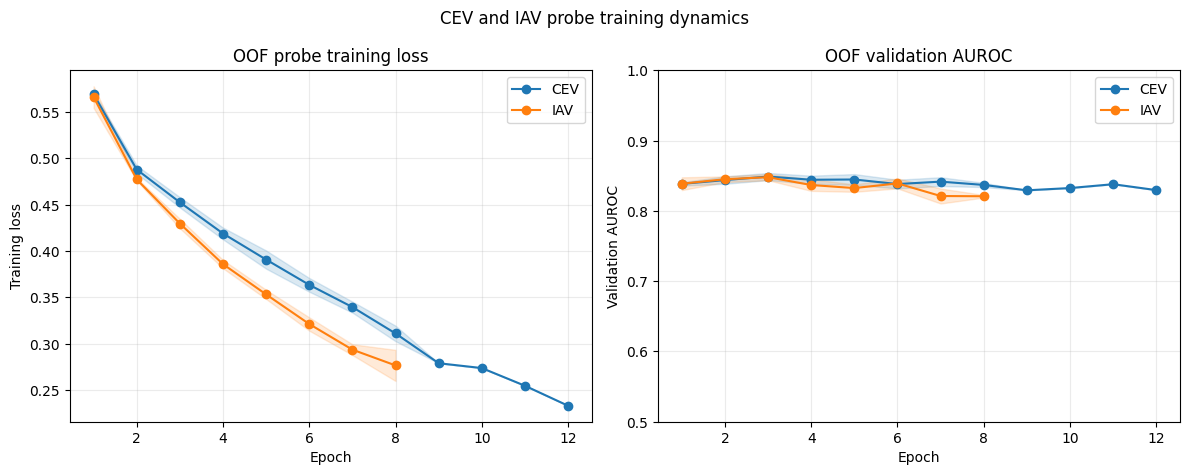

,branch,epoch,train_loss_mean,train_loss_std,validation_auroc_mean,validation_auroc_std,contributing_folds
0,CEV,1,0.569020,0.002274,0.838411,0.002429,3
1,CEV,2,0.487851,0.004309,0.843832,0.005282,3
2,CEV,3,0.452444,0.005583,0.848872,0.005104,3
3,CEV,4,0.418839,0.006337,0.844313,0.005777,3
4,CEV,5,0.390693,0.009799,0.844661,0.007701,3
5,CEV,6,0.363425,0.007375,0.838191,0.006132,3
6,CEV,7,0.339451,0.005931,0.841637,0.006242,3
7,CEV,8,0.311023,0.008369,0.836934,0.003029,3
8,CEV,9,0.278901,0.000000,0.829280,0.000000,1
9,CEV,10,0.273679,0.000000,0.832500,0.000000,1


In [12]:
def fold_histories_to_frame(
    histories: Sequence[Sequence[Dict[str, float]]],
    branch_name: str,
) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    for fold_index, history in enumerate(
        histories,
        start=1,
    ):
        for record in history:
            rows.append({
                "branch": branch_name,
                "fold": int(fold_index),
                "epoch": int(record["epoch"]),
                "train_loss": float(record["train_loss"]),
                "validation_auroc": float(
                    record["validation_auroc"]
                ),
            })
    return pd.DataFrame(rows)


cev_history_df = fold_histories_to_frame(
    cev_fold_histories,
    "CEV",
)
iav_history_df = fold_histories_to_frame(
    iav_fold_histories,
    "IAV",
)
probe_training_history_df = pd.concat(
    [
        cev_history_df,
        iav_history_df,
    ],
    ignore_index=True,
)

probe_training_summary_df = (
    probe_training_history_df
    .groupby(
        [
            "branch",
            "epoch",
        ],
        as_index=False,
    )
    .agg(
        train_loss_mean=(
            "train_loss",
            "mean",
        ),
        train_loss_std=(
            "train_loss",
            "std",
        ),
        validation_auroc_mean=(
            "validation_auroc",
            "mean",
        ),
        validation_auroc_std=(
            "validation_auroc",
            "std",
        ),
        contributing_folds=(
            "fold",
            "nunique",
        ),
    )
    .fillna({
        "train_loss_std": 0.0,
        "validation_auroc_std": 0.0,
    })
)

training_history_path = (
    OUTPUT_DIR
    / "probe_oof_training_history.csv"
)
probe_training_summary_df.to_csv(
    training_history_path,
    index=False,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8),
)

for branch_name in (
    "CEV",
    "IAV",
):
    branch_frame = (
        probe_training_summary_df[
            probe_training_summary_df[
                "branch"
            ]
            == branch_name
        ]
        .sort_values(
            "epoch"
        )
    )

    epochs = branch_frame[
        "epoch"
    ].to_numpy(
        dtype=float
    )
    loss_mean = branch_frame[
        "train_loss_mean"
    ].to_numpy(
        dtype=float
    )
    loss_std = branch_frame[
        "train_loss_std"
    ].to_numpy(
        dtype=float
    )
    auroc_mean = branch_frame[
        "validation_auroc_mean"
    ].to_numpy(
        dtype=float
    )
    auroc_std = branch_frame[
        "validation_auroc_std"
    ].to_numpy(
        dtype=float
    )

    loss_line = axes[0].plot(
        epochs,
        loss_mean,
        marker="o",
        label=branch_name,
    )[0]
    axes[0].fill_between(
        epochs,
        loss_mean - loss_std,
        loss_mean + loss_std,
        alpha=0.16,
        color=loss_line.get_color(),
    )

    auroc_line = axes[1].plot(
        epochs,
        auroc_mean,
        marker="o",
        label=branch_name,
    )[0]
    axes[1].fill_between(
        epochs,
        np.clip(
            auroc_mean - auroc_std,
            0.0,
            1.0,
        ),
        np.clip(
            auroc_mean + auroc_std,
            0.0,
            1.0,
        ),
        alpha=0.16,
        color=auroc_line.get_color(),
    )

axes[0].set_xlabel(
    "Epoch"
)
axes[0].set_ylabel(
    "Training loss"
)
axes[0].set_title(
    "OOF probe training loss"
)
axes[0].grid(
    alpha=0.25
)
axes[0].legend()

axes[1].set_xlabel(
    "Epoch"
)
axes[1].set_ylabel(
    "Validation AUROC"
)
axes[1].set_ylim(
    0.5,
    1.0,
)
axes[1].set_title(
    "OOF validation AUROC"
)
axes[1].grid(
    alpha=0.25
)
axes[1].legend()

fig.suptitle(
    "CEV and IAV probe training dynamics"
)
plt.tight_layout()

training_curve_path = (
    OUTPUT_DIR
    / "probe_oof_training_curves.png"
)
plt.savefig(
    training_curve_path,
    dpi=220,
    bbox_inches="tight",
)
plt.show()
plt.close()

display(
    probe_training_summary_df
)

## 13. One-time evaluation on the untouched official RAGTruth test split

{
  "split": "wandb/RAGTruth-processed:test",
  "n_examples": 2700,
  "cev_auroc": 0.878691566109445,
  "iav_auroc": 0.8804147144190998,
  "fused_auroc": 0.8819193759728545,
  "fused_auroc_ci_95_lower": 0.8687031062033678,
  "fused_auroc_ci_95_upper": 0.8945744378582746,
  "fused_auprc": 0.8122539810249472,
  "accuracy": 0.784074074074074,
  "balanced_accuracy": 0.7920866149098501,
  "precision": 0.652027027027027,
  "recall": 0.8186638388123012,
  "f1": 0.7259050305594734,
  "brier_score": 0.13280450376493957,
  "ece_10_bins": 0.0643044410648737,
  "decision_threshold_from_train_oof": 0.3713131313131313
}

Classification report
              precision    recall  f1-score   support

    grounded     0.8872    0.7655    0.8219      1757
hallucinated     0.6520    0.8187    0.7259       943

    accuracy                         0.7841      2700
   macro avg     0.7696    0.7921    0.7739      2700
weighted avg     0.8051    0.7841    0.7884      2700



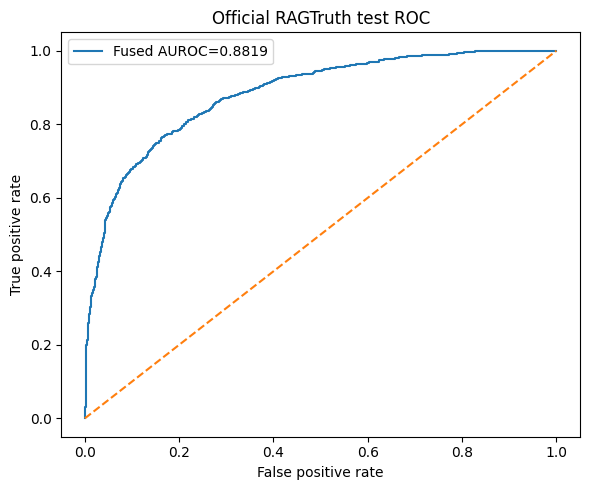

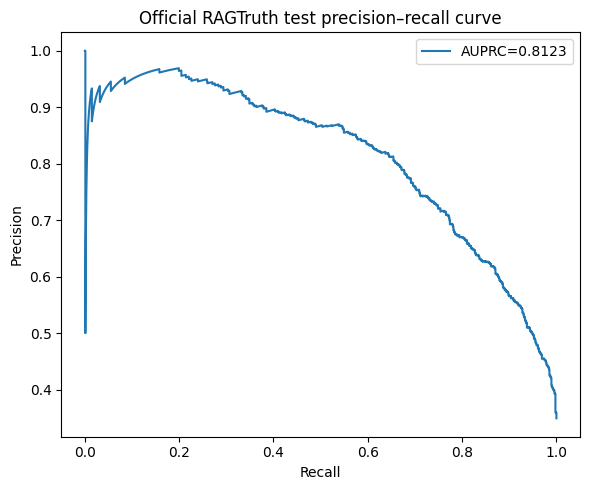

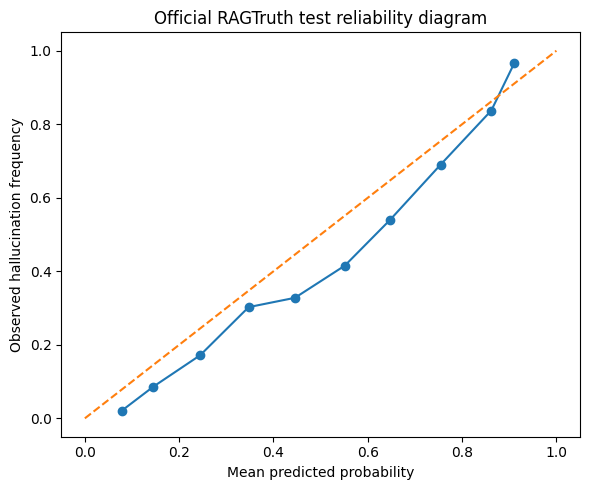

,Predicted grounded,Predicted hallucinated
True grounded,1345,412
True hallucinated,171,772


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_indices = np.arange(len(y_test), dtype=np.int64)
test_cev_loader = make_loader(
    test_cev,
    y_test,
    test_indices,
    shuffle=False,
)
test_iav_loader = make_loader(
    test_iav,
    y_test,
    test_indices,
    shuffle=False,
)

test_cev_logits, test_cev_labels = predict_logits(
    cev_probe,
    test_cev_loader,
    cev_mean,
    cev_std,
    device,
)
test_iav_logits, test_iav_labels = predict_logits(
    iav_probe,
    test_iav_loader,
    iav_mean,
    iav_std,
    device,
)

assert np.array_equal(test_cev_labels, y_test)
assert np.array_equal(test_iav_labels, y_test)

test_cev_probabilities = softmax_numpy(
    test_cev_logits / config.cev_temperature
)[:, 1]
test_iav_probabilities = softmax_numpy(
    test_iav_logits / config.iav_temperature
)[:, 1]

test_fused_uncalibrated = (
    config.fusion_weight_cev * test_cev_probabilities
    + (1.0 - config.fusion_weight_cev) * test_iav_probabilities
)
test_fused_probabilities = apply_platt(
    test_fused_uncalibrated,
    config.platt_a,
    config.platt_b,
)
test_predictions = (
    test_fused_probabilities >= config.hallucination_threshold
).astype(np.int64)


def expected_calibration_error(
    labels: np.ndarray,
    probabilities: np.ndarray,
    n_bins: int = 10,
) -> float:
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lower, upper in zip(edges[:-1], edges[1:]):
        if upper == 1.0:
            mask = (probabilities >= lower) & (probabilities <= upper)
        else:
            mask = (probabilities >= lower) & (probabilities < upper)
        if not mask.any():
            continue
        confidence = probabilities[mask].mean()
        accuracy = labels[mask].mean()
        ece += mask.mean() * abs(confidence - accuracy)
    return float(ece)


def bootstrap_auroc_interval(
    labels: np.ndarray,
    scores: np.ndarray,
    n_bootstrap: int,
    seed: int,
) -> Tuple[float, float]:
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(n_bootstrap):
        indices = rng.integers(0, len(labels), size=len(labels))
        sampled_labels = labels[indices]
        if len(np.unique(sampled_labels)) < 2:
            continue
        values.append(
            roc_auc_score(
                sampled_labels,
                scores[indices],
            )
        )
    return (
        float(np.percentile(values, 2.5)),
        float(np.percentile(values, 97.5)),
    )


auc_ci_lower, auc_ci_upper = bootstrap_auroc_interval(
    y_test,
    test_fused_probabilities,
    n_bootstrap=config.bootstrap_samples,
    seed=config.random_seed,
)

test_metrics = {
    "split": "wandb/RAGTruth-processed:test",
    "n_examples": int(len(y_test)),
    "cev_auroc": float(roc_auc_score(y_test, test_cev_probabilities)),
    "iav_auroc": float(roc_auc_score(y_test, test_iav_probabilities)),
    "fused_auroc": float(roc_auc_score(y_test, test_fused_probabilities)),
    "fused_auroc_ci_95_lower": auc_ci_lower,
    "fused_auroc_ci_95_upper": auc_ci_upper,
    "fused_auprc": float(average_precision_score(y_test, test_fused_probabilities)),
    "accuracy": float(accuracy_score(y_test, test_predictions)),
    "balanced_accuracy": float(
        balanced_accuracy_score(y_test, test_predictions)
    ),
    "precision": float(
        precision_score(y_test, test_predictions, zero_division=0)
    ),
    "recall": float(
        recall_score(y_test, test_predictions, zero_division=0)
    ),
    "f1": float(
        f1_score(y_test, test_predictions, zero_division=0)
    ),
    "brier_score": float(
        brier_score_loss(y_test, test_fused_probabilities)
    ),
    "ece_10_bins": expected_calibration_error(
        y_test,
        test_fused_probabilities,
        n_bins=10,
    ),
    "decision_threshold_from_train_oof": float(
        config.hallucination_threshold
    ),
}

print(json.dumps(test_metrics, indent=2))
print("\nClassification report")
print(classification_report(
    y_test,
    test_predictions,
    target_names=["grounded", "hallucinated"],
    digits=4,
    zero_division=0,
))

test_predictions_df = pd.DataFrame({
    "id": test_ids,
    "label": y_test,
    "cev_probability": test_cev_probabilities,
    "iav_probability": test_iav_probabilities,
    "fused_uncalibrated": test_fused_uncalibrated,
    "fused_probability": test_fused_probabilities,
    "prediction": test_predictions,
})
test_predictions_df.to_csv(
    OUTPUT_DIR / "ragtruth_official_test_predictions.csv",
    index=False,
)
(OUTPUT_DIR / "ragtruth_official_test_metrics.json").write_text(
    json.dumps(test_metrics, indent=2)
)

# ROC and PR curves
fpr, tpr, _ = roc_curve(y_test, test_fused_probabilities)
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    test_fused_probabilities,
)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Fused AUROC={test_metrics['fused_auroc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Official RAGTruth test ROC")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ragtruth_test_roc.png", dpi=220)
plt.show()
plt.close()

plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, label=f"AUPRC={test_metrics['fused_auprc']:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Official RAGTruth test precision–recall curve")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ragtruth_test_pr.png", dpi=220)
plt.show()
plt.close()

# Reliability diagram
fraction_positive, mean_predicted = calibration_curve(
    y_test,
    test_fused_probabilities,
    n_bins=10,
    strategy="uniform",
)
plt.figure(figsize=(6, 5))
plt.plot(mean_predicted, fraction_positive, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed hallucination frequency")
plt.title("Official RAGTruth test reliability diagram")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ragtruth_test_reliability.png", dpi=220)
plt.show()
plt.close()

# Confusion matrix values are retained as a table rather than a separate
# figure because precision, recall, F1, and the class-wise report already
# communicate the same threshold-dependent information.
matrix = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1],
)
confusion_matrix_df = pd.DataFrame(
    matrix,
    index=[
        "True grounded",
        "True hallucinated",
    ],
    columns=[
        "Predicted grounded",
        "Predicted hallucinated",
    ],
)
confusion_matrix_path = (
    OUTPUT_DIR
    / "ragtruth_test_confusion_matrix.csv"
)
confusion_matrix_df.to_csv(
    confusion_matrix_path
)
display(
    confusion_matrix_df
)

## 14. Load Controller answerability and evidence-support models

Controller-v5 keeps the LLaMA CEV/IAV detector frozen and adds two independent
signals:

1. an extractive SQuAD-v2 QA model for answerability and evidence-span cues;
2. a separate NLI model that produces an uncalibrated candidate-support score.

The support output is treated as a model score rather than a calibrated
probability. These auxiliary models are controller inputs and are not used as
human factuality labels.

In [14]:
def normalize_answer_text(
    text: str,
) -> str:
    text = str(text).lower()
    text = "".join(
        character
        for character in text
        if character
        not in string.punctuation
    )
    text = re.sub(
        r"\b(a|an|the)\b",
        " ",
        text,
    )
    return " ".join(
        text.split()
    )


def token_f1_pair(
    prediction: str,
    reference: str,
) -> float:
    prediction_tokens = (
        normalize_answer_text(
            prediction
        ).split()
    )
    reference_tokens = (
        normalize_answer_text(
            reference
        ).split()
    )
    if (
        not prediction_tokens
        and not reference_tokens
    ):
        return 1.0
    if (
        not prediction_tokens
        or not reference_tokens
    ):
        return 0.0

    overlap = sum(
        (
            Counter(
                prediction_tokens
            )
            & Counter(
                reference_tokens
            )
        ).values()
    )
    if overlap == 0:
        return 0.0

    precision_value = (
        overlap
        / len(
            prediction_tokens
        )
    )
    recall_value = (
        overlap
        / len(
            reference_tokens
        )
    )
    return float(
        2.0
        * precision_value
        * recall_value
        / (
            precision_value
            + recall_value
        )
    )


def score_references_basic(
    prediction: str,
    references: Sequence[str],
) -> Dict[str, float]:
    references = [
        str(reference)
        for reference in references
        if str(reference).strip()
    ]
    if not references:
        return {
            "exact_match": 0.0,
            "token_f1": 0.0,
        }
    return {
        "exact_match": float(
            max(
                normalize_answer_text(
                    prediction
                )
                == normalize_answer_text(
                    reference
                )
                for reference
                in references
            )
        ),
        "token_f1": float(
            max(
                token_f1_pair(
                    prediction,
                    reference,
                )
                for reference
                in references
            )
        ),
    }


def resolve_aux_device() -> torch.device:
    if (
        config.controller_aux_device
        == "cuda"
        and torch.cuda.is_available()
    ):
        return torch.device(
            "cuda"
        )
    return torch.device(
        "cpu"
    )


aux_device = resolve_aux_device()

print({
    "qa_model": (
        config.qa_model_name
    ),
    "support_model": (
        config.support_model_name
    ),
    "requested_device": str(
        aux_device
    ),
})

qa_tokenizer = (
    AutoTokenizer
    .from_pretrained(
        config.qa_model_name
    )
)
qa_model = (
    AutoModelForQuestionAnswering
    .from_pretrained(
        config.qa_model_name
    )
)
qa_model.eval()

support_tokenizer = (
    AutoTokenizer
    .from_pretrained(
        config.support_model_name
    )
)
support_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        config.support_model_name
    )
)
support_model.eval()

try:
    qa_model.to(
        aux_device
    )
    support_model.to(
        aux_device
    )
except torch.cuda.OutOfMemoryError:
    print(
        "Controller auxiliary models "
        "did not fit on CUDA; "
        "falling back to CPU."
    )
    qa_model.to("cpu")
    support_model.to("cpu")
    aux_device = torch.device(
        "cpu"
    )
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

support_labels = {
    int(index): str(label).lower()
    for index, label
    in support_model.config.id2label.items()
}
entailment_candidates = [
    index
    for index, label
    in support_labels.items()
    if "entail" in label
]
contradiction_candidates = [
    index
    for index, label
    in support_labels.items()
    if "contrad" in label
]
if (
    entailment_candidates
    and contradiction_candidates
):
    support_entailment_id = int(
        entailment_candidates[0]
    )
    support_contradiction_id = int(
        contradiction_candidates[0]
    )
elif int(
    support_model.config.num_labels
) == 3:
    # Conventional MNLI order used by the selected cross-encoder.
    support_contradiction_id = 0
    support_entailment_id = 1
else:
    raise RuntimeError(
        "Could not identify entailment and contradiction "
        "labels for the controller support model."
    )


def question_answer_claim(
    question: str,
    answer: str,
) -> str:
    return (
        "The answer to the question "
        f"'{str(question).strip()}' "
        f"is {str(answer).strip()}."
    )


@torch.inference_mode()
def qa_assess_contexts(
    question: str,
    contexts: Sequence[str],
) -> Dict[str, Any]:
    contexts = [
        str(context).strip()
        for context in contexts
        if str(context).strip()
    ][
        :config.qa_top_documents
    ]

    if not contexts:
        return {
            "qa_best_answer": "",
            "qa_best_span_logit": (
                -1e9
            ),
            "qa_best_null_logit": (
                1e9
            ),
            "qa_margin": -2e9,
            "qa_best_document_index": (
                -1
            ),
            "qa_answer_length": 0,
            "qa_latency_sec": 0.0,
        }

    start_time = (
        time.perf_counter()
    )
    global_best_answer = ""
    global_best_span = -1e9
    global_best_null = -1e9
    global_best_doc = -1

    for document_index, context in enumerate(
        contexts
    ):
        encoded = qa_tokenizer(
            str(question),
            context,
            truncation="only_second",
            max_length=(
                config.qa_max_length
            ),
            stride=(
                config.qa_doc_stride
            ),
            return_overflowing_tokens=True,
            return_offsets_mapping=True,
            padding=True,
            return_tensors="pt",
        )
        offset_mapping = (
            encoded.pop(
                "offset_mapping"
            )
        )
        sequence_ids = [
            encoded.sequence_ids(
                feature_index
            )
            for feature_index
            in range(
                encoded[
                    "input_ids"
                ].shape[0]
            )
        ]
        encoded.pop(
            "overflow_to_sample_mapping",
            None,
        )
        model_inputs = {
            key: value.to(
                aux_device
            )
            for key, value
            in encoded.items()
        }
        outputs = qa_model(
            **model_inputs
        )
        start_logits = (
            outputs.start_logits
            .detach()
            .cpu()
        )
        end_logits = (
            outputs.end_logits
            .detach()
            .cpu()
        )

        for feature_index in range(
            start_logits.shape[0]
        ):
            ids = encoded[
                "input_ids"
            ][feature_index]
            cls_positions = (
                ids
                == qa_tokenizer.cls_token_id
            ).nonzero(
                as_tuple=False
            )
            cls_index = int(
                cls_positions[0].item()
                if len(
                    cls_positions
                )
                else 0
            )
            null_score = float(
                start_logits[
                    feature_index,
                    cls_index,
                ]
                + end_logits[
                    feature_index,
                    cls_index,
                ]
            )
            global_best_null = max(
                global_best_null,
                null_score,
            )

            top_start = torch.topk(
                start_logits[
                    feature_index
                ],
                k=min(
                    20,
                    start_logits.shape[1],
                ),
            ).indices.tolist()
            top_end = torch.topk(
                end_logits[
                    feature_index
                ],
                k=min(
                    20,
                    end_logits.shape[1],
                ),
            ).indices.tolist()

            offsets = offset_mapping[
                feature_index
            ].tolist()
            feature_sequence_ids = (
                sequence_ids[
                    feature_index
                ]
            )

            for start_index in top_start:
                if (
                    feature_sequence_ids[
                        start_index
                    ]
                    != 1
                ):
                    continue
                for end_index in top_end:
                    if (
                        end_index
                        < start_index
                        or (
                            end_index
                            - start_index
                            + 1
                        )
                        > (
                            config
                            .qa_max_answer_length
                        )
                        or feature_sequence_ids[
                            end_index
                        ]
                        != 1
                    ):
                        continue

                    start_char = int(
                        offsets[
                            start_index
                        ][0]
                    )
                    end_char = int(
                        offsets[
                            end_index
                        ][1]
                    )
                    if (
                        end_char
                        <= start_char
                    ):
                        continue

                    span_score = float(
                        start_logits[
                            feature_index,
                            start_index,
                        ]
                        + end_logits[
                            feature_index,
                            end_index,
                        ]
                    )
                    if (
                        span_score
                        > global_best_span
                    ):
                        global_best_span = (
                            span_score
                        )
                        global_best_answer = (
                            context[
                                start_char:
                                end_char
                            ].strip()
                        )
                        global_best_doc = (
                            document_index
                        )

        del (
            encoded,
            model_inputs,
            outputs,
            start_logits,
            end_logits,
            offset_mapping,
        )

    cuda_sync()
    return {
        "qa_best_answer": (
            global_best_answer
        ),
        "qa_best_span_logit": float(
            global_best_span
        ),
        "qa_best_null_logit": float(
            global_best_null
        ),
        "qa_margin": float(
            global_best_span
            - global_best_null
        ),
        "qa_best_document_index": int(
            global_best_doc
        ),
        "qa_answer_length": int(
            len(
                global_best_answer
                .split()
            )
        ),
        "qa_latency_sec": float(
            time.perf_counter()
            - start_time
        ),
    }


@torch.inference_mode()
def controller_support_score(
    question: str,
    answer: str,
    contexts: Sequence[str],
) -> Dict[str, float]:
    answer = str(
        answer
    ).strip()
    contexts = [
        str(context).strip()
        for context in contexts
        if str(context).strip()
    ][
        :config.support_top_documents
    ]

    if (
        not answer
        or not contexts
    ):
        return {
            "support_score": 0.0,
            "support_contradiction": 0.0,
            "support_margin": 0.0,
            "support_latency_sec": 0.0,
        }

    hypothesis = (
        question_answer_claim(
            question,
            answer,
        )
    )
    start_time = (
        time.perf_counter()
    )
    encoded = support_tokenizer(
        contexts,
        [hypothesis]
        * len(contexts),
        padding=True,
        truncation="only_first",
        max_length=512,
        return_tensors="pt",
    )
    encoded = {
        key: value.to(
            aux_device
        )
        for key, value
        in encoded.items()
    }
    probabilities = torch.softmax(
        support_model(
            **encoded
        ).logits,
        dim=1,
    ).detach().cpu().numpy()

    entailment = probabilities[
        :,
        support_entailment_id,
    ]
    contradiction = probabilities[
        :,
        support_contradiction_id,
    ]
    margins = (
        entailment
        - contradiction
    )
    best_index = int(
        np.argmax(
            margins
        )
    )

    return {
        "support_score": float(
            entailment[
                best_index
            ]
        ),
        "support_contradiction": float(
            contradiction[
                best_index
            ]
        ),
        "support_margin": float(
            margins[
                best_index
            ]
        ),
        "support_latency_sec": float(
            time.perf_counter()
            - start_time
        ),
    }


def question_answer_relevance(
    question: str,
    answer: str,
) -> Dict[str, float]:
    if not str(
        answer
    ).strip():
        return {
            "relevance_raw": -20.0,
            "relevance_score": 0.0,
        }
    raw = float(
        np.asarray(
            reranker.predict(
                [[
                    str(question),
                    str(answer),
                ]],
                show_progress_bar=False,
            )
        ).reshape(-1)[0]
    )
    return {
        "relevance_raw": raw,
        "relevance_score": float(
            expit(raw)
        ),
    }


ANSWERABILITY_FEATURE_NAMES = [
    "qa_best_span_logit",
    "qa_best_null_logit",
    "qa_margin",
    "qa_answer_length",
    "context_rerank_top1",
    "question_context_overlap",
]


def answerability_feature_vector(
    question: str,
    retrieved: Sequence[
        Dict[str, Any]
    ],
    qa_result: Dict[str, Any],
) -> np.ndarray:
    if retrieved:
        top_document = str(
            retrieved[0][
                "text"
            ]
        )
        top_rerank = float(
            retrieved[0].get(
                "rerank_score",
                0.0,
            )
        )
    else:
        top_document = ""
        top_rerank = 0.0

    return np.asarray([
        float(
            qa_result[
                "qa_best_span_logit"
            ]
        ),
        float(
            qa_result[
                "qa_best_null_logit"
            ]
        ),
        float(
            qa_result[
                "qa_margin"
            ]
        ),
        float(
            qa_result[
                "qa_answer_length"
            ]
        ),
        top_rerank,
        lexical_overlap_ratio(
            question,
            top_document,
        ),
    ], dtype=np.float32)


print({
    "auxiliary_device": str(
        aux_device
    ),
    "support_label_mapping": (
        support_labels
    ),
})

{'qa_model': 'deepset/roberta-base-squad2', 'support_model': 'cross-encoder/nli-deberta-v3-small', 'requested_device': 'cuda'}


tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/568M [00:00<?, ?B/s]

{'auxiliary_device': 'cuda', 'support_label_mapping': {0: 'contradiction', 1: 'entailment', 2: 'neutral'}}


## 15. Calibrate answerability on a disjoint SQuAD-v2 training subset

The no-answer estimator is trained only on balanced SQuAD-v2 training examples
whose assigned paragraphs define the benchmark answerability label. Its rows do
not overlap retrieval calibration, controller-quality development, or final
validation evaluation.

In [15]:
def fixed_context_document(
    question: str,
    context: str,
    source: str,
) -> List[Dict[str, Any]]:
    rerank_score = float(
        np.asarray(
            reranker.predict(
                [[
                    str(question),
                    str(context),
                ]],
                show_progress_bar=False,
            )
        ).reshape(-1)[0]
    )
    return [{
        "text": str(context),
        "source": str(source),
        "score": 1.0,
        "bm25_score": 0.0,
        "rrf_score": 1.0,
        "rerank_score": (
            rerank_score
        ),
        "retrieval_query": (
            str(question)
        ),
        "hybrid_retrieval": False,
        "index": -1,
    }]



if (
    len(
        selected_answerable_train
    )
    != config.answerability_examples_per_class
    or len(
        selected_unanswerable_train
    )
    != config.answerability_examples_per_class
):
    raise RuntimeError(
        "The SQuAD-v2 answerability partition "
        "does not match the configured class counts."
    )

assert set(
    answerability_indices
).isdisjoint(
    set(
        selected_retrieval_calibration_indices
    )
)
assert set(
    answerability_indices
).isdisjoint(
    set(
        controller_dev_indices
    )
)

answerability_spec = {
    "source": (
        "rajpurkar/squad_v2:train"
    ),
    "dataset_fingerprint": getattr(
        squad_v2_train,
        "_fingerprint",
        None,
    ),
    "answerable_rows": int(
        len(
            selected_answerable_train
        )
    ),
    "unanswerable_rows": int(
        len(
            selected_unanswerable_train
        )
    ),
    "qa_model": (
        config.qa_model_name
    ),
    "seed": (
        config.random_seed + 303
    ),
}
answerability_fingerprint = (
    hashlib.sha256(
        json.dumps(
            answerability_spec,
            sort_keys=True,
        ).encode("utf-8")
    ).hexdigest()[:16]
)
answerability_trace_path = (
    TRACE_DIR
    / (
        "answerability_train_"
        f"{answerability_fingerprint}.jsonl"
    )
)

answerability_records_by_id: Dict[
    str,
    Dict[str, Any],
] = {}
if answerability_trace_path.exists():
    with answerability_trace_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        for line in handle:
            if not line.strip():
                continue
            record = json.loads(
                line
            )
            answerability_records_by_id[
                str(record["squad_id"])
            ] = record

with answerability_trace_path.open(
    "a",
    encoding="utf-8",
) as handle:
    for dataset_index in tqdm(
        answerability_indices,
        desc=(
            "SQuAD-v2 answerability "
            "features"
        ),
    ):
        row = squad_v2_train[
            int(dataset_index)
        ]
        squad_id = str(
            row["id"]
        )
        if (
            squad_id
            in answerability_records_by_id
        ):
            continue

        question = str(
            row["question"]
        )
        context = str(
            row["context"]
        )
        gold_answers = [
            str(answer)
            for answer
            in row["answers"]["text"]
        ]
        no_answer_label = int(
            len(gold_answers) == 0
        )

        retrieved = (
            fixed_context_document(
                question,
                context,
                "squad_v2_train_assigned",
            )
        )
        qa_result = (
            qa_assess_contexts(
                question,
                [context],
            )
        )
        features = (
            answerability_feature_vector(
                question,
                retrieved,
                qa_result,
            )
        )

        record: Dict[str, Any] = {
            "dataset_index": int(
                dataset_index
            ),
            "squad_id": squad_id,
            "question": question,
            "no_answer_label": (
                no_answer_label
            ),
            "qa_best_answer": (
                qa_result[
                    "qa_best_answer"
                ]
            ),
        }
        record.update({
            name: float(value)
            for name, value in zip(
                ANSWERABILITY_FEATURE_NAMES,
                features,
            )
        })
        handle.write(
            json.dumps(
                json_safe(record),
                allow_nan=False,
            )
            + "\n"
        )
        handle.flush()
        answerability_records_by_id[
            squad_id
        ] = record

answerability_records = [
    answerability_records_by_id[
        str(
            squad_v2_train[
                int(index)
            ]["id"]
        )
    ]
    for index in answerability_indices
]
answerability_df = pd.DataFrame(
    answerability_records
)
answerability_X = (
    answerability_df[
        ANSWERABILITY_FEATURE_NAMES
    ].to_numpy(
        dtype=np.float32
    )
)
answerability_y = (
    answerability_df[
        "no_answer_label"
    ].astype(int).to_numpy()
)

answerability_oof_probability = (
    np.zeros(
        len(
            answerability_y
        ),
        dtype=np.float64,
    )
)
answerability_skf = StratifiedKFold(
    n_splits=(
        config.answerability_oof_folds
    ),
    shuffle=True,
    random_state=(
        config.random_seed + 404
    ),
)

for fold_index, (
    fold_train,
    fold_validation,
) in enumerate(
    answerability_skf.split(
        answerability_X,
        answerability_y,
    ),
    start=1,
):
    fold_model = Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "logistic",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=(
                    config.random_seed
                    + 400
                    + fold_index
                ),
            ),
        ),
    ])
    fold_model.fit(
        answerability_X[
            fold_train
        ],
        answerability_y[
            fold_train
        ],
    )
    answerability_oof_probability[
        fold_validation
    ] = fold_model.predict_proba(
        answerability_X[
            fold_validation
        ]
    )[:, 1]

answerability_threshold_rows: List[
    Dict[str, float]
] = []
for threshold in np.linspace(
    0.01,
    0.99,
    197,
):
    predicted_no_answer = (
        answerability_oof_probability
        >= threshold
    )
    answerable_mask = (
        answerability_y == 0
    )
    unanswerable_mask = (
        answerability_y == 1
    )
    answerable_coverage = float(
        (
            ~predicted_no_answer[
                answerable_mask
            ]
        ).mean()
    )
    unanswerable_abstention = float(
        predicted_no_answer[
            unanswerable_mask
        ].mean()
    )
    balanced = float(
        balanced_accuracy_score(
            answerability_y,
            predicted_no_answer
            .astype(int),
        )
    )
    answerability_threshold_rows.append({
        "threshold": float(
            threshold
        ),
        "answerable_coverage": (
            answerable_coverage
        ),
        "unanswerable_abstention_accuracy": (
            unanswerable_abstention
        ),
        "balanced_accuracy": (
            balanced
        ),
    })

answerability_threshold_df = (
    pd.DataFrame(
        answerability_threshold_rows
    )
)
eligible_answerability = (
    answerability_threshold_df[
        answerability_threshold_df[
            "answerable_coverage"
        ]
        >= (
            config
            .answerable_coverage_target
        )
    ]
)
if len(
    eligible_answerability
) == 0:
    raise RuntimeError(
        "No answerability threshold "
        "meets the answerable-coverage "
        "constraint."
    )

selected_answerability = (
    eligible_answerability
    .sort_values(
        [
            "unanswerable_abstention_accuracy",
            "balanced_accuracy",
            "answerable_coverage",
        ],
        ascending=False,
    )
    .iloc[0]
)
config.no_answer_threshold = float(
    selected_answerability[
        "threshold"
    ]
)

answerability_model = Pipeline([
    (
        "scaler",
        StandardScaler(),
    ),
    (
        "logistic",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=(
                config.random_seed
            ),
        ),
    ),
])
answerability_model.fit(
    answerability_X,
    answerability_y,
)


def no_answer_probability(
    question: str,
    retrieved: Sequence[
        Dict[str, Any]
    ],
    qa_result: Dict[str, Any],
) -> float:
    features = (
        answerability_feature_vector(
            question,
            retrieved,
            qa_result,
        ).reshape(1, -1)
    )
    return float(
        answerability_model
        .predict_proba(
            features
        )[0, 1]
    )


answerability_df[
    "oof_no_answer_probability"
] = (
    answerability_oof_probability
)
answerability_metadata = {
    "source": (
        "rajpurkar/squad_v2:train"
    ),
    "n_examples": int(
        len(
            answerability_df
        )
    ),
    "balanced_classes": True,
    "validation_split_used": False,
    "qa_model": (
        config.qa_model_name
    ),
    "oof_auroc": float(
        roc_auc_score(
            answerability_y,
            answerability_oof_probability,
        )
    ),
    "no_answer_threshold": float(
        config.no_answer_threshold
    ),
    "selected_operating_point": (
        selected_answerability
        .to_dict()
    ),
    "selection_rule": (
        "maximize unanswerable abstention "
        "subject to answerable coverage "
        f">= {config.answerable_coverage_target:.2f}"
    ),
}

answerability_df.to_csv(
    CONTROLLER_OUTPUT_DIR
    / (
        "answerability_"
        "calibration_rows.csv"
    ),
    index=False,
)
answerability_threshold_df.to_csv(
    CONTROLLER_OUTPUT_DIR
    / (
        "answerability_"
        "threshold_curve.csv"
    ),
    index=False,
)
write_json(
    CONTROLLER_OUTPUT_DIR
    / "answerability_metadata.json",
    answerability_metadata,
)
with (
    CONTROLLER_OUTPUT_DIR
    / "answerability_model.pkl"
).open("wb") as handle:
    pickle.dump({
        "model": (
            answerability_model
        ),
        "feature_names": (
            ANSWERABILITY_FEATURE_NAMES
        ),
        "threshold": (
            config.no_answer_threshold
        ),
    }, handle)

print(json.dumps(
    json_safe(
        answerability_metadata
    ),
    indent=2,
))

SQuAD-v2 answerability features:   0%|          | 0/1500 [00:00<?, ?it/s]

{
  "source": "rajpurkar/squad_v2:train",
  "n_examples": 1500,
  "balanced_classes": true,
  "validation_split_used": false,
  "qa_model": "deepset/roberta-base-squad2",
  "oof_auroc": 0.984288,
  "no_answer_threshold": 0.525,
  "selected_operating_point": {
    "threshold": 0.525,
    "answerable_coverage": 0.9506666666666667,
    "unanswerable_abstention_accuracy": 0.9346666666666666,
    "balanced_accuracy": 0.9426666666666667
  },
  "selection_rule": "maximize unanswerable abstention subject to answerable coverage >= 0.95"
}


## 16. Candidate generation and multi-signal feature extraction

Each candidate is assessed using:

- frozen CEV/IAV hallucination risk;
- retrieval-failure probability;
- calibrated no-answer probability;
- an NLI-derived support score;
- a cross-encoder question--answer relevance score;
- agreement with the best extractive evidence span;
- output validity and refusal type.

The support and relevance values are raw model scores used as relative features;
they are not interpreted as calibrated probabilities.

In [16]:
REFUSAL_PATTERNS = (
    r"\[abstain\]",
    r"\bi cannot answer\b",
    r"\bi can't answer\b",
    r"\bi do not know\b",
    r"\bi don't know\b",
    r"\bnot enough information\b",
    r"\bno information\b",
    r"\bnot available in the supplied documents\b",
    r"\bcontext does not (?:contain|provide|state)\b",
    r"\bnot stated in the context\b",
    r"\bcannot determine\b",
    r"\bunable to answer\b",
)


def is_refusal(
    text: str,
) -> bool:
    value = str(
        text
    ).lower().strip()
    return any(
        re.search(
            pattern,
            value,
        )
        for pattern
        in REFUSAL_PATTERNS
    )


def classify_response_type(
    response: str,
) -> str:
    normalized = " ".join(
        str(response).split()
    )
    if not normalized:
        return "empty_output"
    if (
        normalized.strip().lower()
        == "[abstain]"
    ):
        return (
            "explicit_abstention"
        )
    if is_refusal(
        normalized
    ):
        return "generic_refusal"
    if (
        normalized.lower()
        .startswith("question:")
        or normalized.lower()
        .startswith(
            "short answer:"
        )
        or "supplied documents"
        in normalized.lower()
    ):
        return "malformed_output"
    return "answer"


def validate_candidate_response(
    response: str,
) -> Dict[str, Any]:
    normalized = " ".join(
        str(response).split()
    )
    response_type = (
        classify_response_type(
            normalized
        )
    )
    word_count = len(
        normalized.split()
    )
    invalid = bool(
        response_type
        in {
            "empty_output",
            "malformed_output",
        }
        or word_count
        > config.response_max_words
    )
    return {
        "normalized_response": (
            normalized
        ),
        "response_type": (
            response_type
        ),
        "is_empty": (
            response_type
            == "empty_output"
        ),
        "is_refusal": (
            response_type
            in {
                "explicit_abstention",
                "generic_refusal",
            }
        ),
        "is_invalid": invalid,
        "word_count": int(
            word_count
        ),
    }


def strip_model_thinking(
    text: str,
) -> str:
    text = str(text)
    if (
        "<think>" in text
        and "</think>" in text
    ):
        text = text.split(
            "</think>",
            1,
        )[1]
    elif "<think>" in text:
        text = text.split(
            "<think>",
            1,
        )[0]
    return text.strip()


class ProbeScorer:
    def __init__(
        self,
        extractor: HiddenStateExtractor,
        cev_probe: HallucinationProbe,
        iav_probe: HallucinationProbe,
        cev_mean: np.ndarray,
        cev_std: np.ndarray,
        iav_mean: np.ndarray,
        iav_std: np.ndarray,
        cfg: Config,
    ):
        self.extractor = extractor
        self.cev_probe = (
            cev_probe.eval()
        )
        self.iav_probe = (
            iav_probe.eval()
        )
        self.cfg = cfg
        self.device = next(
            cev_probe.parameters()
        ).device

        self.cev_mean = (
            torch.from_numpy(
                cev_mean
            )
            .float()
            .to(self.device)
        )
        self.cev_std = (
            torch.from_numpy(
                cev_std
            )
            .float()
            .to(self.device)
        )
        self.iav_mean = (
            torch.from_numpy(
                iav_mean
            )
            .float()
            .to(self.device)
        )
        self.iav_std = (
            torch.from_numpy(
                iav_std
            )
            .float()
            .to(self.device)
        )

    @torch.inference_mode()
    def score_text(
        self,
        text: str,
    ) -> Dict[str, float]:
        cuda_sync()
        start = (
            time.perf_counter()
        )

        raw_cev, raw_iav = (
            self.extractor
            .extract_batch(
                [text]
            )
        )
        cev = (
            torch.from_numpy(
                raw_cev
            )
            .float()
            .to(self.device)
        )
        iav = (
            torch.from_numpy(
                raw_iav
            )
            .float()
            .to(self.device)
        )

        cev = (
            cev - self.cev_mean
        ) / self.cev_std.clamp_min(
            1e-6
        )
        iav = (
            iav - self.iav_mean
        ) / self.iav_std.clamp_min(
            1e-6
        )

        cev_probability = float(
            torch.softmax(
                self.cev_probe(
                    cev
                )
                / self.cfg.cev_temperature,
                dim=1,
            )[0, 1].item()
        )
        iav_probability = float(
            torch.softmax(
                self.iav_probe(
                    iav
                )
                / self.cfg.iav_temperature,
                dim=1,
            )[0, 1].item()
        )
        fused_uncalibrated = (
            self.cfg.fusion_weight_cev
            * cev_probability
            + (
                1.0
                - self.cfg.fusion_weight_cev
            )
            * iav_probability
        )
        fused_probability = float(
            apply_platt(
                np.asarray([
                    fused_uncalibrated
                ]),
                self.cfg.platt_a,
                self.cfg.platt_b,
            )[0]
        )

        cuda_sync()
        return {
            "cev_probability": (
                cev_probability
            ),
            "iav_probability": (
                iav_probability
            ),
            "fused_uncalibrated": (
                float(
                    fused_uncalibrated
                )
            ),
            "fused_probability": (
                fused_probability
            ),
            "scoring_latency_sec": float(
                time.perf_counter()
                - start
            ),
        }


probe_scorer = ProbeScorer(
    extractor=extractor,
    cev_probe=cev_probe,
    iav_probe=iav_probe,
    cev_mean=cev_mean,
    cev_std=cev_std,
    iav_mean=iav_mean,
    iav_std=iav_std,
    cfg=config,
)


def build_generation_prompt(
    question: str,
    context: str,
    mode: str = "initial",
    previous_answer: str = "",
    failure_reason: str = "",
    extractive_answer: str = "",
    evidence_excerpt: str = "",
) -> str:
    if mode == "initial":
        corrective = ""
    else:
        corrective = (
            "The previous candidate failed a verification check.\n"
            f"Previous candidate: {previous_answer}\n"
            f"Detected issue: {failure_reason}\n"
        )
        if str(
            extractive_answer
        ).strip():
            corrective += (
                "High-confidence evidence span: "
                f"{extractive_answer}\n"
            )
        if str(
            evidence_excerpt
        ).strip():
            corrective += (
                "Most relevant evidence excerpt:\n"
                f"{evidence_excerpt}\n"
            )
        corrective += (
            "Correct the detected issue. "
            "Do not repeat the previous candidate "
            "unless it is already exactly supported.\n\n"
        )

    return (
        "Answer the question using only the supplied documents.\n"
        "Return only the shortest answer span that directly answers "
        "the exact question.\n"
        "Do not add an explanation, citation, introductory phrase, "
        "or unrelated fact.\n"
        "If the documents do not contain a supported answer, output "
        "exactly: [ABSTAIN]\n\n"
        f"{corrective}"
        f"{context}\n\n"
        f"Question: {question}\n"
        "Short answer:"
    )


def build_query_rewrite_prompt(
    question: str,
    previous_answer: str,
    failure_reason: str,
) -> str:
    return (
        "Rewrite the question as one concise document-search query.\n"
        "Preserve exact names, dates, places, numbers, and the requested "
        "relationship.\n"
        f"Original question: {question}\n"
        f"Failed answer: {previous_answer}\n"
        f"Failure type: {failure_reason}\n"
        "Return only the search query:"
    )


def tokenize_generation_prompt(
    prompt: str,
) -> Dict[str, torch.Tensor]:
    if hasattr(
        tokenizer,
        "apply_chat_template",
    ):
        try:
            chat_text = (
                tokenizer
                .apply_chat_template(
                    [{
                        "role": "user",
                        "content": prompt,
                    }],
                    tokenize=False,
                    add_generation_prompt=True,
                    enable_thinking=False,
                )
            )
        except TypeError:
            chat_text = (
                tokenizer
                .apply_chat_template(
                    [{
                        "role": "user",
                        "content": prompt,
                    }],
                    tokenize=False,
                    add_generation_prompt=True,
                )
            )
    else:
        chat_text = prompt

    tokenizer.padding_side = "left"
    tokenizer.truncation_side = "left"
    encoded = tokenizer(
        chat_text,
        return_tensors="pt",
        truncation=True,
        max_length=(
            config.max_context_length
        ),
    )
    llm_device = (
        get_model_input_device(
            model
        )
    )
    return {
        key: value.to(
            llm_device
        )
        for key, value
        in encoded.items()
    }


def generate_text_from_prompt(
    prompt: str,
    seed: int,
    max_new_tokens: int,
    do_sample: bool,
) -> Dict[str, Any]:
    encoded = (
        tokenize_generation_prompt(
            prompt
        )
    )
    prompt_length = int(
        encoded[
            "input_ids"
        ].shape[1]
    )

    torch.manual_seed(
        int(seed)
    )
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            int(seed)
        )

    generation_kwargs: Dict[
        str,
        Any,
    ] = {
        "max_new_tokens": int(
            max_new_tokens
        ),
        "do_sample": bool(
            do_sample
        ),
        "pad_token_id": (
            tokenizer.pad_token_id
        ),
        "eos_token_id": (
            tokenizer.eos_token_id
        ),
        "use_cache": True,
    }

    cuda_sync()
    start = (
        time.perf_counter()
    )
    with torch.inference_mode():
        output_ids = model.generate(
            **encoded,
            **generation_kwargs,
        )
    cuda_sync()

    response = tokenizer.decode(
        output_ids[
            0,
            prompt_length:,
        ],
        skip_special_tokens=True,
    )
    response = (
        strip_model_thinking(
            response
        )
    )
    latency = float(
        time.perf_counter()
        - start
    )

    del (
        encoded,
        output_ids,
    )
    return {
        "text": response,
        "latency_sec": latency,
    }


def rewrite_retrieval_query(
    question: str,
    previous_answer: str,
    failure_reason: str,
    seed: int,
) -> Dict[str, Any]:
    result = (
        generate_text_from_prompt(
            prompt=(
                build_query_rewrite_prompt(
                    question,
                    previous_answer,
                    failure_reason,
                )
            ),
            seed=seed,
            max_new_tokens=(
                config
                .query_rewrite_max_new_tokens
            ),
            do_sample=False,
        )
    )
    rewritten = " ".join(
        result["text"].split()
    )
    if (
        not rewritten
        or len(
            rewritten.split()
        ) > 40
        or is_refusal(
            rewritten
        )
    ):
        rewritten = str(
            question
        ).strip()

    return {
        "query": rewritten,
        "latency_sec": (
            result["latency_sec"]
        ),
    }


def evidence_excerpt(
    question: str,
    retrieved: Sequence[
        Dict[str, Any]
    ],
) -> str:
    excerpts = []
    for item in list(
        retrieved
    )[:2]:
        excerpts.append(
            RAGPipeline
            ._query_aware_excerpt(
                item["text"],
                query=question,
                max_characters=650,
            )
        )
    return "\n".join(
        excerpts
    )


def build_evidence_state(
    question: str,
    retrieved: Sequence[
        Dict[str, Any]
    ],
) -> Dict[str, Any]:
    evidence_start = time.perf_counter()
    retrieved = list(
        retrieved
    )
    contexts = [
        str(item["text"])
        for item in retrieved
    ]
    retrieval_failure = (
        retrieval_failure_probability(
            question,
            retrieved,
        )
    )
    qa_result = (
        qa_assess_contexts(
            question,
            contexts,
        )
    )
    p_no_answer = (
        no_answer_probability(
            question,
            retrieved,
            qa_result,
        )
    )
    return {
        "retrieval_failure_probability": float(
            retrieval_failure
        ),
        "retrieval_quality": float(
            1.0
            - retrieval_failure
        ),
        "no_answer_probability": float(
            p_no_answer
        ),
        "qa_result": qa_result,
        "contexts": contexts,
        "evidence_excerpt": (
            evidence_excerpt(
                question,
                retrieved,
            )
        ),
        "evidence_latency_sec": float(
            time.perf_counter()
            - evidence_start
        ),
    }


CANDIDATE_FEATURE_NAMES = [
    "fused_probability",
    "retrieval_failure_probability",
    "no_answer_probability",
    "support_score",
    "support_margin",
    "relevance_score",
    "span_alignment_f1",
    "qa_margin",
    "is_refusal",
    "is_invalid",
    "word_count_scaled",
]


def generate_candidate(
    question: str,
    retrieved: Sequence[
        Dict[str, Any]
    ],
    seed: int,
    mode: str = "initial",
    previous_answer: str = "",
    failure_reason: str = "",
    evidence_state: Optional[
        Dict[str, Any]
    ] = None,
) -> Dict[str, Any]:
    evidence_state = (
        evidence_state
        if evidence_state
        is not None
        else build_evidence_state(
            question,
            retrieved,
        )
    )
    context = (
        rag_pipeline
        .format_context(
            retrieved,
            query=question,
        )
    )
    prompt = (
        build_generation_prompt(
            question=question,
            context=context,
            mode=mode,
            previous_answer=(
                previous_answer
            ),
            failure_reason=(
                failure_reason
            ),
            extractive_answer=(
                evidence_state[
                    "qa_result"
                ][
                    "qa_best_answer"
                ]
            ),
            evidence_excerpt=(
                evidence_state[
                    "evidence_excerpt"
                ]
            ),
        )
    )
    generation_result = (
        generate_text_from_prompt(
            prompt=prompt,
            seed=seed,
            max_new_tokens=(
                config
                .generation_max_new_tokens
                if mode == "initial"
                else config
                .regeneration_max_new_tokens
            ),
            do_sample=(
                config
                .generation_do_sample
                if mode == "initial"
                else config
                .regeneration_do_sample
            ),
        )
    )
    validation = (
        validate_candidate_response(
            generation_result[
                "text"
            ]
        )
    )
    response = validation[
        "normalized_response"
    ]

    if validation[
        "is_empty"
    ]:
        score_result = {
            "cev_probability": 1.0,
            "iav_probability": 1.0,
            "fused_uncalibrated": 1.0,
            "fused_probability": 1.0,
            "scoring_latency_sec": 0.0,
        }
    else:
        probe_text = (
            build_live_probe_text(
                question,
                context,
                response,
            )
        )
        score_result = (
            probe_scorer
            .score_text(
                probe_text
            )
        )

    return {
        "response": response,
        "formatted_context": (
            context
        ),
        "generation_mode": mode,
        "generation_latency_sec": (
            generation_result[
                "latency_sec"
            ]
        ),
        **validation,
        **score_result,
    }


def candidate_raw_assessment(
    question: str,
    candidate: Dict[str, Any],
    evidence_state: Dict[str, Any],
) -> Dict[str, Any]:
    response = candidate[
        "response"
    ]
    support_result = (
        controller_support_score(
            question,
            response,
            evidence_state[
                "contexts"
            ],
        )
        if not candidate[
            "is_refusal"
        ]
        else {
            "support_score": 0.0,
            "support_contradiction": 0.0,
            "support_margin": 0.0,
            "support_latency_sec": 0.0,
        }
    )
    relevance_result = (
        question_answer_relevance(
            question,
            response,
        )
        if not candidate[
            "is_refusal"
        ]
        else {
            "relevance_raw": -20.0,
            "relevance_score": 0.0,
        }
    )
    qa_answer = (
        evidence_state[
            "qa_result"
        ][
            "qa_best_answer"
        ]
    )
    span_alignment = (
        token_f1_pair(
            response,
            qa_answer,
        )
        if (
            response
            and qa_answer
            and not candidate[
                "is_refusal"
            ]
        )
        else 0.0
    )

    feature_values = np.asarray([
        float(
            candidate[
                "fused_probability"
            ]
        ),
        float(
            evidence_state[
                "retrieval_failure_probability"
            ]
        ),
        float(
            evidence_state[
                "no_answer_probability"
            ]
        ),
        float(
            support_result[
                "support_score"
            ]
        ),
        float(
            support_result[
                "support_margin"
            ]
        ),
        float(
            relevance_result[
                "relevance_score"
            ]
        ),
        float(
            span_alignment
        ),
        float(
            evidence_state[
                "qa_result"
            ][
                "qa_margin"
            ]
        ),
        float(
            candidate[
                "is_refusal"
            ]
        ),
        float(
            candidate[
                "is_invalid"
            ]
        ),
        float(
            candidate[
                "word_count"
            ]
            / max(
                1,
                config.response_max_words,
            )
        ),
    ], dtype=np.float32)

    return {
        **candidate,
        **support_result,
        **relevance_result,
        "span_alignment_f1": float(
            span_alignment
        ),
        "qa_best_answer": (
            qa_answer
        ),
        "qa_margin": float(
            evidence_state[
                "qa_result"
            ][
                "qa_margin"
            ]
        ),
        "retrieval_failure_probability": float(
            evidence_state[
                "retrieval_failure_probability"
            ]
        ),
        "retrieval_quality": float(
            evidence_state[
                "retrieval_quality"
            ]
        ),
        "no_answer_probability": float(
            evidence_state[
                "no_answer_probability"
            ]
        ),
        "candidate_feature_vector": (
            feature_values
        ),
        "auxiliary_latency_sec": float(
            support_result[
                "support_latency_sec"
            ]
        ),
    }


def reference_semantic_similarity(
    prediction: str,
    references: Sequence[str],
) -> float:
    references = [
        str(reference)
        for reference
        in references
        if str(reference).strip()
    ]
    if (
        not str(
            prediction
        ).strip()
        or not references
    ):
        return 0.0

    embeddings = (
        rag_pipeline
        .encode_documents(
            [
                str(prediction)
            ]
            + references,
            batch_size=16,
            show_progress_bar=False,
        )
    )
    return float(
        np.max(
            embeddings[1:]
            @ embeddings[0]
        )
    )


print({
    "candidate_feature_names": (
        CANDIDATE_FEATURE_NAMES
    ),
    "controller_aux_device": str(
        aux_device
    ),
})


def state_dict_sha256(
    *models_to_hash: nn.Module,
) -> str:
    digest = hashlib.sha256()
    for model_index, model_to_hash in enumerate(
        models_to_hash
    ):
        digest.update(
            f"model_{model_index}".encode(
                "utf-8"
            )
        )
        for key, tensor in sorted(
            model_to_hash
            .state_dict()
            .items()
        ):
            digest.update(
                key.encode("utf-8")
            )
            digest.update(
                tensor.detach()
                .cpu()
                .contiguous()
                .numpy()
                .tobytes()
            )
    return digest.hexdigest()


{'candidate_feature_names': ['fused_probability', 'retrieval_failure_probability', 'no_answer_probability', 'support_score', 'support_margin', 'relevance_score', 'span_alignment_f1', 'qa_margin', 'is_refusal', 'is_invalid', 'word_count_scaled'], 'controller_aux_device': 'cuda'}


## 17. Calibrate candidate quality and the SQuAD-v2 safety operating point

Candidate-quality supervision now uses a disjoint, balanced mixture of
answerable and unanswerable SQuAD-v2 training examples. Support and relevance
scores remain inputs to the calibrated quality model and diagnostic routing;
they are no longer used as near-zero independent hard gates. The selected
operating point must satisfy predefined answerable-coverage and unanswerable
false-answer constraints.

In [17]:
candidate_dev_spec = {
    "source": (
        "rajpurkar/squad_v2:train_mixed"
    ),
    "dataset_fingerprint": getattr(
        squad_v2_train,
        "_fingerprint",
        None,
    ),
    "answerable_rows": int(
        len(
            controller_dev_answerable_indices
        )
    ),
    "unanswerable_rows": int(
        len(
            controller_dev_unanswerable_indices
        )
    ),
    "indices_sha256": hashlib.sha256(
        json.dumps(
            controller_dev_indices
        ).encode("utf-8")
    ).hexdigest(),
    "probe_weights_sha256": (
        state_dict_sha256(
            cev_probe,
            iav_probe,
        )
    ),
    "qa_model": (
        config.qa_model_name
    ),
    "support_model": (
        config.support_model_name
    ),
    "controller_code_version": (
        config.controller_code_version
    ),
    "prompt_version": (
        "diagnostic_short_answer_v5_squadv2"
    ),
    "generation_max_new_tokens": (
        config.generation_max_new_tokens
    ),
    "generation_do_sample": (
        config.generation_do_sample
    ),
    "context_mode": (
        "assigned_paragraph_fixed"
    ),
}
candidate_dev_fingerprint = (
    hashlib.sha256(
        json.dumps(
            candidate_dev_spec,
            sort_keys=True,
        ).encode("utf-8")
    ).hexdigest()[:16]
)
candidate_dev_trace_path = (
    TRACE_DIR
    / (
        "candidate_quality_squadv2_"
        f"{candidate_dev_fingerprint}.jsonl"
    )
)

candidate_dev_by_id: Dict[
    str,
    Dict[str, Any],
] = {}
if candidate_dev_trace_path.exists():
    with candidate_dev_trace_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        for line in handle:
            if not line.strip():
                continue
            record = json.loads(
                line
            )
            candidate_dev_by_id[
                str(record["squad_id"])
            ] = record

with candidate_dev_trace_path.open(
    "a",
    encoding="utf-8",
) as handle:
    for dataset_index in tqdm(
        controller_dev_indices,
        desc=(
            "SQuAD-v2 candidate-quality "
            "development"
        ),
    ):
        row = squad_v2_train[
            int(dataset_index)
        ]
        squad_id = str(
            row["id"]
        )
        if squad_id in (
            candidate_dev_by_id
        ):
            continue

        question = str(
            row["question"]
        )
        context = str(
            row["context"]
        )
        references = [
            str(answer)
            for answer
            in row["answers"]["text"]
        ]
        is_answerable = bool(
            len(references) > 0
        )

        retrieved = (
            fixed_context_document(
                question=question,
                context=context,
                source=(
                    "squad_v2_train_assigned"
                ),
            )
        )
        evidence_state = (
            build_evidence_state(
                question,
                retrieved,
            )
        )
        evidence_state[
            "retrieval_failure_probability"
        ] = 0.0
        evidence_state[
            "retrieval_quality"
        ] = 1.0

        query_seed = (
            config.random_seed
            + int(
                hashlib.sha256(
                    squad_id.encode(
                        "utf-8"
                    )
                ).hexdigest()[:8],
                16,
            )
        ) % (2**31 - 1)

        candidate = (
            generate_candidate(
                question=question,
                retrieved=retrieved,
                seed=query_seed,
                mode="initial",
                evidence_state=(
                    evidence_state
                ),
            )
        )
        assessment = (
            candidate_raw_assessment(
                question,
                candidate,
                evidence_state,
            )
        )

        if is_answerable:
            quality = (
                score_references_basic(
                    assessment[
                        "response"
                    ],
                    references,
                )
            )
            semantic_similarity = (
                reference_semantic_similarity(
                    assessment[
                        "response"
                    ],
                    references,
                )
            )
            automatic_good = bool(
                not assessment[
                    "is_refusal"
                ]
                and not assessment[
                    "is_invalid"
                ]
                and (
                    quality[
                        "token_f1"
                    ]
                    >= (
                        config
                        .controller_bad_answer_f1_threshold
                    )
                    or (
                        semantic_similarity
                        >= 0.85
                        and assessment[
                            "support_score"
                        ]
                        >= 0.50
                        and assessment[
                            "relevance_score"
                        ]
                        >= 0.50
                    )
                )
            )
        else:
            quality = {
                "exact_match": np.nan,
                "token_f1": np.nan,
            }
            semantic_similarity = np.nan
            automatic_good = bool(
                assessment[
                    "is_refusal"
                ]
                and not assessment[
                    "is_invalid"
                ]
            )

        record: Dict[str, Any] = {
            "dataset_index": int(
                dataset_index
            ),
            "squad_id": squad_id,
            "question": question,
            "is_answerable": (
                is_answerable
            ),
            "gold_answers": references,
            "response": (
                assessment[
                    "response"
                ]
            ),
            "exact_match": (
                quality[
                    "exact_match"
                ]
            ),
            "token_f1": (
                quality[
                    "token_f1"
                ]
            ),
            "reference_semantic_similarity": (
                semantic_similarity
            ),
            "automatic_good_label": bool(
                automatic_good
            ),
            "bad_answer_label": int(
                not automatic_good
            ),
            "qa_best_answer": (
                assessment[
                    "qa_best_answer"
                ]
            ),
            "response_type": (
                assessment[
                    "response_type"
                ]
            ),
        }
        record.update({
            name: float(value)
            for name, value in zip(
                CANDIDATE_FEATURE_NAMES,
                assessment[
                    "candidate_feature_vector"
                ],
            )
        })

        handle.write(
            json.dumps(
                json_safe(record),
                allow_nan=False,
            )
            + "\n"
        )
        handle.flush()
        candidate_dev_by_id[
            squad_id
        ] = record

candidate_dev_records = [
    candidate_dev_by_id[
        str(
            squad_v2_train[
                int(index)
            ]["id"]
        )
    ]
    for index in (
        controller_dev_indices
    )
]
candidate_dev_df = pd.DataFrame(
    candidate_dev_records
)

candidate_X = (
    candidate_dev_df[
        CANDIDATE_FEATURE_NAMES
    ].to_numpy(
        dtype=np.float32
    )
)
candidate_bad_y = (
    candidate_dev_df[
        "bad_answer_label"
    ].astype(int).to_numpy()
)

if (
    len(
        np.unique(
            candidate_bad_y
        )
    )
    < 2
):
    raise RuntimeError(
        "Candidate-quality development "
        "requires both good and bad examples."
    )

candidate_oof_bad_probability = (
    np.zeros(
        len(
            candidate_bad_y
        ),
        dtype=np.float64,
    )
)
candidate_skf = StratifiedKFold(
    n_splits=(
        config
        .candidate_quality_oof_folds
    ),
    shuffle=True,
    random_state=(
        config.random_seed + 505
    ),
)

for fold_index, (
    fold_train,
    fold_validation,
) in enumerate(
    candidate_skf.split(
        candidate_X,
        candidate_bad_y,
    ),
    start=1,
):
    fold_model = Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "logistic",
            LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                random_state=(
                    config.random_seed
                    + 500
                    + fold_index
                ),
            ),
        ),
    ])
    fold_model.fit(
        candidate_X[
            fold_train
        ],
        candidate_bad_y[
            fold_train
        ],
    )
    candidate_oof_bad_probability[
        fold_validation
    ] = fold_model.predict_proba(
        candidate_X[
            fold_validation
        ]
    )[:, 1]

candidate_dev_df[
    "oof_bad_probability"
] = (
    candidate_oof_bad_probability
)

is_answerable_dev = (
    candidate_dev_df[
        "is_answerable"
    ].astype(bool).to_numpy()
)
valid_nonrefusal_dev = (
    (
        candidate_dev_df[
            "is_refusal"
        ].to_numpy(
            dtype=float
        )
        < 0.5
    )
    & (
        candidate_dev_df[
            "is_invalid"
        ].to_numpy(
            dtype=float
        )
        < 0.5
    )
)
predicted_no_answer_dev = (
    candidate_dev_df[
        "no_answer_probability"
    ].to_numpy(
        dtype=float
    )
    >= config.no_answer_threshold
)
answerable_token_f1_dev = (
    candidate_dev_df[
        "token_f1"
    ].fillna(0.0).to_numpy(
        dtype=float
    )
)

threshold_candidates = np.unique(
    np.concatenate([
        np.linspace(
            0.05,
            0.95,
            91,
        ),
        np.quantile(
            candidate_oof_bad_probability,
            np.linspace(
                0.05,
                0.95,
                19,
            ),
        ),
    ])
)

gate_rows: List[
    Dict[str, float]
] = []
for threshold in (
    threshold_candidates
):
    deliver = (
        valid_nonrefusal_dev
        & (
            ~predicted_no_answer_dev
        )
        & (
            candidate_oof_bad_probability
            <= threshold
        )
    )

    answerable_mask = (
        is_answerable_dev
    )
    unanswerable_mask = (
        ~is_answerable_dev
    )

    answerable_coverage = float(
        deliver[
            answerable_mask
        ].mean()
    )
    unanswerable_false_answer_rate = float(
        deliver[
            unanswerable_mask
        ].mean()
    )
    answerability_accuracy = float(
        (
            deliver
            == is_answerable_dev
        ).mean()
    )
    answerable_overall_f1 = float(
        np.mean(
            np.where(
                deliver[
                    answerable_mask
                ],
                answerable_token_f1_dev[
                    answerable_mask
                ],
                0.0,
            )
        )
    )
    accepted_answerable_f1 = float(
        answerable_token_f1_dev[
            answerable_mask
            & deliver
        ].mean()
        if (
            answerable_mask
            & deliver
        ).any()
        else 0.0
    )
    selective_error = float(
        (
            answerable_token_f1_dev[
                answerable_mask
                & deliver
            ]
            < (
                config
                .controller_bad_answer_f1_threshold
            )
        ).mean()
        if (
            answerable_mask
            & deliver
        ).any()
        else 1.0
    )

    gate_rows.append({
        "candidate_bad_threshold": float(
            threshold
        ),
        "answerable_coverage": (
            answerable_coverage
        ),
        "unanswerable_false_answer_rate": (
            unanswerable_false_answer_rate
        ),
        "answerability_accuracy": (
            answerability_accuracy
        ),
        "answerable_overall_f1": (
            answerable_overall_f1
        ),
        "accepted_answerable_f1": (
            accepted_answerable_f1
        ),
        "selective_error": (
            selective_error
        ),
    })

controller_gate_df = pd.DataFrame(
    gate_rows
)
eligible_gates = (
    controller_gate_df[
        (
            controller_gate_df[
                "answerable_coverage"
            ]
            >= (
                config
                .controller_min_answerable_coverage
            )
        )
        & (
            controller_gate_df[
                "unanswerable_false_answer_rate"
            ]
            <= (
                config
                .controller_max_unanswerable_false_answer_rate
            )
        )
    ]
)

if len(
    eligible_gates
) == 0:
    best_available = (
        controller_gate_df
        .assign(
            coverage_shortfall=(
                np.maximum(
                    0.0,
                    (
                        config
                        .controller_min_answerable_coverage
                        - controller_gate_df[
                            "answerable_coverage"
                        ]
                    ),
                )
            ),
            safety_excess=(
                np.maximum(
                    0.0,
                    (
                        controller_gate_df[
                            "unanswerable_false_answer_rate"
                        ]
                        - config
                        .controller_max_unanswerable_false_answer_rate
                    ),
                )
            ),
        )
        .sort_values(
            [
                "coverage_shortfall",
                "safety_excess",
                "answerability_accuracy",
                "answerable_overall_f1",
            ],
            ascending=[
                True,
                True,
                False,
                False,
            ],
        )
        .iloc[0]
    )
    raise RuntimeError(
        "No candidate-quality threshold satisfies "
        "the predefined SQuAD-v2 safety and coverage "
        "constraints. Best available operating point: "
        f"{best_available.to_dict()}"
    )

selected_gate = (
    eligible_gates
    .sort_values(
        [
            "answerability_accuracy",
            "answerable_overall_f1",
            "accepted_answerable_f1",
            "selective_error",
        ],
        ascending=[
            False,
            False,
            False,
            True,
        ],
    )
    .iloc[0]
)
config.candidate_bad_accept_threshold = float(
    selected_gate[
        "candidate_bad_threshold"
    ]
)

abstention_rows: List[
    Dict[str, float]
] = []
for threshold in np.linspace(
    max(
        config
        .candidate_bad_accept_threshold,
        0.05,
    ),
    0.99,
    100,
):
    predicted_bad = (
        candidate_oof_bad_probability
        >= threshold
    )
    support = int(
        predicted_bad.sum()
    )
    if support < 20:
        continue

    abstention_rows.append({
        "threshold": float(
            threshold
        ),
        "precision": float(
            precision_score(
                candidate_bad_y,
                predicted_bad.astype(int),
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                candidate_bad_y,
                predicted_bad.astype(int),
                zero_division=0,
            )
        ),
        "support": float(
            support
        ),
    })

abstention_df = pd.DataFrame(
    abstention_rows,
    columns=[
        "threshold",
        "precision",
        "recall",
        "support",
    ],
)
eligible_abstention = (
    abstention_df[
        abstention_df[
            "precision"
        ] >= 0.85
    ]
    if len(
        abstention_df
    )
    else abstention_df
)

if len(
    eligible_abstention
):
    selected_abstention = (
        eligible_abstention
        .sort_values(
            [
                "recall",
                "precision",
                "threshold",
            ],
            ascending=[
                False,
                False,
                True,
            ],
        )
        .iloc[0]
    )
    config.candidate_bad_abstain_threshold = float(
        selected_abstention[
            "threshold"
        ]
    )
    abstention_selection_rule = (
        "precision >= 0.85, then maximize recall"
    )
else:
    config.candidate_bad_abstain_threshold = float(
        min(
            0.99,
            max(
                config
                .candidate_bad_accept_threshold
                + 0.05,
                np.quantile(
                    candidate_oof_bad_probability,
                    0.90,
                ),
            ),
        )
    )
    selected_abstention = pd.Series({
        "threshold": (
            config
            .candidate_bad_abstain_threshold
        ),
        "precision": None,
        "recall": None,
        "support": None,
    })
    abstention_selection_rule = (
        "90th-percentile fallback"
    )

candidate_quality_model = Pipeline([
    (
        "scaler",
        StandardScaler(),
    ),
    (
        "logistic",
        LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            random_state=(
                config.random_seed
            ),
        ),
    ),
])
candidate_quality_model.fit(
    candidate_X,
    candidate_bad_y,
)


def candidate_bad_probability(
    assessment: Dict[str, Any],
) -> float:
    features = np.asarray(
        assessment[
            "candidate_feature_vector"
        ],
        dtype=np.float32,
    ).reshape(1, -1)
    return float(
        candidate_quality_model
        .predict_proba(
            features
        )[0, 1]
    )


candidate_quality_metadata = {
    "source": (
        "rajpurkar/squad_v2:train_mixed"
    ),
    "n_examples": int(
        len(
            candidate_dev_df
        )
    ),
    "answerable_rows": int(
        candidate_dev_df[
            "is_answerable"
        ].sum()
    ),
    "unanswerable_rows": int(
        (
            ~candidate_dev_df[
                "is_answerable"
            ].astype(bool)
        ).sum()
    ),
    "validation_split_used": False,
    "bad_label_definition": (
        "answerable: incorrect/refusal/invalid; "
        "unanswerable: any non-refusal or invalid output"
    ),
    "oof_bad_auroc": float(
        roc_auc_score(
            candidate_bad_y,
            candidate_oof_bad_probability,
        )
    ),
    "selected_gate": (
        selected_gate.to_dict()
    ),
    "constraints": {
        "minimum_answerable_coverage": (
            config
            .controller_min_answerable_coverage
        ),
        "maximum_unanswerable_false_answer_rate": (
            config
            .controller_max_unanswerable_false_answer_rate
        ),
        "satisfied": True,
    },
    "candidate_bad_accept_threshold": (
        config
        .candidate_bad_accept_threshold
    ),
    "candidate_bad_abstain_threshold": (
        config
        .candidate_bad_abstain_threshold
    ),
    "support_and_relevance_usage": (
        "raw support and relevance scores used as features and "
        "diagnostic routing signals; not calibrated probabilities "
        "or independent hard acceptance gates"
    ),
    "abstention_selection": (
        selected_abstention.to_dict()
    ),
    "abstention_selection_rule": (
        abstention_selection_rule
    ),
    "disjoint_from_retrieval_calibration": True,
    "disjoint_from_answerability_calibration": True,
    "disjoint_from_final_validation": True,
}

candidate_dev_df.to_csv(
    CONTROLLER_OUTPUT_DIR
    / (
        "candidate_quality_squadv2_"
        "development.csv"
    ),
    index=False,
)
controller_gate_df.to_csv(
    CONTROLLER_OUTPUT_DIR
    / (
        "candidate_quality_squadv2_"
        "operating_points.csv"
    ),
    index=False,
)
write_json(
    CONTROLLER_OUTPUT_DIR
    / (
        "candidate_quality_squadv2_"
        "metadata.json"
    ),
    candidate_quality_metadata,
)

print(
    json.dumps(
        json_safe(
            candidate_quality_metadata
        ),
        indent=2,
    )
)

SQuAD-v2 candidate-quality development:   0%|          | 0/1000 [00:00<?, ?it/s]

{
  "source": "rajpurkar/squad_v2:train_mixed",
  "n_examples": 1000,
  "answerable_rows": 500,
  "unanswerable_rows": 500,
  "validation_split_used": false,
  "bad_label_definition": "answerable: incorrect/refusal/invalid; unanswerable: any non-refusal or invalid output",
  "oof_bad_auroc": 0.9481752766788746,
  "selected_gate": {
    "candidate_bad_threshold": 0.9299999999999999,
    "answerable_coverage": 0.946,
    "unanswerable_false_answer_rate": 0.038,
    "answerability_accuracy": 0.954,
    "answerable_overall_f1": 0.7972570435572517,
    "accepted_answerable_f1": 0.8427664308216193,
    "selective_error": 0.12473572938689217
  },
  "constraints": {
    "minimum_answerable_coverage": 0.7,
    "maximum_unanswerable_false_answer_rate": 0.15,
    "satisfied": true
  },
  "candidate_bad_accept_threshold": 0.9299999999999999,
  "candidate_bad_abstain_threshold": 0.9299999999999999,
  "support_and_relevance_usage": "raw support and relevance scores used as features and diagnostic ro

## 18. Deterministic SQuAD-v2-focused Controller

The controller uses calibrated answerability, composite candidate quality,
internal CEV/IAV risk, retrieval sufficiency, support, and relevance signals.
For fixed-context SQuAD-v2 evaluation, re-retrieval is disabled because the
benchmark answerability label is defined relative to the assigned paragraph.

In [18]:
def enrich_candidate_assessment(
    assessment: Dict[str, Any],
) -> Dict[str, Any]:
    enriched = dict(
        assessment
    )
    enriched[
        "candidate_bad_probability"
    ] = candidate_bad_probability(
        assessment
    )
    return enriched


def candidate_passes_acceptance(
    assessment: Dict[str, Any],
) -> bool:
    """
    Acceptance is based on the calibrated composite candidate-quality score
    plus answerability and output validity.

    Support and relevance remain inside the quality model and diagnostic
    routing, avoiding unstable near-zero hard thresholds.
    """
    return bool(
        not assessment[
            "is_invalid"
        ]
        and not assessment[
            "is_refusal"
        ]
        and assessment[
            "no_answer_probability"
        ]
        < config.no_answer_threshold
        and assessment[
            "candidate_bad_probability"
        ]
        <= (
            config
            .candidate_bad_accept_threshold
        )
    )

def answerability_mismatch(
    assessment: Dict[str, Any],
) -> bool:
    predicted_no_answer = bool(
        assessment[
            "no_answer_probability"
        ]
        >= config.no_answer_threshold
    )
    return bool(
        (
            assessment[
                "is_refusal"
            ]
            and not predicted_no_answer
        )
        or (
            not assessment[
                "is_refusal"
            ]
            and predicted_no_answer
        )
    )


def candidate_rank_key(
    assessment: Dict[str, Any],
) -> Tuple[
    int,
    int,
    float,
    float,
    float,
    float,
    int,
]:
    return (
        int(
            answerability_mismatch(
                assessment
            )
        ),
        int(
            assessment[
                "is_invalid"
            ]
        ),
        float(
            assessment[
                "candidate_bad_probability"
            ]
        ),
        float(
            assessment[
                "no_answer_probability"
            ]
        ),
        float(
            -assessment[
                "support_score"
            ]
        ),
        float(
            -assessment[
                "relevance_score"
            ]
        ),
        int(
            assessment[
                "word_count"
            ]
        ),
    )

def diagnose_failure(
    assessment: Dict[str, Any],
) -> str:
    if assessment[
        "is_invalid"
    ]:
        return "invalid_or_malformed_output"

    if assessment[
        "is_refusal"
    ]:
        if (
            assessment[
                "no_answer_probability"
            ]
            >= config.no_answer_threshold
        ):
            return "supported_abstention"
        return "refusal_but_answerable"

    if (
        assessment[
            "no_answer_probability"
        ]
        >= config.no_answer_threshold
    ):
        return "evidence_appears_unanswerable"

    if (
        assessment[
            "retrieval_failure_probability"
        ]
        >= (
            config
            .retrieval_failure_threshold
        )
        and assessment[
            "support_score"
        ]
        < (
            config
            .support_diagnostic_threshold
        )
    ):
        return "missing_or_weak_evidence"

    if (
        assessment[
            "support_score"
        ]
        < (
            config
            .support_diagnostic_threshold
        )
    ):
        return "unsupported_by_evidence"

    if (
        assessment[
            "relevance_score"
        ]
        < (
            config
            .relevance_diagnostic_threshold
        )
    ):
        return "wrong_relation_or_irrelevant"

    if (
        assessment[
            "span_alignment_f1"
        ]
        < 0.10
        and assessment[
            "qa_margin"
        ] > 0.0
    ):
        return "disagrees_with_extractive_span"

    if (
        assessment[
            "candidate_bad_probability"
        ]
        >= (
            config
            .candidate_bad_abstain_threshold
        )
    ):
        return "high_composite_risk"

    if (
        assessment[
            "fused_probability"
        ]
        >= (
            config
            .hallucination_threshold
        )
    ):
        return "high_internal_probe_risk"

    return "uncertain_candidate"


class ClosedLoopControllerV5:
    def __init__(
        self,
        rag_pipeline: RAGPipeline,
        cfg: Config,
    ):
        self.rag = rag_pipeline
        self.cfg = cfg

    def decide(
        self,
        assessment: Dict[str, Any],
        used_regenerations: int,
        used_reretrievals: int,
        repeated_candidate: bool,
        allow_reretrieve: bool = True,
    ) -> Dict[str, str]:
        can_regenerate = bool(
            used_regenerations
            < self.cfg.max_regenerations
        )
        can_reretrieve = bool(
            allow_reretrieve
            and (
                used_reretrievals
                < self.cfg.max_reretrievals
            )
        )
        predicted_no_answer = bool(
            assessment[
                "no_answer_probability"
            ]
            >= self.cfg.no_answer_threshold
        )
        retrieval_failure = bool(
            assessment[
                "retrieval_failure_probability"
            ]
            >= (
                self.cfg
                .retrieval_failure_threshold
            )
        )
        low_support = bool(
            assessment[
                "support_score"
            ]
            < (
                self.cfg
                .support_diagnostic_threshold
            )
        )

        if candidate_passes_acceptance(
            assessment
        ):
            return {
                "action": "accept",
                "reason": (
                    "passed_calibrated_quality_and_answerability_gates"
                ),
            }

        if assessment[
            "is_invalid"
        ]:
            if can_regenerate:
                return {
                    "action": "regenerate",
                    "reason": (
                        "repair_invalid_output"
                    ),
                }
            return {
                "action": "abstain",
                "reason": (
                    "invalid_output_no_repair_budget"
                ),
            }

        if assessment[
            "is_refusal"
        ]:
            if predicted_no_answer:
                if (
                    retrieval_failure
                    and can_reretrieve
                ):
                    return {
                        "action": "re_retrieve",
                        "reason": (
                            "abstention_with_weak_retrieval"
                        ),
                    }
                return {
                    "action": "abstain",
                    "reason": (
                        "answerability_supported_abstention"
                    ),
                }
            if can_regenerate:
                return {
                    "action": "regenerate",
                    "reason": (
                        "refusal_but_answerable"
                    ),
                }
            if can_reretrieve:
                return {
                    "action": "re_retrieve",
                    "reason": (
                        "answerable_refusal_after_regeneration"
                    ),
                }
            return {
                "action": "abstain",
                "reason": (
                    "answerable_refusal_no_budget"
                ),
            }

        if predicted_no_answer:
            if (
                retrieval_failure
                and can_reretrieve
            ):
                return {
                    "action": "re_retrieve",
                    "reason": (
                        "no_answer_prediction_with_weak_retrieval"
                    ),
                }
            return {
                "action": "abstain",
                "reason": (
                    "evidence_predicted_unanswerable"
                ),
            }

        if (
            retrieval_failure
            and low_support
            and can_reretrieve
        ):
            return {
                "action": "re_retrieve",
                "reason": (
                    "retrieval_failure_and_low_support"
                ),
            }

        if repeated_candidate:
            if (
                can_reretrieve
                and (
                    low_support
                    or retrieval_failure
                )
            ):
                return {
                    "action": "re_retrieve",
                    "reason": (
                        "repeated_candidate_switch_to_retrieval"
                    ),
                }
            return {
                "action": "abstain",
                "reason": (
                    "repeated_candidate_no_new_information"
                ),
            }

        if (
            assessment[
                "candidate_bad_probability"
            ]
            >= (
                self.cfg
                .candidate_bad_abstain_threshold
            )
            and not can_regenerate
        ):
            return {
                "action": "abstain",
                "reason": (
                    "persistent_high_composite_risk"
                ),
            }

        if can_regenerate:
            return {
                "action": "regenerate",
                "reason": (
                    "diagnostic_corrective_regeneration"
                ),
            }

        if can_reretrieve:
            return {
                "action": "re_retrieve",
                "reason": (
                    "verification_failed_try_new_evidence"
                ),
            }

        return {
            "action": "abstain",
            "reason": (
                "verification_failed_action_budget_exhausted"
            ),
        }

    def process_query(
        self,
        question: str,
        query_seed: int,
        fixed_context: Optional[str] = None,
    ) -> Dict[str, Any]:
        total_start = (
            time.perf_counter()
        )
        history: List[
            Dict[str, Any]
        ] = []
        candidates_seen: List[
            Dict[str, Any]
        ] = []

        used_regenerations = 0
        used_reretrievals = 0
        retrieval_k = int(
            self.cfg.retrieval_k
        )
        retrieval_query = str(
            question
        )
        retrieved: Optional[
            List[Dict[str, Any]]
        ] = None
        evidence_state: Optional[
            Dict[str, Any]
        ] = None
        previous_answer = ""
        previous_failure_reason = ""
        pending_mode = "initial"
        query_rewrite_latency = 0.0

        for attempt_index in range(
            self.cfg.max_attempts
        ):
            attempt_number = (
                attempt_index + 1
            )
            retrieval_start = (
                time.perf_counter()
            )

            if fixed_context is not None:
                if retrieved is None:
                    retrieved = (
                        fixed_context_document(
                            question,
                            fixed_context,
                            "fixed_assigned_context",
                        )
                    )
                retrieval_latency = float(
                    time.perf_counter()
                    - retrieval_start
                )
            elif retrieved is None:
                retrieved = (
                    retrieve_and_rerank(
                        question=question,
                        retrieval_query=(
                            retrieval_query
                        ),
                        final_k=(
                            retrieval_k
                        ),
                        candidate_k=(
                            self.cfg
                            .retrieval_candidate_pool
                            if used_reretrievals
                            == 0
                            else self.cfg
                            .reretrieval_candidate_pool
                        ),
                        use_bm25=bool(
                            used_reretrievals
                            > 0
                        ),
                    )
                )
                retrieval_latency = float(
                    time.perf_counter()
                    - retrieval_start
                )
            else:
                retrieval_latency = 0.0

            evidence_was_built = bool(
                evidence_state is None
            )
            if evidence_state is None:
                evidence_state = (
                    build_evidence_state(
                        question,
                        retrieved,
                    )
                )
                if fixed_context is not None:
                    evidence_state[
                        "retrieval_failure_probability"
                    ] = 0.0
                    evidence_state[
                        "retrieval_quality"
                    ] = 1.0

            evidence_latency = float(
                evidence_state[
                    "evidence_latency_sec"
                ]
                if evidence_was_built
                else 0.0
            )

            candidate = (
                generate_candidate(
                    question=question,
                    retrieved=retrieved,
                    seed=(
                        query_seed
                        + attempt_index
                    ),
                    mode=(
                        pending_mode
                    ),
                    previous_answer=(
                        previous_answer
                    ),
                    failure_reason=(
                        previous_failure_reason
                    ),
                    evidence_state=(
                        evidence_state
                    ),
                )
            )
            assessment = (
                candidate_raw_assessment(
                    question,
                    candidate,
                    evidence_state,
                )
            )
            assessment = (
                enrich_candidate_assessment(
                    assessment
                )
            )
            assessment[
                "attempt"
            ] = attempt_number

            repeated_candidate = bool(
                previous_answer
                and normalize_answer_text(
                    assessment[
                        "response"
                    ]
                )
                == normalize_answer_text(
                    previous_answer
                )
            )
            assessment[
                "repeated_candidate"
            ] = repeated_candidate

            candidates_seen.append(
                assessment
            )
            best_candidate = min(
                candidates_seen,
                key=candidate_rank_key,
            )
            failure_reason = (
                diagnose_failure(
                    assessment
                )
            )

            decision = self.decide(
                assessment=assessment,
                used_regenerations=(
                    used_regenerations
                ),
                used_reretrievals=(
                    used_reretrievals
                ),
                repeated_candidate=(
                    repeated_candidate
                ),
                allow_reretrieve=(
                    fixed_context is None
                ),
            )
            action = decision[
                "action"
            ]

            attempt_latency = float(
                retrieval_latency
                + query_rewrite_latency
                + candidate[
                    "generation_latency_sec"
                ]
                + candidate[
                    "scoring_latency_sec"
                ]
                + assessment[
                    "auxiliary_latency_sec"
                ]
                + evidence_latency
            )

            attempt = {
                "attempt": int(
                    attempt_number
                ),
                "response": (
                    assessment[
                        "response"
                    ]
                ),
                "response_type": (
                    assessment[
                        "response_type"
                    ]
                ),
                "formatted_context": (
                    assessment[
                        "formatted_context"
                    ]
                ),
                "retrieved_docs": deepcopy(
                    retrieved
                ),
                "retrieval_query": (
                    retrieval_query
                ),
                "retrieval_k": int(
                    retrieval_k
                ),
                "hybrid_retrieval": bool(
                    any(
                        item.get(
                            "hybrid_retrieval",
                            False,
                        )
                        for item in retrieved
                    )
                ),
                "retrieval_failure_probability": float(
                    assessment[
                        "retrieval_failure_probability"
                    ]
                ),
                "retrieval_quality": float(
                    assessment[
                        "retrieval_quality"
                    ]
                ),
                "no_answer_probability": float(
                    assessment[
                        "no_answer_probability"
                    ]
                ),
                "qa_best_answer": (
                    assessment[
                        "qa_best_answer"
                    ]
                ),
                "qa_margin": float(
                    assessment[
                        "qa_margin"
                    ]
                ),
                "support_score": float(
                    assessment[
                        "support_score"
                    ]
                ),
                "support_margin": float(
                    assessment[
                        "support_margin"
                    ]
                ),
                "relevance_score": float(
                    assessment[
                        "relevance_score"
                    ]
                ),
                "span_alignment_f1": float(
                    assessment[
                        "span_alignment_f1"
                    ]
                ),
                "candidate_bad_probability": float(
                    assessment[
                        "candidate_bad_probability"
                    ]
                ),
                "cev_probability": float(
                    assessment[
                        "cev_probability"
                    ]
                ),
                "iav_probability": float(
                    assessment[
                        "iav_probability"
                    ]
                ),
                "fused_uncalibrated": float(
                    assessment[
                        "fused_uncalibrated"
                    ]
                ),
                "fused_probability": float(
                    assessment[
                        "fused_probability"
                    ]
                ),
                "is_empty": bool(
                    assessment[
                        "is_empty"
                    ]
                ),
                "is_refusal": bool(
                    assessment[
                        "is_refusal"
                    ]
                ),
                "is_invalid": bool(
                    assessment[
                        "is_invalid"
                    ]
                ),
                "word_count": int(
                    assessment[
                        "word_count"
                    ]
                ),
                "repeated_candidate": bool(
                    repeated_candidate
                ),
                "failure_reason": (
                    failure_reason
                ),
                "generation_mode": (
                    assessment[
                        "generation_mode"
                    ]
                ),
                "retrieval_latency_sec": float(
                    retrieval_latency
                ),
                "query_rewrite_latency_sec": float(
                    query_rewrite_latency
                ),
                "generation_latency_sec": float(
                    assessment[
                        "generation_latency_sec"
                    ]
                ),
                "scoring_latency_sec": float(
                    assessment[
                        "scoring_latency_sec"
                    ]
                ),
                "auxiliary_latency_sec": float(
                    assessment[
                        "auxiliary_latency_sec"
                    ]
                ),
                "evidence_assessment_latency_sec": float(
                    evidence_latency
                ),
                "attempt_latency_sec": (
                    attempt_latency
                ),
                "used_regenerations_before": int(
                    used_regenerations
                ),
                "used_reretrievals_before": int(
                    used_reretrievals
                ),
                "best_candidate_attempt_so_far": int(
                    best_candidate[
                        "attempt"
                    ]
                ),
                "action": action,
                "action_reason": (
                    decision[
                        "reason"
                    ]
                ),
            }
            history.append(
                attempt
            )

            if action == "accept":
                return {
                    "question": question,
                    "status": "accepted",
                    "terminal_reason": (
                        decision[
                            "reason"
                        ]
                    ),
                    "response": (
                        assessment[
                            "response"
                        ]
                    ),
                    "attempts": len(
                        history
                    ),
                    "best_candidate_attempt": int(
                        best_candidate[
                            "attempt"
                        ]
                    ),
                    "history": history,
                    "total_latency_sec": float(
                        time.perf_counter()
                        - total_start
                    ),
                }

            if action == "abstain":
                return {
                    "question": question,
                    "status": "abstained",
                    "terminal_reason": (
                        decision[
                            "reason"
                        ]
                    ),
                    "response": "[ABSTAIN]",
                    "attempts": len(
                        history
                    ),
                    "best_candidate_attempt": int(
                        best_candidate[
                            "attempt"
                        ]
                    ),
                    "best_candidate_response": (
                        best_candidate[
                            "response"
                        ]
                    ),
                    "history": history,
                    "total_latency_sec": float(
                        time.perf_counter()
                        - total_start
                    ),
                }

            previous_answer = (
                assessment[
                    "response"
                ]
            )
            previous_failure_reason = (
                failure_reason
            )
            query_rewrite_latency = 0.0

            if action == "regenerate":
                used_regenerations += 1
                pending_mode = (
                    "diagnostic_regeneration"
                )
                # Evidence remains unchanged.
            elif action == "re_retrieve":
                if fixed_context is not None:
                    raise RuntimeError(
                        "Fixed-context evaluation "
                        "must not re-retrieve."
                    )
                used_reretrievals += 1
                rewrite_result = (
                    rewrite_retrieval_query(
                        question=question,
                        previous_answer=(
                            previous_answer
                        ),
                        failure_reason=(
                            failure_reason
                        ),
                        seed=(
                            query_seed
                            + 1000
                            + attempt_index
                        ),
                    )
                )
                retrieval_query = (
                    rewrite_result[
                        "query"
                    ]
                )
                query_rewrite_latency = float(
                    rewrite_result[
                        "latency_sec"
                    ]
                )
                retrieval_k = int(
                    self.cfg
                    .max_retrieval_k
                )
                retrieved = None
                evidence_state = None
                pending_mode = (
                    "after_reretrieval"
                )
            else:
                raise RuntimeError(
                    "Unknown Controller-v5 "
                    f"action: {action}"
                )

        raise RuntimeError(
            "Controller-v5 loop "
            "terminated without a "
            "terminal action."
        )


controller = (
    ClosedLoopControllerV5(
        rag_pipeline=rag_pipeline,
        cfg=config,
    )
)


def _synthetic_assessment(
    *,
    refusal: bool = False,
    invalid: bool = False,
    p_no_answer: float = 0.10,
    retrieval_failure: float = 0.10,
    support: float = 0.90,
    relevance: float = 0.90,
    bad_probability: float = 0.10,
) -> Dict[str, Any]:
    return {
        "is_invalid": invalid,
        "is_refusal": refusal,
        "no_answer_probability": (
            p_no_answer
        ),
        "retrieval_failure_probability": (
            retrieval_failure
        ),
        "support_score": support,
        "relevance_score": (
            relevance
        ),
        "candidate_bad_probability": (
            bad_probability
        ),
        "fused_probability": 0.10,
    }


def validate_controller_v5_logic() -> None:
    # Test values must be relative to the calibrated thresholds.
    low_no_answer = float(
        config.no_answer_threshold / 2.0
    )
    high_no_answer = float(
        (
            config.no_answer_threshold
            + 1.0
        ) / 2.0
    )

    low_retrieval_failure = float(
        config.retrieval_failure_threshold
        / 2.0
    )
    high_retrieval_failure = float(
        (
            config.retrieval_failure_threshold
            + 1.0
        ) / 2.0
    )

    low_support = float(
        config.support_diagnostic_threshold
        / 2.0
    )
    high_support = float(
        (
            config.support_diagnostic_threshold
            + 1.0
        ) / 2.0
    )

    low_relevance = float(
        config.relevance_diagnostic_threshold
        / 2.0
    )
    high_relevance = float(
        (
            config.relevance_diagnostic_threshold
            + 1.0
        ) / 2.0
    )

    low_bad_probability = float(
        config.candidate_bad_accept_threshold
        / 2.0
    )
    high_bad_probability = float(
        (
            config.candidate_bad_accept_threshold
            + 1.0
        ) / 2.0
    )

    # 1. Safe supported answer must be accepted.
    safe = _synthetic_assessment(
        p_no_answer=low_no_answer,
        retrieval_failure=(
            low_retrieval_failure
        ),
        support=high_support,
        relevance=high_relevance,
        bad_probability=(
            low_bad_probability
        ),
    )

    assert controller.decide(
        safe,
        used_regenerations=0,
        used_reretrievals=0,
        repeated_candidate=False,
    )["action"] == "accept"

    # 2. Explicit refusal with strong no-answer
    # evidence must become a terminal abstention.
    correct_abstention = (
        _synthetic_assessment(
            refusal=True,
            p_no_answer=high_no_answer,
            retrieval_failure=(
                low_retrieval_failure
            ),
            support=low_support,
            relevance=low_relevance,
            bad_probability=(
                high_bad_probability
            ),
        )
    )

    assert controller.decide(
        correct_abstention,
        used_regenerations=0,
        used_reretrievals=0,
        repeated_candidate=False,
    )["action"] == "abstain"

    # 3. Refusal on an answerable question
    # should trigger corrective regeneration.
    answerable_refusal = (
        _synthetic_assessment(
            refusal=True,
            p_no_answer=low_no_answer,
            retrieval_failure=(
                low_retrieval_failure
            ),
            support=low_support,
            relevance=low_relevance,
            bad_probability=(
                high_bad_probability
            ),
        )
    )

    assert controller.decide(
        answerable_refusal,
        used_regenerations=0,
        used_reretrievals=0,
        repeated_candidate=False,
    )["action"] == "regenerate"

    # 4. High retrieval-failure probability
    # together with support below the calibrated
    # threshold must trigger re-retrieval.
    missing_evidence = (
        _synthetic_assessment(
            p_no_answer=low_no_answer,
            retrieval_failure=(
                high_retrieval_failure
            ),
            support=low_support,
            relevance=high_relevance,
            bad_probability=(
                high_bad_probability
            ),
        )
    )

    assert controller.decide(
        missing_evidence,
        used_regenerations=0,
        used_reretrievals=0,
        repeated_candidate=False,
    )["action"] == "re_retrieve"

    # 5. Evidence is available, but the answer
    # is unsupported: regenerate diagnostically.
    unsupported = (
        _synthetic_assessment(
            p_no_answer=low_no_answer,
            retrieval_failure=(
                low_retrieval_failure
            ),
            support=low_support,
            relevance=high_relevance,
            bad_probability=(
                high_bad_probability
            ),
        )
    )

    assert controller.decide(
        unsupported,
        used_regenerations=0,
        used_reretrievals=0,
        repeated_candidate=False,
    )["action"] == "regenerate"

    # 6. Repeated unsupported answer with both
    # action budgets exhausted must abstain.
    repeated = (
        _synthetic_assessment(
            p_no_answer=low_no_answer,
            retrieval_failure=(
                low_retrieval_failure
            ),
            support=low_support,
            relevance=low_relevance,
            bad_probability=(
                high_bad_probability
            ),
        )
    )

    assert controller.decide(
        repeated,
        used_regenerations=1,
        used_reretrievals=1,
        repeated_candidate=True,
    )["action"] == "abstain"


validate_controller_v5_logic()
CONTROLLER_V5_LOGIC_TESTS_PASSED = True
print(
    "Controller-v5 decision "
    "tests passed."
)

Controller-v5 decision tests passed.


## 19. SQuAD-v2 evaluation utilities

These helpers compute Exact Match, token F1, answerability decisions, and paired
bootstrap confidence intervals. No external human labels or SQuAD-v1 examples
are used.

In [19]:
def normalize_squad_answer(
    text: str,
) -> str:
    value = str(text).lower()
    value = "".join(
        character
        for character in value
        if character
        not in string.punctuation
    )
    value = re.sub(
        r"\b(a|an|the)\b",
        " ",
        value,
    )
    return " ".join(
        value.split()
    )


def squad_exact_match(
    prediction: str,
    reference: str,
) -> float:
    return float(
        normalize_squad_answer(
            prediction
        )
        == normalize_squad_answer(
            reference
        )
    )


def squad_token_f1(
    prediction: str,
    reference: str,
) -> float:
    prediction_tokens = (
        normalize_squad_answer(
            prediction
        ).split()
    )
    reference_tokens = (
        normalize_squad_answer(
            reference
        ).split()
    )

    if (
        not prediction_tokens
        and not reference_tokens
    ):
        return 1.0
    if (
        not prediction_tokens
        or not reference_tokens
    ):
        return 0.0

    common = sum(
        (
            Counter(
                prediction_tokens
            )
            & Counter(
                reference_tokens
            )
        ).values()
    )
    if common == 0:
        return 0.0

    precision = (
        common
        / len(
            prediction_tokens
        )
    )
    recall = (
        common
        / len(
            reference_tokens
        )
    )
    return float(
        2.0
        * precision
        * recall
        / (
            precision
            + recall
        )
    )


def score_against_references(
    prediction: str,
    references: Sequence[str],
) -> Dict[str, float]:
    references = [
        str(reference)
        for reference in references
        if str(reference).strip()
    ]
    if not references:
        return {
            "exact_match": 0.0,
            "token_f1": 0.0,
        }

    return {
        "exact_match": float(
            max(
                squad_exact_match(
                    prediction,
                    reference,
                )
                for reference
                in references
            )
        ),
        "token_f1": float(
            max(
                squad_token_f1(
                    prediction,
                    reference,
                )
                for reference
                in references
            )
        ),
    }


def paired_bootstrap_mean_difference(
    first: np.ndarray,
    second: np.ndarray,
    n_samples: int,
    seed: int,
) -> Dict[str, float]:
    first = np.asarray(
        first,
        dtype=np.float64,
    )
    second = np.asarray(
        second,
        dtype=np.float64,
    )
    if (
        first.shape
        != second.shape
    ):
        raise ValueError(
            "Paired arrays must have "
            "identical shapes."
        )
    if len(first) == 0:
        raise ValueError(
            "Cannot bootstrap empty arrays."
        )

    rng = np.random.default_rng(
        seed
    )
    differences = np.empty(
        n_samples,
        dtype=np.float64,
    )
    for index in range(
        n_samples
    ):
        sampled = rng.integers(
            0,
            len(first),
            size=len(first),
        )
        differences[index] = float(
            np.mean(
                first[sampled]
                - second[sampled]
            )
        )

    return {
        "mean_difference": float(
            np.mean(
                first - second
            )
        ),
        "ci_lower": float(
            np.percentile(
                differences,
                2.5,
            )
        ),
        "ci_upper": float(
            np.percentile(
                differences,
                97.5,
            )
        ),
    }

## 20. Final fresh SQuAD-v2 controller evaluation

The final benchmark uses only SQuAD-v2 validation data. It reconstructs and
excludes the previously inspected Controller-v4 and earlier Controller-v5
samples, then draws a fresh balanced sample. Each question is evaluated against
its assigned paragraph, preserving the benchmark's answerability definition.

Final fresh SQuAD-v2 controller evaluation:   0%|          | 0/1000 [00:00<?, ?it/s]

,Metric,Vanilla,Controller-v5
0,Answerability accuracy,0.720000,0.861000
1,Answerable coverage,0.960000,0.878000
2,Unanswerable abstention accuracy,0.480000,0.844000
3,False-answer rate,0.520000,0.156000
4,Answerable token F1 — overall,0.864761,0.783945
5,Answerable token F1 — delivered,NaN,0.892876


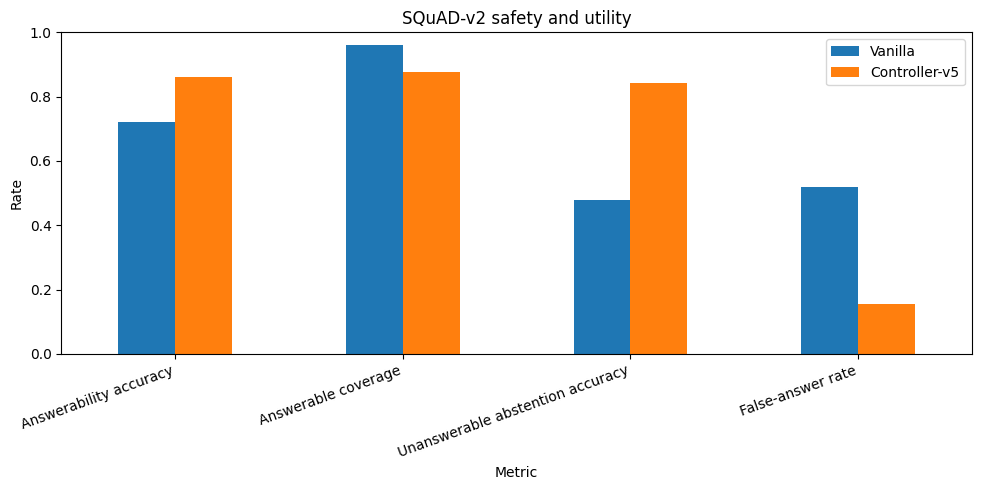

{
  "n_total": 1000,
  "n_answerable": 500,
  "n_unanswerable": 500,
  "vanilla_answerability_accuracy": 0.72,
  "controller_answerability_accuracy": 0.861,
  "vanilla_answerable_coverage": 0.96,
  "controller_answerable_coverage": 0.878,
  "vanilla_false_abstention_rate": 0.040000000000000036,
  "controller_false_abstention_rate": 0.122,
  "vanilla_unanswerable_abstention_accuracy": 0.48,
  "controller_unanswerable_abstention_accuracy": 0.844,
  "vanilla_false_answer_rate": 0.52,
  "controller_false_answer_rate": 0.156,
  "vanilla_answerable_exact_match_overall": 0.748,
  "controller_answerable_exact_match_overall": 0.696,
  "vanilla_answerable_token_f1_overall": 0.8647610710164568,
  "controller_answerable_token_f1_overall": 0.7839447790733967,
  "controller_answerable_token_f1_among_delivered": 0.89287560258929,
  "vanilla_mean_latency_sec": 0.30969696942599795,
  "controller_mean_latency_sec": 0.339389398861,
  "vanilla_p95_latency_sec": 0.6735263497001931,
  "controller_p95_latenc

In [20]:
squad_v2_answerable_indices = [
    index
    for index, answers
    in enumerate(
        squad_v2_validation[
            "answers"
        ]
    )
    if len(
        answers.get(
            "text",
            [],
        )
    ) > 0
]
squad_v2_unanswerable_indices = [
    index
    for index, answers
    in enumerate(
        squad_v2_validation[
            "answers"
        ]
    )
    if len(
        answers.get(
            "text",
            [],
        )
    ) == 0
]

# Reconstruct and exclude the earlier Controller-v4 sample.
rng_previous_v4 = np.random.default_rng(
    config.previous_v4_squad_v2_seed
)
previous_v4_answerable = set(
    rng_previous_v4.choice(
        squad_v2_answerable_indices,
        size=min(
            config.previous_v4_squad_v2_answerable,
            len(
                squad_v2_answerable_indices
            ),
        ),
        replace=False,
    )
    .astype(int)
    .tolist()
)
previous_v4_unanswerable = set(
    rng_previous_v4.choice(
        squad_v2_unanswerable_indices,
        size=min(
            config.previous_v4_squad_v2_unanswerable,
            len(
                squad_v2_unanswerable_indices
            ),
        ),
        replace=False,
    )
    .astype(int)
    .tolist()
)

pool_after_v4_answerable = [
    index
    for index in (
        squad_v2_answerable_indices
    )
    if index not in (
        previous_v4_answerable
    )
]
pool_after_v4_unanswerable = [
    index
    for index in (
        squad_v2_unanswerable_indices
    )
    if index not in (
        previous_v4_unanswerable
    )
]

# Reconstruct and exclude the earlier Controller-v5 sample.
rng_previous_v5 = np.random.default_rng(
    config.previous_v5_squad_v2_seed
)
previous_v5_answerable = set(
    rng_previous_v5.choice(
        pool_after_v4_answerable,
        size=min(
            config.previous_v5_squad_v2_answerable,
            len(
                pool_after_v4_answerable
            ),
        ),
        replace=False,
    )
    .astype(int)
    .tolist()
)
previous_v5_unanswerable = set(
    rng_previous_v5.choice(
        pool_after_v4_unanswerable,
        size=min(
            config.previous_v5_squad_v2_unanswerable,
            len(
                pool_after_v4_unanswerable
            ),
        ),
        replace=False,
    )
    .astype(int)
    .tolist()
)

fresh_answerable_pool = [
    index
    for index in (
        pool_after_v4_answerable
    )
    if index not in (
        previous_v5_answerable
    )
]
fresh_unanswerable_pool = [
    index
    for index in (
        pool_after_v4_unanswerable
    )
    if index not in (
        previous_v5_unanswerable
    )
]

rng_final_squad_v2 = np.random.default_rng(
    config.squad_v2_eval_seed
)
selected_squad_v2_answerable = (
    rng_final_squad_v2.choice(
        fresh_answerable_pool,
        size=min(
            config.squad_v2_answerable_eval_queries,
            len(
                fresh_answerable_pool
            ),
        ),
        replace=False,
    )
    .astype(int)
    .tolist()
)
selected_squad_v2_unanswerable = (
    rng_final_squad_v2.choice(
        fresh_unanswerable_pool,
        size=min(
            config.squad_v2_unanswerable_eval_queries,
            len(
                fresh_unanswerable_pool
            ),
        ),
        replace=False,
    )
    .astype(int)
    .tolist()
)
squad_v2_indices = sorted(
    selected_squad_v2_answerable
    + selected_squad_v2_unanswerable
)

assert set(
    selected_squad_v2_answerable
).isdisjoint(
    previous_v4_answerable
    | previous_v5_answerable
)
assert set(
    selected_squad_v2_unanswerable
).isdisjoint(
    previous_v4_unanswerable
    | previous_v5_unanswerable
)

probe_weights_digest = (
    state_dict_sha256(
        cev_probe,
        iav_probe,
    )
)
answerability_model_digest = (
    hashlib.sha256(
        pickle.dumps(
            answerability_model
        )
    ).hexdigest()
)
candidate_quality_model_digest = (
    hashlib.sha256(
        pickle.dumps(
            candidate_quality_model
        )
    ).hexdigest()
)

controller_run_spec = {
    "controller_code_version": (
        config.controller_code_version
    ),
    "dataset": (
        "rajpurkar/squad_v2:validation"
    ),
    "dataset_fingerprint": getattr(
        squad_v2_validation,
        "_fingerprint",
        None,
    ),
    "context_mode": (
        "assigned_paragraph_fixed"
    ),
    "answerable_rows": int(
        len(
            selected_squad_v2_answerable
        )
    ),
    "unanswerable_rows": int(
        len(
            selected_squad_v2_unanswerable
        )
    ),
    "excluded_previous_v4": {
        "answerable": int(
            len(
                previous_v4_answerable
            )
        ),
        "unanswerable": int(
            len(
                previous_v4_unanswerable
            )
        ),
    },
    "excluded_previous_v5": {
        "answerable": int(
            len(
                previous_v5_answerable
            )
        ),
        "unanswerable": int(
            len(
                previous_v5_unanswerable
            )
        ),
    },
    "selection_seed": (
        config.squad_v2_eval_seed
    ),
    "probe_weights_sha256": (
        probe_weights_digest
    ),
    "answerability_model_sha256": (
        answerability_model_digest
    ),
    "candidate_quality_model_sha256": (
        candidate_quality_model_digest
    ),
    "thresholds": {
        "retrieval_failure": (
            config
            .retrieval_failure_threshold
        ),
        "no_answer": (
            config.no_answer_threshold
        ),
        "candidate_accept": (
            config
            .candidate_bad_accept_threshold
        ),
        "candidate_abstain": (
            config
            .candidate_bad_abstain_threshold
        ),
    },
    "action_budget": {
        "max_attempts": (
            config.max_attempts
        ),
        "max_regenerations": (
            config.max_regenerations
        ),
        "max_reretrievals": 0,
    },
}
controller_fingerprint = (
    hashlib.sha256(
        json.dumps(
            controller_run_spec,
            sort_keys=True,
        ).encode("utf-8")
    ).hexdigest()[:16]
)
controller_spec_path = (
    TRACE_DIR
    / (
        "controller_v5_squadv2_spec_"
        f"{controller_fingerprint}.json"
    )
)
write_json(
    controller_spec_path,
    controller_run_spec,
)

squad_v2_trace_path = (
    TRACE_DIR
    / (
        "controller_v5_squadv2_traces_"
        f"{controller_fingerprint}.jsonl"
    )
)

existing_squad_v2_traces: Dict[
    str,
    Dict[str, Any],
] = {}
if squad_v2_trace_path.exists():
    with squad_v2_trace_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        for line in handle:
            if not line.strip():
                continue
            trace = json.loads(
                line
            )
            if (
                trace.get(
                    "controller_fingerprint"
                )
                != controller_fingerprint
            ):
                raise RuntimeError(
                    "Cached SQuAD-v2 trace "
                    "fingerprint mismatch."
                )
            existing_squad_v2_traces[
                str(
                    trace[
                        "squad_id"
                    ]
                )
            ] = trace

with squad_v2_trace_path.open(
    "a",
    encoding="utf-8",
) as handle:
    for dataset_index in tqdm(
        squad_v2_indices,
        desc=(
            "Final fresh SQuAD-v2 "
            "controller evaluation"
        ),
    ):
        row = squad_v2_validation[
            int(dataset_index)
        ]
        squad_id = str(
            row["id"]
        )
        if squad_id in (
            existing_squad_v2_traces
        ):
            continue

        query_seed = (
            config.squad_v2_eval_seed
            + int(
                hashlib.sha256(
                    squad_id.encode(
                        "utf-8"
                    )
                ).hexdigest()[:8],
                16,
            )
        ) % (2**31 - 1)

        trace = (
            controller.process_query(
                question=str(
                    row["question"]
                ),
                query_seed=(
                    query_seed
                ),
                fixed_context=str(
                    row["context"]
                ),
            )
        )
        gold_answers = [
            str(answer)
            for answer
            in row["answers"]["text"]
        ]
        trace.update({
            "controller_fingerprint": (
                controller_fingerprint
            ),
            "squad_id": squad_id,
            "dataset_index": int(
                dataset_index
            ),
            "gold_context": str(
                row["context"]
            ),
            "gold_answers": (
                gold_answers
            ),
            "is_answerable": bool(
                len(gold_answers)
                > 0
            ),
        })

        handle.write(
            json.dumps(
                json_safe(trace),
                allow_nan=False,
            )
            + "\n"
        )
        handle.flush()
        existing_squad_v2_traces[
            squad_id
        ] = trace

squad_v2_traces = [
    existing_squad_v2_traces[
        str(
            squad_v2_validation[
                int(index)
            ]["id"]
        )
    ]
    for index
    in squad_v2_indices
]
assert len(
    squad_v2_traces
) == len(
    squad_v2_indices
)

squad_v2_records: List[
    Dict[str, Any]
] = []
for trace in (
    squad_v2_traces
):
    baseline = trace[
        "history"
    ][0]
    true_answerable = bool(
        trace[
            "is_answerable"
        ]
    )
    vanilla_answered = bool(
        not is_refusal(
            baseline[
                "response"
            ]
        )
        and not baseline[
            "is_invalid"
        ]
    )
    controller_answered = bool(
        trace["status"]
        == "accepted"
        and not is_refusal(
            trace["response"]
        )
    )

    if true_answerable:
        vanilla_quality = (
            score_against_references(
                baseline[
                    "response"
                ],
                trace[
                    "gold_answers"
                ],
            )
        )
        controller_quality = (
            score_against_references(
                trace[
                    "response"
                ],
                trace[
                    "gold_answers"
                ],
            )
            if controller_answered
            else {
                "exact_match": 0.0,
                "token_f1": 0.0,
            }
        )
    else:
        vanilla_quality = {
            "exact_match": np.nan,
            "token_f1": np.nan,
        }
        controller_quality = {
            "exact_match": np.nan,
            "token_f1": np.nan,
        }

    squad_v2_records.append({
        "squad_id": (
            trace["squad_id"]
        ),
        "dataset_index": int(
            trace[
                "dataset_index"
            ]
        ),
        "question": (
            trace["question"]
        ),
        "is_answerable": (
            true_answerable
        ),
        "gold_answers": (
            " | ".join(
                trace[
                    "gold_answers"
                ]
            )
        ),
        "vanilla_response": (
            baseline[
                "response"
            ]
        ),
        "controller_response": (
            trace["response"]
        ),
        "controller_status": (
            trace["status"]
        ),
        "controller_terminal_reason": (
            trace[
                "terminal_reason"
            ]
        ),
        "controller_attempts": int(
            trace["attempts"]
        ),
        "vanilla_answered": (
            vanilla_answered
        ),
        "controller_answered": (
            controller_answered
        ),
        "vanilla_correct_answerability_decision": bool(
            vanilla_answered
            == true_answerable
        ),
        "controller_correct_answerability_decision": bool(
            controller_answered
            == true_answerable
        ),
        "vanilla_exact_match": (
            vanilla_quality[
                "exact_match"
            ]
        ),
        "vanilla_token_f1": (
            vanilla_quality[
                "token_f1"
            ]
        ),
        "controller_exact_match": (
            controller_quality[
                "exact_match"
            ]
        ),
        "controller_token_f1": (
            controller_quality[
                "token_f1"
            ]
        ),
        "vanilla_no_answer_probability": float(
            baseline[
                "no_answer_probability"
            ]
        ),
        "controller_final_no_answer_probability": float(
            trace["history"][-1][
                "no_answer_probability"
            ]
        ),
        "vanilla_latency_sec": float(
            baseline[
                "attempt_latency_sec"
            ]
        ),
        "controller_latency_sec": float(
            trace[
                "total_latency_sec"
            ]
        ),
        "action_sequence": (
            " -> ".join(
                attempt[
                    "action"
                ]
                for attempt
                in trace[
                    "history"
                ]
            )
        ),
    })

squad_v2_df = pd.DataFrame(
    squad_v2_records
)
answerable_v2_df = (
    squad_v2_df[
        squad_v2_df[
            "is_answerable"
        ].astype(bool)
    ].copy()
)
unanswerable_v2_df = (
    squad_v2_df[
        ~squad_v2_df[
            "is_answerable"
        ].astype(bool)
    ].copy()
)

answerability_accuracy_bootstrap = (
    paired_bootstrap_mean_difference(
        squad_v2_df[
            "controller_correct_answerability_decision"
        ].astype(float).to_numpy(),
        squad_v2_df[
            "vanilla_correct_answerability_decision"
        ].astype(float).to_numpy(),
        n_samples=(
            config.bootstrap_samples
        ),
        seed=(
            config.random_seed + 800
        ),
    )
)
false_answer_bootstrap = (
    paired_bootstrap_mean_difference(
        unanswerable_v2_df[
            "controller_answered"
        ].astype(float).to_numpy(),
        unanswerable_v2_df[
            "vanilla_answered"
        ].astype(float).to_numpy(),
        n_samples=(
            config.bootstrap_samples
        ),
        seed=(
            config.random_seed + 801
        ),
    )
)
answerable_f1_bootstrap = (
    paired_bootstrap_mean_difference(
        answerable_v2_df[
            "controller_token_f1"
        ].fillna(0.0).to_numpy(
            dtype=float
        ),
        answerable_v2_df[
            "vanilla_token_f1"
        ].fillna(0.0).to_numpy(
            dtype=float
        ),
        n_samples=(
            config.bootstrap_samples
        ),
        seed=(
            config.random_seed + 802
        ),
    )
)
answerable_coverage_bootstrap = (
    paired_bootstrap_mean_difference(
        answerable_v2_df[
            "controller_answered"
        ].astype(float).to_numpy(),
        answerable_v2_df[
            "vanilla_answered"
        ].astype(float).to_numpy(),
        n_samples=(
            config.bootstrap_samples
        ),
        seed=(
            config.random_seed + 803
        ),
    )
)

action_counts = Counter(
    attempt["action"]
    for trace in squad_v2_traces
    for attempt in trace["history"]
)
terminal_reason_counts = Counter(
    trace[
        "terminal_reason"
    ]
    for trace in squad_v2_traces
)

squad_v2_summary = {
    "n_total": int(
        len(
            squad_v2_df
        )
    ),
    "n_answerable": int(
        len(
            answerable_v2_df
        )
    ),
    "n_unanswerable": int(
        len(
            unanswerable_v2_df
        )
    ),
    "vanilla_answerability_accuracy": float(
        squad_v2_df[
            "vanilla_correct_answerability_decision"
        ].mean()
    ),
    "controller_answerability_accuracy": float(
        squad_v2_df[
            "controller_correct_answerability_decision"
        ].mean()
    ),
    "vanilla_answerable_coverage": float(
        answerable_v2_df[
            "vanilla_answered"
        ].mean()
    ),
    "controller_answerable_coverage": float(
        answerable_v2_df[
            "controller_answered"
        ].mean()
    ),
    "vanilla_false_abstention_rate": float(
        1.0
        - answerable_v2_df[
            "vanilla_answered"
        ].mean()
    ),
    "controller_false_abstention_rate": float(
        1.0
        - answerable_v2_df[
            "controller_answered"
        ].mean()
    ),
    "vanilla_unanswerable_abstention_accuracy": float(
        1.0
        - unanswerable_v2_df[
            "vanilla_answered"
        ].mean()
    ),
    "controller_unanswerable_abstention_accuracy": float(
        1.0
        - unanswerable_v2_df[
            "controller_answered"
        ].mean()
    ),
    "vanilla_false_answer_rate": float(
        unanswerable_v2_df[
            "vanilla_answered"
        ].mean()
    ),
    "controller_false_answer_rate": float(
        unanswerable_v2_df[
            "controller_answered"
        ].mean()
    ),
    "vanilla_answerable_exact_match_overall": float(
        answerable_v2_df[
            "vanilla_exact_match"
        ].fillna(0.0).mean()
    ),
    "controller_answerable_exact_match_overall": float(
        answerable_v2_df[
            "controller_exact_match"
        ].fillna(0.0).mean()
    ),
    "vanilla_answerable_token_f1_overall": float(
        answerable_v2_df[
            "vanilla_token_f1"
        ].fillna(0.0).mean()
    ),
    "controller_answerable_token_f1_overall": float(
        answerable_v2_df[
            "controller_token_f1"
        ].fillna(0.0).mean()
    ),
    "controller_answerable_token_f1_among_delivered": float(
        answerable_v2_df.loc[
            answerable_v2_df[
                "controller_answered"
            ].astype(bool),
            "controller_token_f1",
        ].mean()
        if answerable_v2_df[
            "controller_answered"
        ].any()
        else np.nan
    ),
    "vanilla_mean_latency_sec": float(
        squad_v2_df[
            "vanilla_latency_sec"
        ].mean()
    ),
    "controller_mean_latency_sec": float(
        squad_v2_df[
            "controller_latency_sec"
        ].mean()
    ),
    "vanilla_p95_latency_sec": float(
        np.quantile(
            squad_v2_df[
                "vanilla_latency_sec"
            ],
            0.95,
        )
    ),
    "controller_p95_latency_sec": float(
        np.quantile(
            squad_v2_df[
                "controller_latency_sec"
            ],
            0.95,
        )
    ),
    "action_counts_across_attempts": dict(
        action_counts
    ),
    "terminal_reason_counts": dict(
        terminal_reason_counts
    ),
    "paired_bootstrap_answerability_accuracy_change": (
        answerability_accuracy_bootstrap
    ),
    "paired_bootstrap_false_answer_rate_change": (
        false_answer_bootstrap
    ),
    "paired_bootstrap_answerable_f1_change": (
        answerable_f1_bootstrap
    ),
    "paired_bootstrap_answerable_coverage_change": (
        answerable_coverage_bootstrap
    ),
}

squad_v2_df.to_csv(
    SQUAD_V2_DIR
    / (
        "controller_v5_squadv2_"
        "final_evaluation.csv"
    ),
    index=False,
)
write_json(
    SQUAD_V2_DIR
    / (
        "controller_v5_squadv2_"
        "final_summary.json"
    ),
    squad_v2_summary,
)

summary_table = pd.DataFrame([
    {
        "Metric": (
            "Answerability accuracy"
        ),
        "Vanilla": (
            squad_v2_summary[
                "vanilla_answerability_accuracy"
            ]
        ),
        "Controller-v5": (
            squad_v2_summary[
                "controller_answerability_accuracy"
            ]
        ),
    },
    {
        "Metric": (
            "Answerable coverage"
        ),
        "Vanilla": (
            squad_v2_summary[
                "vanilla_answerable_coverage"
            ]
        ),
        "Controller-v5": (
            squad_v2_summary[
                "controller_answerable_coverage"
            ]
        ),
    },
    {
        "Metric": (
            "Unanswerable abstention accuracy"
        ),
        "Vanilla": (
            squad_v2_summary[
                "vanilla_unanswerable_abstention_accuracy"
            ]
        ),
        "Controller-v5": (
            squad_v2_summary[
                "controller_unanswerable_abstention_accuracy"
            ]
        ),
    },
    {
        "Metric": (
            "False-answer rate"
        ),
        "Vanilla": (
            squad_v2_summary[
                "vanilla_false_answer_rate"
            ]
        ),
        "Controller-v5": (
            squad_v2_summary[
                "controller_false_answer_rate"
            ]
        ),
    },
    {
        "Metric": (
            "Answerable token F1 — overall"
        ),
        "Vanilla": (
            squad_v2_summary[
                "vanilla_answerable_token_f1_overall"
            ]
        ),
        "Controller-v5": (
            squad_v2_summary[
                "controller_answerable_token_f1_overall"
            ]
        ),
    },
    {
        "Metric": (
            "Answerable token F1 — delivered"
        ),
        "Vanilla": np.nan,
        "Controller-v5": (
            squad_v2_summary[
                "controller_answerable_token_f1_among_delivered"
            ]
        ),
    },
])
display(
    summary_table
)

plot_metrics = [
    "Answerability accuracy",
    "Answerable coverage",
    "Unanswerable abstention accuracy",
    "False-answer rate",
]
plot_frame = (
    summary_table[
        summary_table[
            "Metric"
        ].isin(
            plot_metrics
        )
    ]
    .set_index(
        "Metric"
    )
)
ax = plot_frame.plot(
    kind="bar",
    figsize=(10, 5),
)
ax.set_ylim(
    0.0,
    1.0,
)
ax.set_ylabel(
    "Rate"
)
ax.set_title(
    "SQuAD-v2 safety and utility"
)
plt.xticks(
    rotation=20,
    ha="right",
)
plt.tight_layout()
safety_utility_plot_path = (
    SQUAD_V2_DIR
    / "squad_v2_safety_utility_metrics.png"
)
plt.savefig(
    safety_utility_plot_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()


# A separate two-point safety–utility scatter is intentionally omitted.
# The grouped bar chart above already communicates the same comparison
# more precisely and without redundant visual encoding.

print(
    json.dumps(
        json_safe(
            squad_v2_summary
        ),
        indent=2,
    )
)

## 21. Signal ablation: answerability, external verification, and CEV/IAV contribution

This ablation isolates the controller's main information sources on the same
frozen SQuAD-v2 examples.

The first four policies use the identical first-pass LLaMA response:

1. vanilla delivery;
2. the answerability gate only;
3. answerability plus external verification features, excluding CEV/IAV;
4. the complete first-pass feature set including fused CEV/IAV risk.

The fifth row reports the full multi-action Controller-v5, including diagnostic
regeneration. The comparison between rows 3 and 4 isolates the marginal effect
of the internal CEV/IAV signal without changing the generated response.

{'development_rows': 1000, 'vanilla_delivered': 738, 'answerability_only_delivered': 495, 'external_only_delivered': 493, 'full_signal_delivered': 492}


,policy,oof_candidate_bad_auroc,decision_threshold,answerability_accuracy,answerable_coverage,false_abstention_rate,unanswerable_abstention_accuracy,false_answer_rate,answerable_overall_f1,delivered_answerable_f1
0,Vanilla first pass,NaN,NaN,0.734,0.972,0.028,0.496,0.504,0.808571,0.831864
1,Answerability gate only,NaN,0.525000,0.951,0.946,0.054,0.956,0.044,0.797257,0.842766
2,External verification without CEV/IAV,0.948060,0.939295,0.953,0.946,0.054,0.960,0.040,0.797257,0.842766
3,Full first-pass signals with CEV/IAV,0.948175,0.930000,0.954,0.946,0.054,0.962,0.038,0.797257,0.842766


,policy,stage,answerability_accuracy,answerable_coverage,false_abstention_rate,unanswerable_abstention_accuracy,false_answer_rate,answerable_overall_f1,delivered_answerable_f1
0,Vanilla LLaMA,first_pass,0.720,0.960,0.040,0.480,0.520,0.850555,0.885995
1,Answerability gate only,first_pass,0.868,0.868,0.132,0.868,0.132,0.774563,0.892353
2,External verification without CEV/IAV,first_pass,0.865,0.860,0.140,0.870,0.130,0.772255,0.897971
3,Full signals with CEV/IAV,first_pass,0.866,0.860,0.140,0.872,0.128,0.772255,0.897971
4,Full multi-action Controller-v5,multi_action,0.861,0.878,0.122,0.844,0.156,0.783945,0.892876


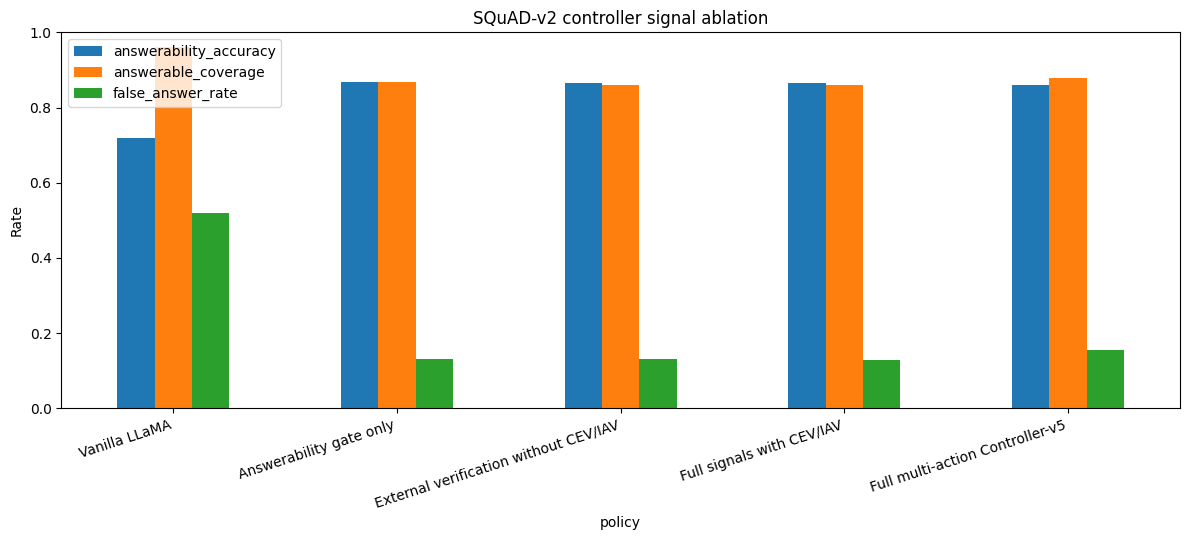

{
  "protocol": "paired signal ablation on identical frozen first-pass responses",
  "external_only_feature_names": [
    "retrieval_failure_probability",
    "no_answer_probability",
    "support_score",
    "support_margin",
    "relevance_score",
    "span_alignment_f1",
    "qa_margin",
    "is_refusal",
    "is_invalid",
    "word_count_scaled"
  ],
  "external_only_oof_bad_auroc": 0.9480595766268095,
  "external_only_threshold": 0.9392952535301446,
  "external_only_constraints_satisfied": true,
  "full_signal_threshold": 0.9299999999999999,
  "development_results": [
    {
      "policy": "Vanilla first pass",
      "oof_candidate_bad_auroc": null,
      "decision_threshold": null,
      "answerability_accuracy": 0.734,
      "answerable_coverage": 0.972,
      "false_abstention_rate": 0.028000000000000025,
      "unanswerable_abstention_accuracy": 0.496,
      "false_answer_rate": 0.504,
      "answerable_overall_f1": 0.8085713292715375,
      "delivered_answerable_f1": 0.831863

In [23]:
ABLATION_DIR = (
    CONTROLLER_OUTPUT_DIR
    / "signal_ablation"
)
ABLATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

EXTERNAL_ONLY_FEATURE_NAMES = [
    feature_name
    for feature_name
    in CANDIDATE_FEATURE_NAMES
    if feature_name
    != "fused_probability"
]

assert (
    "fused_probability"
    in CANDIDATE_FEATURE_NAMES
)
assert (
    "fused_probability"
    not in EXTERNAL_ONLY_FEATURE_NAMES
)


def fit_oof_candidate_model(
    feature_names: Sequence[str],
    random_seed: int,
) -> Tuple[
    Pipeline,
    np.ndarray,
]:
    X = (
        candidate_dev_df[
            list(feature_names)
        ].to_numpy(
            dtype=np.float32
        )
    )
    y = (
        candidate_dev_df[
            "bad_answer_label"
        ].astype(int).to_numpy()
    )

    oof_probability = np.zeros(
        len(y),
        dtype=np.float64,
    )
    splitter = StratifiedKFold(
        n_splits=(
            config
            .candidate_quality_oof_folds
        ),
        shuffle=True,
        random_state=(
            random_seed
        ),
    )

    for fold_index, (
        fold_train,
        fold_validation,
    ) in enumerate(
        splitter.split(
            X,
            y,
        ),
        start=1,
    ):
        fold_model = Pipeline([
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "logistic",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=3000,
                    random_state=(
                        random_seed
                        + fold_index
                    ),
                ),
            ),
        ])
        fold_model.fit(
            X[
                fold_train
            ],
            y[
                fold_train
            ],
        )
        oof_probability[
            fold_validation
        ] = (
            fold_model
            .predict_proba(
                X[
                    fold_validation
                ]
            )[:, 1]
        )

    final_model = Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "logistic",
            LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                random_state=(
                    random_seed
                ),
            ),
        ),
    ])
    final_model.fit(
        X,
        y,
    )
    return (final_model, oof_probability)


def compute_policy_metrics(
    is_answerable: np.ndarray,
    delivered: np.ndarray,
    answer_token_f1: np.ndarray,
) -> Dict[str, float]:
    is_answerable = np.asarray(
        is_answerable,
        dtype=bool,
    )
    delivered = np.asarray(
        delivered,
        dtype=bool,
    )
    answer_token_f1 = np.asarray(
        answer_token_f1,
        dtype=float,
    )

    answerable_mask = (
        is_answerable
    )
    unanswerable_mask = (
        ~is_answerable
    )

    answerable_coverage = float(
        delivered[
            answerable_mask
        ].mean()
    )
    false_answer_rate = float(
        delivered[
            unanswerable_mask
        ].mean()
    )
    answerability_accuracy = float(
        (
            delivered
            == is_answerable
        ).mean()
    )
    answerable_overall_f1 = float(
        np.where(
            delivered[
                answerable_mask
            ],
            answer_token_f1[
                answerable_mask
            ],
            0.0,
        ).mean()
    )
    delivered_answerable_mask = (
        answerable_mask
        & delivered
    )
    delivered_answerable_f1 = float(
        answer_token_f1[
            delivered_answerable_mask
        ].mean()
        if delivered_answerable_mask.any()
        else 0.0
    )

    return {
        "answerability_accuracy": (
            answerability_accuracy
        ),
        "answerable_coverage": (
            answerable_coverage
        ),
        "false_abstention_rate": float(
            1.0
            - answerable_coverage
        ),
        "unanswerable_abstention_accuracy": float(
            1.0
            - false_answer_rate
        ),
        "false_answer_rate": (
            false_answer_rate
        ),
        "answerable_overall_f1": (
            answerable_overall_f1
        ),
        "delivered_answerable_f1": (
            delivered_answerable_f1
        ),
    }


def select_ablation_operating_point(
    bad_probability: np.ndarray,
    policy_name: str,
) -> Tuple[
    pd.Series,
    pd.DataFrame,
    bool,
]:
    bad_probability = np.asarray(
        bad_probability,
        dtype=float,
    )

    threshold_values = np.unique(
        np.concatenate([
            np.linspace(
                0.01,
                0.99,
                99,
            ),
            np.quantile(
                bad_probability,
                np.linspace(
                    0.01,
                    0.99,
                    33,
                ),
            ),
        ])
    )

    rows: List[
        Dict[str, Any]
    ] = []
    for threshold in (
        threshold_values
    ):
        delivered = (
            valid_nonrefusal_dev
            & (
                ~predicted_no_answer_dev
            )
            & (
                bad_probability
                <= threshold
            )
        )
        metrics = (
            compute_policy_metrics(
                is_answerable=(
                    is_answerable_dev
                ),
                delivered=delivered,
                answer_token_f1=(
                    answerable_token_f1_dev
                ),
            )
        )
        rows.append({
            "policy": policy_name,
            "threshold": float(
                threshold
            ),
            **metrics,
        })

    operating_points = (
        pd.DataFrame(
            rows
        )
    )
    feasible = (
        operating_points[
            (
                operating_points[
                    "answerable_coverage"
                ]
                >= (
                    config
                    .controller_min_answerable_coverage
                )
            )
            & (
                operating_points[
                    "false_answer_rate"
                ]
                <= (
                    config
                    .controller_max_unanswerable_false_answer_rate
                )
            )
        ]
    )

    constraints_satisfied = bool(
        len(feasible)
        > 0
    )
    if constraints_satisfied:
        selected = (
            feasible
            .sort_values(
                [
                    "answerability_accuracy",
                    "answerable_overall_f1",
                    "delivered_answerable_f1",
                    "false_answer_rate",
                ],
                ascending=[
                    False,
                    False,
                    False,
                    True,
                ],
            )
            .iloc[0]
        )
    else:
        selected = (
            operating_points
            .assign(
                coverage_shortfall=(
                    np.maximum(
                        0.0,
                        (
                            config
                            .controller_min_answerable_coverage
                            - operating_points[
                                "answerable_coverage"
                            ]
                        ),
                    )
                ),
                safety_excess=(
                    np.maximum(
                        0.0,
                        (
                            operating_points[
                                "false_answer_rate"
                            ]
                            - config
                            .controller_max_unanswerable_false_answer_rate
                        ),
                    )
                ),
            )
            .sort_values(
                [
                    "coverage_shortfall",
                    "safety_excess",
                    "answerability_accuracy",
                    "answerable_overall_f1",
                ],
                ascending=[
                    True,
                    True,
                    False,
                    False,
                ],
            )
            .iloc[0]
        )

    return (
        selected,
        operating_points,
        constraints_satisfied,
    )


(
    external_only_candidate_model,
    external_only_oof_bad_probability,
) = fit_oof_candidate_model(
    feature_names=(
        EXTERNAL_ONLY_FEATURE_NAMES
    ),
    random_seed=(
        config.random_seed
        + 910
    ),
)

external_only_oof_auroc = float(
    roc_auc_score(
        candidate_bad_y,
        external_only_oof_bad_probability,
    )
)

(
    external_only_selected_gate,
    external_only_operating_points_df,
    external_only_constraints_satisfied,
) = select_ablation_operating_point(
    bad_probability=(
        external_only_oof_bad_probability
    ),
    policy_name=(
        "External verification without CEV/IAV"
    ),
)
external_only_threshold = float(
    external_only_selected_gate[
        "threshold"
    ]
)

# ============================================================
# Development-policy delivery masks
# ============================================================

# Convert all development signals to aligned NumPy arrays.
valid_nonrefusal_dev = np.asarray(
    valid_nonrefusal_dev,
    dtype=bool,
)

predicted_no_answer_dev = np.asarray(
    predicted_no_answer_dev,
    dtype=bool,
)

external_only_oof_bad_probability = np.asarray(
    external_only_oof_bad_probability,
    dtype=np.float64,
)

candidate_oof_bad_probability = np.asarray(
    candidate_oof_bad_probability,
    dtype=np.float64,
)

is_answerable_dev = np.asarray(
    is_answerable_dev,
    dtype=bool,
)

answerable_token_f1_dev = np.asarray(
    answerable_token_f1_dev,
    dtype=np.float64,
)

# Confirm that every development array refers to the same rows.
development_length = len(
    candidate_dev_df
)

for array_name, array_value in {
    "valid_nonrefusal_dev": valid_nonrefusal_dev,
    "predicted_no_answer_dev": predicted_no_answer_dev,
    "external_only_oof_bad_probability": (
        external_only_oof_bad_probability
    ),
    "candidate_oof_bad_probability": (
        candidate_oof_bad_probability
    ),
    "is_answerable_dev": is_answerable_dev,
    "answerable_token_f1_dev": (
        answerable_token_f1_dev
    ),
}.items():
    if len(array_value) != development_length:
        raise RuntimeError(
            f"{array_name} has {len(array_value)} rows, "
            f"but candidate_dev_df has "
            f"{development_length} rows."
        )

# Policy 1: Vanilla first-pass delivery
vanilla_dev_delivered = (
    valid_nonrefusal_dev.copy()
)

# Policy 2: Answerability gate only
answerability_only_dev_delivered = (
    valid_nonrefusal_dev
    & (
        ~predicted_no_answer_dev
    )
)

# Policy 3: External verification without CEV/IAV
external_only_dev_delivered = (
    answerability_only_dev_delivered
    & (
        external_only_oof_bad_probability
        <= external_only_threshold
    )
)

# Policy 4: Full first-pass signals including CEV/IAV
full_signal_dev_delivered = (
    answerability_only_dev_delivered
    & (
        candidate_oof_bad_probability
        <= (
            config
            .candidate_bad_accept_threshold
        )
    )
)

# Final sanity checks.
assert vanilla_dev_delivered.dtype == bool
assert answerability_only_dev_delivered.dtype == bool
assert external_only_dev_delivered.dtype == bool
assert full_signal_dev_delivered.dtype == bool

print({
    "development_rows": int(
        development_length
    ),
    "vanilla_delivered": int(
        vanilla_dev_delivered.sum()
    ),
    "answerability_only_delivered": int(
        answerability_only_dev_delivered.sum()
    ),
    "external_only_delivered": int(
        external_only_dev_delivered.sum()
    ),
    "full_signal_delivered": int(
        full_signal_dev_delivered.sum()
    ),
})

development_ablation_rows = []
for (
    policy_name,
    delivered,
    oof_bad_auroc,
    threshold,
) in [
    (
        "Vanilla first pass",
        vanilla_dev_delivered,
        np.nan,
        np.nan,
    ),
    (
        "Answerability gate only",
        answerability_only_dev_delivered,
        np.nan,
        config.no_answer_threshold,
    ),
    (
        "External verification without CEV/IAV",
        external_only_dev_delivered,
        external_only_oof_auroc,
        external_only_threshold,
    ),
    (
        "Full first-pass signals with CEV/IAV",
        full_signal_dev_delivered,
        float(
            roc_auc_score(
                candidate_bad_y,
                candidate_oof_bad_probability,
            )
        ),
        config
        .candidate_bad_accept_threshold,
    ),
]:
    development_ablation_rows.append({
        "policy": policy_name,
        "oof_candidate_bad_auroc": (
            oof_bad_auroc
        ),
        "decision_threshold": (
            threshold
        ),
        **compute_policy_metrics(
            is_answerable=(
                is_answerable_dev
            ),
            delivered=delivered,
            answer_token_f1=(
                answerable_token_f1_dev
            ),
        ),
    })

development_ablation_df = (
    pd.DataFrame(
        development_ablation_rows
    )
)

def first_attempt_feature_row(
    attempt: Dict[str, Any],
    feature_names: Sequence[str],
) -> np.ndarray:
    feature_map = {
        "fused_probability": float(
            attempt[
                "fused_probability"
            ]
        ),
        "retrieval_failure_probability": float(
            attempt[
                "retrieval_failure_probability"
            ]
        ),
        "no_answer_probability": float(
            attempt[
                "no_answer_probability"
            ]
        ),
        "support_score": float(
            attempt[
                "support_score"
            ]
        ),
        "support_margin": float(
            attempt[
                "support_margin"
            ]
        ),
        "relevance_score": float(
            attempt[
                "relevance_score"
            ]
        ),
        "span_alignment_f1": float(
            attempt[
                "span_alignment_f1"
            ]
        ),
        "qa_margin": float(
            attempt[
                "qa_margin"
            ]
        ),
        "is_refusal": float(
            attempt[
                "is_refusal"
            ]
        ),
        "is_invalid": float(
            attempt[
                "is_invalid"
            ]
        ),
        "word_count_scaled": float(
            attempt[
                "word_count"
            ]
            / max(
                1,
                config
                .response_max_words,
            )
        ),
    }
    return np.asarray([
        feature_map[
            feature_name
        ]
        for feature_name
        in feature_names
    ], dtype=np.float32)


first_attempts = [
    trace[
        "history"
    ][0]
    for trace
    in squad_v2_traces
]
external_only_test_X = np.vstack([
    first_attempt_feature_row(
        attempt,
        EXTERNAL_ONLY_FEATURE_NAMES,
    )
    for attempt
    in first_attempts
])
external_only_test_bad_probability = (
    external_only_candidate_model
    .predict_proba(
        external_only_test_X
    )[:, 1]
)

test_is_answerable = (
    squad_v2_df[
        "is_answerable"
    ].astype(bool).to_numpy()
)
test_vanilla_f1 = (
    squad_v2_df[
        "vanilla_token_f1"
    ].fillna(0.0).to_numpy(
        dtype=float
    )
)
test_controller_f1 = (
    squad_v2_df[
        "controller_token_f1"
    ].fillna(0.0).to_numpy(
        dtype=float
    )
)
test_valid_nonrefusal = np.asarray([
    (
        not attempt[
            "is_refusal"
        ]
        and not attempt[
            "is_invalid"
        ]
    )
    for attempt
    in first_attempts
], dtype=bool)
test_predicted_no_answer = np.asarray([
    (
        attempt[
            "no_answer_probability"
        ]
        >= config
        .no_answer_threshold
    )
    for attempt
    in first_attempts
], dtype=bool)
test_full_bad_probability = np.asarray([
    attempt[
        "candidate_bad_probability"
    ]
    for attempt
    in first_attempts
], dtype=float)

vanilla_test_delivered = (
    test_valid_nonrefusal
)
answerability_only_test_delivered = (
    test_valid_nonrefusal
    & (
        ~test_predicted_no_answer
    )
)
external_only_test_delivered = (
    answerability_only_test_delivered
    & (
        external_only_test_bad_probability
        <= external_only_threshold
    )
)
full_signal_test_delivered = (
    answerability_only_test_delivered
    & (
        test_full_bad_probability
        <= (
            config
            .candidate_bad_accept_threshold
        )
    )
)
full_controller_test_delivered = (
    squad_v2_df[
        "controller_answered"
    ].astype(bool).to_numpy()
)

final_ablation_rows = []
for (
    policy_name,
    policy_stage,
    delivered,
    token_f1_values,
) in [
    (
        "Vanilla LLaMA",
        "first_pass",
        vanilla_test_delivered,
        test_vanilla_f1,
    ),
    (
        "Answerability gate only",
        "first_pass",
        answerability_only_test_delivered,
        test_vanilla_f1,
    ),
    (
        "External verification without CEV/IAV",
        "first_pass",
        external_only_test_delivered,
        test_vanilla_f1,
    ),
    (
        "Full signals with CEV/IAV",
        "first_pass",
        full_signal_test_delivered,
        test_vanilla_f1,
    ),
    (
        "Full multi-action Controller-v5",
        "multi_action",
        full_controller_test_delivered,
        test_controller_f1,
    ),
]:
    final_ablation_rows.append({
        "policy": policy_name,
        "stage": policy_stage,
        **compute_policy_metrics(
            is_answerable=(
                test_is_answerable
            ),
            delivered=delivered,
            answer_token_f1=(
                token_f1_values
            ),
        ),
    })

final_ablation_df = pd.DataFrame(
    final_ablation_rows
)

answerable_test_mask = (
    test_is_answerable
)
unanswerable_test_mask = (
    ~test_is_answerable
)

cev_iav_ablation_bootstrap = {
    "answerability_accuracy_change": (
        paired_bootstrap_mean_difference(
            first=(
                (
                    full_signal_test_delivered
                    == test_is_answerable
                ).astype(float)
            ),
            second=(
                (
                    external_only_test_delivered
                    == test_is_answerable
                ).astype(float)
            ),
            n_samples=(
                config.bootstrap_samples
            ),
            seed=(
                config.random_seed
                + 920
            ),
        )
    ),
    "false_answer_rate_change": (
        paired_bootstrap_mean_difference(
            first=(
                full_signal_test_delivered[
                    unanswerable_test_mask
                ].astype(float)
            ),
            second=(
                external_only_test_delivered[
                    unanswerable_test_mask
                ].astype(float)
            ),
            n_samples=(
                config.bootstrap_samples
            ),
            seed=(
                config.random_seed
                + 921
            ),
        )
    ),
    "answerable_coverage_change": (
        paired_bootstrap_mean_difference(
            first=(
                full_signal_test_delivered[
                    answerable_test_mask
                ].astype(float)
            ),
            second=(
                external_only_test_delivered[
                    answerable_test_mask
                ].astype(float)
            ),
            n_samples=(
                config.bootstrap_samples
            ),
            seed=(
                config.random_seed
                + 922
            ),
        )
    ),
    "answerable_overall_f1_change": (
        paired_bootstrap_mean_difference(
            first=(
                np.where(
                    full_signal_test_delivered[
                        answerable_test_mask
                    ],
                    test_vanilla_f1[
                        answerable_test_mask
                    ],
                    0.0,
                )
            ),
            second=(
                np.where(
                    external_only_test_delivered[
                        answerable_test_mask
                    ],
                    test_vanilla_f1[
                        answerable_test_mask
                    ],
                    0.0,
                )
            ),
            n_samples=(
                config.bootstrap_samples
            ),
            seed=(
                config.random_seed
                + 923
            ),
        )
    ),
}

ablation_summary = {
    "protocol": (
        "paired signal ablation on identical frozen first-pass responses"
    ),
    "external_only_feature_names": (
        EXTERNAL_ONLY_FEATURE_NAMES
    ),
    "external_only_oof_bad_auroc": (
        external_only_oof_auroc
    ),
    "external_only_threshold": (
        external_only_threshold
    ),
    "external_only_constraints_satisfied": (
        external_only_constraints_satisfied
    ),
    "full_signal_threshold": (
        config
        .candidate_bad_accept_threshold
    ),
    "development_results": (
        development_ablation_df
        .to_dict(
            orient="records"
        )
    ),
    "final_results": (
        final_ablation_df
        .to_dict(
            orient="records"
        )
    ),
    "cev_iav_marginal_effect_bootstrap": (
        cev_iav_ablation_bootstrap
    ),
    "interpretation_note": (
        "Rows 3 and 4 use the same generated answer; their difference "
        "isolates the decision contribution of the fused CEV/IAV feature. "
        "The final row additionally includes diagnostic regeneration."
    ),
}

development_ablation_df.to_csv(
    ABLATION_DIR
    / "signal_ablation_development.csv",
    index=False,
)
external_only_operating_points_df.to_csv(
    ABLATION_DIR
    / "external_only_operating_points.csv",
    index=False,
)
final_ablation_df.to_csv(
    ABLATION_DIR
    / "signal_ablation_final.csv",
    index=False,
)
write_json(
    ABLATION_DIR
    / "signal_ablation_summary.json",
    ablation_summary,
)
with (
    ABLATION_DIR
    / "external_only_candidate_model.pkl"
).open("wb") as handle:
    pickle.dump({
        "model": (
            external_only_candidate_model
        ),
        "feature_names": (
            EXTERNAL_ONLY_FEATURE_NAMES
        ),
        "threshold": (
            external_only_threshold
        ),
        "oof_auroc": (
            external_only_oof_auroc
        ),
    }, handle)

display(
    development_ablation_df
)
display(
    final_ablation_df
)

ablation_plot_metrics = [
    "answerability_accuracy",
    "answerable_coverage",
    "false_answer_rate",
]
ablation_plot_frame = (
    final_ablation_df[
        [
            "policy",
            *ablation_plot_metrics,
        ]
    ]
    .set_index(
        "policy"
    )
)
ax = ablation_plot_frame.plot(
    kind="bar",
    figsize=(12, 5.5),
)
ax.set_ylim(
    0.0,
    1.0,
)
ax.set_ylabel(
    "Rate"
)
ax.set_title(
    "SQuAD-v2 controller signal ablation"
)
plt.xticks(
    rotation=18,
    ha="right",
)
plt.tight_layout()
ablation_plot_path = (
    ABLATION_DIR
    / "controller_signal_ablation.png"
)
plt.savefig(
    ablation_plot_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close()

print(
    json.dumps(
        json_safe(
            ablation_summary
        ),
        indent=2,
    )
)

## 22. Automatically selected varied Controller demonstrations

This block replaces manually written demonstration questions. It
selects real examples from the untouched SQuAD-v2 final evaluation and shows
the exact response delivered to the end user, together with the controller's
attempt sequence and decision signals.

In [24]:
trace_by_id = {
    str(
        trace["squad_id"]
    ): trace
    for trace in squad_v2_traces
}

demo_candidates = (
    squad_v2_df.copy()
)
demo_candidates[
    "f1_improvement"
] = (
    demo_candidates[
        "controller_token_f1"
    ].fillna(0.0)
    - demo_candidates[
        "vanilla_token_f1"
    ].fillna(0.0)
)

demo_definitions = [
    {
        "category": (
            "Correct answer accepted"
        ),
        "description": (
            "An answerable question for which the controller "
            "delivered a high-quality answer."
        ),
        "mask": (
            demo_candidates[
                "is_answerable"
            ].astype(bool)
            & demo_candidates[
                "controller_answered"
            ].astype(bool)
            & (
                demo_candidates[
                    "controller_token_f1"
                ].fillna(0.0)
                >= 0.80
            )
        ),
        "sort_column": (
            "controller_token_f1"
        ),
        "ascending": False,
    },
    {
        "category": (
            "Safe abstention on an unanswerable question"
        ),
        "description": (
            "The assigned paragraph does not answer the question, "
            "and the controller withheld an unsupported response."
        ),
        "mask": (
            ~demo_candidates[
                "is_answerable"
            ].astype(bool)
            & ~demo_candidates[
                "controller_answered"
            ].astype(bool)
        ),
        "sort_column": (
            "controller_final_no_answer_probability"
        ),
        "ascending": False,
    },
    {
        "category": (
            "Successful diagnostic regeneration"
        ),
        "description": (
            "The controller rejected the first candidate, regenerated "
            "once with diagnostic feedback, and improved answer quality."
        ),
        "mask": (
            demo_candidates[
                "is_answerable"
            ].astype(bool)
            & demo_candidates[
                "controller_answered"
            ].astype(bool)
            & demo_candidates[
                "action_sequence"
            ].str.contains(
                "regenerate",
                regex=False,
            )
            & (
                demo_candidates[
                    "f1_improvement"
                ]
                > 0.10
            )
        ),
        "sort_column": (
            "f1_improvement"
        ),
        "ascending": False,
    },
    {
        "category": (
            "Protective abstention after an unsafe first answer"
        ),
        "description": (
            "Vanilla generation answered an unanswerable question, "
            "but the controller's final output was abstention."
        ),
        "mask": (
            ~demo_candidates[
                "is_answerable"
            ].astype(bool)
            & demo_candidates[
                "vanilla_answered"
            ].astype(bool)
            & ~demo_candidates[
                "controller_answered"
            ].astype(bool)
        ),
        "sort_column": (
            "controller_final_no_answer_probability"
        ),
        "ascending": False,
    },
    {
        "category": (
            "False abstention on an answerable question"
        ),
        "description": (
            "The question was answerable from its paragraph, "
            "but the controller withheld the response."
        ),
        "mask": (
            demo_candidates[
                "is_answerable"
            ].astype(bool)
            & ~demo_candidates[
                "controller_answered"
            ].astype(bool)
        ),
        "sort_column": (
            "vanilla_token_f1"
        ),
        "ascending": False,
    },
    {
        "category": (
            "Accepted unsupported answer"
        ),
        "description": (
            "The SQuAD-v2 item is unanswerable from its assigned paragraph, "
            "but the controller still delivered a response."
        ),
        "mask": (
            ~demo_candidates[
                "is_answerable"
            ].astype(bool)
            & demo_candidates[
                "controller_answered"
            ].astype(bool)
        ),
        "sort_column": (
            "controller_final_no_answer_probability"
        ),
        "ascending": False,
    },
]

selected_demo_ids: set = set()
controller_demo_records: List[
    Dict[str, Any]
] = []

for definition in (
    demo_definitions
):
    subset = (
        demo_candidates[
            definition["mask"]
        ]
        .copy()
    )
    subset = subset[
        ~subset[
            "squad_id"
        ].astype(str).isin(
            selected_demo_ids
        )
    ]

    if len(subset):
        subset = subset.sort_values(
            definition[
                "sort_column"
            ],
            ascending=(
                definition[
                    "ascending"
                ]
            ),
        )
        selected_row = (
            subset.iloc[0]
        )
        squad_id = str(
            selected_row[
                "squad_id"
            ]
        )
        selected_demo_ids.add(
            squad_id
        )
        trace = trace_by_id[
            squad_id
        ]

        attempt_rows: List[
            Dict[str, Any]
        ] = []
        for attempt in (
            trace["history"]
        ):
            attempt_rows.append({
                "attempt": int(
                    attempt[
                        "attempt"
                    ]
                ),
                "candidate_response": (
                    attempt[
                        "response"
                    ]
                ),
                "action": (
                    attempt[
                        "action"
                    ]
                ),
                "action_reason": (
                    attempt[
                        "action_reason"
                    ]
                ),
                "no_answer_probability": float(
                    attempt[
                        "no_answer_probability"
                    ]
                ),
                "candidate_bad_probability": float(
                    attempt[
                        "candidate_bad_probability"
                    ]
                ),
                "fused_hallucination_probability": float(
                    attempt[
                        "fused_probability"
                    ]
                ),
                "support_score": float(
                    attempt[
                        "support_score"
                    ]
                ),
                "relevance_score": float(
                    attempt[
                        "relevance_score"
                    ]
                ),
            })

        record = {
            "category": (
                definition[
                    "category"
                ]
            ),
            "description": (
                definition[
                    "description"
                ]
            ),
            "observed": True,
            "squad_id": squad_id,
            "question": (
                selected_row[
                    "question"
                ]
            ),
            "is_answerable": bool(
                selected_row[
                    "is_answerable"
                ]
            ),
            "gold_answers": (
                selected_row[
                    "gold_answers"
                ]
            ),
            "vanilla_first_response": (
                selected_row[
                    "vanilla_response"
                ]
            ),
            "final_user_visible_output": (
                selected_row[
                    "controller_response"
                ]
            ),
            "final_status": (
                selected_row[
                    "controller_status"
                ]
            ),
            "terminal_reason": (
                selected_row[
                    "controller_terminal_reason"
                ]
            ),
            "action_sequence": (
                selected_row[
                    "action_sequence"
                ]
            ),
            "vanilla_token_f1": (
                selected_row[
                    "vanilla_token_f1"
                ]
            ),
            "controller_token_f1": (
                selected_row[
                    "controller_token_f1"
                ]
            ),
            "attempts": attempt_rows,
        }
    else:
        record = {
            "category": (
                definition[
                    "category"
                ]
            ),
            "description": (
                definition[
                    "description"
                ]
            ),
            "observed": False,
            "note": (
                "No example of this category "
                "occurred in the frozen final sample."
            ),
        }

    controller_demo_records.append(
        record
    )

demo_summary_df = pd.DataFrame([
    {
        "Category": record[
            "category"
        ],
        "Observed": bool(
            record[
                "observed"
            ]
        ),
        "Question": (
            record.get(
                "question",
                "",
            )
        ),
        "Final user-visible output": (
            record.get(
                "final_user_visible_output",
                "",
            )
        ),
        "Action sequence": (
            record.get(
                "action_sequence",
                "",
            )
        ),
    }
    for record in (
        controller_demo_records
    )
])
display(
    demo_summary_df
)

for record in (
    controller_demo_records
):
    print(
        "\n"
        + "=" * 92
    )
    print(
        record[
            "category"
        ]
    )
    print(
        "=" * 92
    )
    print(
        record[
            "description"
        ]
    )

    if not record[
        "observed"
    ]:
        print(
            record["note"]
        )
        continue

    print(
        f"Question: "
        f"{record['question']}"
    )
    print(
        f"Ground-truth answerability: "
        f"{'answerable' if record['is_answerable'] else 'unanswerable'}"
    )
    print(
        f"Gold answer(s): "
        f"{record['gold_answers'] or '[none]'}"
    )
    print(
        f"Vanilla first response: "
        f"{record['vanilla_first_response']}"
    )
    print(
        f"Final response delivered to user: "
        f"{record['final_user_visible_output']}"
    )
    print(
        f"Final decision: "
        f"{record['final_status']} "
        f"({record['terminal_reason']})"
    )
    print(
        f"Action sequence: "
        f"{record['action_sequence']}"
    )

    attempt_table = pd.DataFrame(
        record[
            "attempts"
        ]
    )
    display(
        attempt_table
    )

write_json(
    DEMO_DIR
    / (
        "squad_v2_varied_controller_"
        "demonstrations.json"
    ),
    controller_demo_records,
)
demo_summary_df.to_csv(
    DEMO_DIR
    / (
        "squad_v2_varied_controller_"
        "demonstrations_summary.csv"
    ),
    index=False,
)

print({
    "observed_categories": int(
        demo_summary_df[
            "Observed"
        ].sum()
    ),
    "total_categories": int(
        len(
            demo_summary_df
        )
    ),
    "output_directory": (
        str(DEMO_DIR)
    ),
})

,Category,Observed,Question,Final user-visible output,Action sequence
0,Correct answer accepted,True,What is QED short for?,quantum electrodynamics,accept
1,Safe abstention on an unanswerable question,True,How is time not required to solve a problem ca...,[ABSTAIN],abstain
2,Successful diagnostic regeneration,True,"What is the complex ""two-signal"" activation of...",histocompatibility,regenerate -> accept
3,Protective abstention after an unsafe first an...,True,What wasn't Marin's orders?,[ABSTAIN],abstain
4,False abstention on an answerable question,True,What is the original meaning of the word Norman?,[ABSTAIN],abstain
5,Accepted unsupported answer,True,When did the age of Imperialism end?,The middle of the 20th century.,accept



Correct answer accepted
An answerable question for which the controller delivered a high-quality answer.
Question: What is QED short for?
Ground-truth answerability: answerable
Gold answer(s): quantum electrodynamics | quantum electrodynamics | quantum electrodynamics | quantum electrodynamics
Vanilla first response: quantum electrodynamics
Final response delivered to user: quantum electrodynamics
Final decision: accepted (passed_calibrated_quality_and_answerability_gates)
Action sequence: accept


,attempt,candidate_response,action,action_reason,no_answer_probability,candidate_bad_probability,fused_hallucination_probability,support_score,relevance_score
0,1,quantum electrodynamics,accept,passed_calibrated_quality_and_answerability_gates,0.022981,0.117481,0.186132,0.116583,0.00034



Safe abstention on an unanswerable question
The assigned paragraph does not answer the question, and the controller withheld an unsupported response.
Question: How is time not required to solve a problem calculated?
Ground-truth answerability: unanswerable
Gold answer(s): [none]
Vanilla first response: As a function of the size of the instance.
Final response delivered to user: [ABSTAIN]
Final decision: abstained (evidence_predicted_unanswerable)
Action sequence: abstain


,attempt,candidate_response,action,action_reason,no_answer_probability,candidate_bad_probability,fused_hallucination_probability,support_score,relevance_score
0,1,As a function of the size of the instance.,abstain,evidence_predicted_unanswerable,0.999968,0.975879,0.057291,0.003273,0.000017


...


False abstention on an answerable question
The question was answerable from its paragraph, but the controller withheld the response.
Question: What is the original meaning of the word Norman?
Ground-truth answerability: answerable
Gold answer(s): Viking | Norseman, Viking | Norseman, Viking
Vanilla first response: Norseman, Viking.
Final response delivered to user: [ABSTAIN]
Final decision: abstained (evidence_predicted_unanswerable)
Action sequence: abstain


,attempt,candidate_response,action,action_reason,no_answer_probability,candidate_bad_probability,fused_hallucination_probability,support_score,relevance_score
0,1,"Norseman, Viking.",abstain,evidence_predicted_unanswerable,0.545991,0.629484,0.081163,0.017645,0.000068



Accepted unsupported answer
The SQuAD-v2 item is unanswerable from its assigned paragraph, but the controller still delivered a response.
Question:  When did the age of Imperialism end?
Ground-truth answerability: unanswerable
Gold answer(s): [none]
Vanilla first response: The middle of the 20th century.
Final response delivered to user: The middle of the 20th century.
Final decision: accepted (passed_calibrated_quality_and_answerability_gates)
Action sequence: accept


,attempt,candidate_response,action,action_reason,no_answer_probability,candidate_bad_probability,fused_hallucination_probability,support_score,relevance_score
0,1,The middle of the 20th century.,accept,passed_calibrated_quality_and_answerability_gates,0.496607,0.627489,0.226907,0.042344,0.00504


{'observed_categories': 6, 'total_categories': 6, 'output_directory': '/content/drive/MyDrive/llama_colab_a100_ragtruth18k_test_run/controller_v5_squadv2_paper_ablation_outputs/controller_demonstrations'}


## 23. Optional HaluEval cross-domain AUROC diagnostic

This block is controlled by `config.run_optional_halueval`; the current paper
configuration enables it. It evaluates the frozen RAGTruth-trained LLaMA probes
on HaluEval-QA correct-versus-hallucinated answer pairs and reports raw CEV,
IAV, and calibrated fused AUROC. HaluEval is not used for training,
calibration, threshold selection, or the core controller claim.

Loading optional HaluEval-QA...


README.md: 0.00B [00:00, ?B/s]

qa/data-00000-of-00001.parquet:   0%|          | 0.00/3.75M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Optional HaluEval probe scoring:   0%|          | 0/2500 [00:00<?, ?it/s]

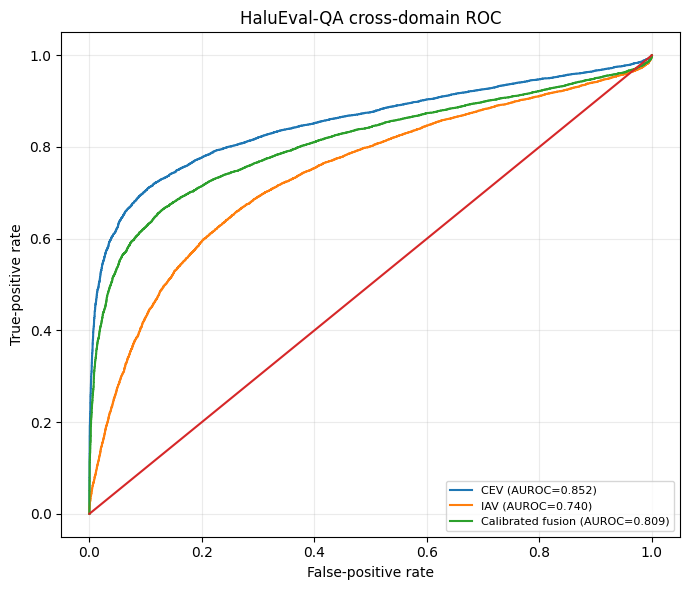

{
  "dataset": "pminervini/HaluEval:qa",
  "split": "data",
  "n_pairs": 10000,
  "n_scored_answers": 20000,
  "cev_auroc_raw": 0.851765045,
  "iav_auroc_raw": 0.7398781650000001,
  "fused_auroc_raw": 0.80939538,
  "fused_auroc_ci_95_lower": 0.8029321869934132,
  "fused_auroc_ci_95_upper": 0.815898018745848,
  "training_or_calibration_use": false,
  "score_orientation": "higher score means greater hallucination risk; no HaluEval-dependent polarity flipping"
}


In [25]:
halueval_auroc_results: Dict[
    str,
    Any,
] = {}
halueval_predictions_df = pd.DataFrame()

if not config.run_optional_halueval:
    print(
        "Optional HaluEval evaluation skipped. "
        "Set config.run_optional_halueval=True "
        "and rerun this cell to execute it."
    )
else:
    print(
        "Loading optional HaluEval-QA..."
    )
    halueval_data = load_dataset(
        "pminervini/HaluEval",
        "qa",
    )
    halueval_split_name = (
        "train"
        if "train" in halueval_data
        else list(
            halueval_data.keys()
        )[0]
    )
    halueval_split = (
        halueval_data[
            halueval_split_name
        ]
    )

    valid_pair_indices: List[int] = []
    for index in range(
        len(
            halueval_split
        )
    ):
        sample = halueval_split[
            int(index)
        ]
        correct_answer = (
            sample.get(
                "right_answer"
            )
            or sample.get(
                "correct_answer"
            )
            or sample.get(
                "answer"
            )
            or ""
        )
        hallucinated_answer = (
            sample.get(
                "hallucinated_answer"
            )
            or sample.get(
                "wrong_answer"
            )
            or sample.get(
                "hallucination"
            )
            or ""
        )
        if (
            str(
                correct_answer
            ).strip()
            and str(
                hallucinated_answer
            ).strip()
        ):
            valid_pair_indices.append(
                int(index)
            )

    if not valid_pair_indices:
        raise RuntimeError(
            "No valid HaluEval correct/"
            "hallucinated answer pairs found."
        )

    rng_halueval = np.random.default_rng(
        config.halueval_seed
    )
    n_pairs = min(
        config.halueval_eval_pairs,
        len(
            valid_pair_indices
        ),
    )
    selected_pair_indices = (
        rng_halueval.choice(
            valid_pair_indices,
            size=n_pairs,
            replace=False,
        )
        .astype(int)
        .tolist()
    )

    halueval_texts: List[str] = []
    halueval_labels: List[int] = []
    halueval_rows: List[
        Dict[str, Any]
    ] = []

    for pair_number, dataset_index in enumerate(
        selected_pair_indices
    ):
        sample = halueval_split[
            int(dataset_index)
        ]
        question = str(
            sample.get(
                "question",
                "",
            )
        ).strip()
        context = str(
            sample.get(
                "knowledge"
            )
            or sample.get(
                "context"
            )
            or sample.get(
                "passage"
            )
            or (
                "[No retrieval context "
                "provided by HaluEval]"
            )
        ).strip()
        correct_answer = str(
            sample.get(
                "right_answer"
            )
            or sample.get(
                "correct_answer"
            )
            or sample.get(
                "answer"
            )
            or ""
        ).strip()
        hallucinated_answer = str(
            sample.get(
                "hallucinated_answer"
            )
            or sample.get(
                "wrong_answer"
            )
            or sample.get(
                "hallucination"
            )
            or ""
        ).strip()

        for label, answer, answer_type in (
            (
                0,
                correct_answer,
                "correct",
            ),
            (
                1,
                hallucinated_answer,
                "hallucinated",
            ),
        ):
            halueval_texts.append(
                build_probe_text(
                    query=question,
                    context=context,
                    response=answer,
                )
            )
            halueval_labels.append(
                int(label)
            )
            halueval_rows.append({
                "pair_number": int(
                    pair_number
                ),
                "dataset_index": int(
                    dataset_index
                ),
                "question": question,
                "context": context,
                "answer": answer,
                "answer_type": (
                    answer_type
                ),
                "label": int(
                    label
                ),
            })

    def score_probe_texts_batched(
        texts: Sequence[str],
        batch_size: int,
    ) -> Dict[str, np.ndarray]:
        cev_probabilities: List[
            np.ndarray
        ] = []
        iav_probabilities: List[
            np.ndarray
        ] = []

        probe_device = next(
            cev_probe.parameters()
        ).device

        with torch.inference_mode():
            for start in tqdm(
                range(
                    0,
                    len(texts),
                    batch_size,
                ),
                desc=(
                    "Optional HaluEval "
                    "probe scoring"
                ),
            ):
                batch_texts = list(
                    texts[
                        start:
                        start
                        + batch_size
                    ]
                )
                raw_cev, raw_iav = (
                    extractor.extract_batch(
                        batch_texts
                    )
                )
                cev_tensor = (
                    torch.from_numpy(
                        raw_cev
                    )
                    .float()
                    .to(
                        probe_device
                    )
                )
                iav_tensor = (
                    torch.from_numpy(
                        raw_iav
                    )
                    .float()
                    .to(
                        probe_device
                    )
                )

                cev_tensor = (
                    cev_tensor
                    - torch.from_numpy(
                        cev_mean
                    )
                    .float()
                    .to(
                        probe_device
                    )
                ) / (
                    torch.from_numpy(
                        cev_std
                    )
                    .float()
                    .to(
                        probe_device
                    )
                    .clamp_min(
                        1e-6
                    )
                )
                iav_tensor = (
                    iav_tensor
                    - torch.from_numpy(
                        iav_mean
                    )
                    .float()
                    .to(
                        probe_device
                    )
                ) / (
                    torch.from_numpy(
                        iav_std
                    )
                    .float()
                    .to(
                        probe_device
                    )
                    .clamp_min(
                        1e-6
                    )
                )

                cev_batch = (
                    torch.softmax(
                        cev_probe(
                            cev_tensor
                        )
                        / config.cev_temperature,
                        dim=1,
                    )[:, 1]
                    .detach()
                    .cpu()
                    .numpy()
                )
                iav_batch = (
                    torch.softmax(
                        iav_probe(
                            iav_tensor
                        )
                        / config.iav_temperature,
                        dim=1,
                    )[:, 1]
                    .detach()
                    .cpu()
                    .numpy()
                )

                cev_probabilities.append(
                    cev_batch
                )
                iav_probabilities.append(
                    iav_batch
                )

        cev_array = np.concatenate(
            cev_probabilities
        ).astype(
            np.float64
        )
        iav_array = np.concatenate(
            iav_probabilities
        ).astype(
            np.float64
        )
        fused_uncalibrated = (
            config.fusion_weight_cev
            * cev_array
            + (
                1.0
                - config.fusion_weight_cev
            )
            * iav_array
        )
        fused_calibrated = apply_platt(
            fused_uncalibrated,
            config.platt_a,
            config.platt_b,
        )

        return {
            "cev_probability": (
                cev_array
            ),
            "iav_probability": (
                iav_array
            ),
            "fused_probability": (
                fused_calibrated
            ),
        }

    halueval_scores = (
        score_probe_texts_batched(
            halueval_texts,
            batch_size=(
                config
                .halueval_batch_size
            ),
        )
    )
    halueval_label_array = np.asarray(
        halueval_labels,
        dtype=np.int64,
    )

    cev_auroc = float(
        roc_auc_score(
            halueval_label_array,
            halueval_scores[
                "cev_probability"
            ],
        )
    )
    iav_auroc = float(
        roc_auc_score(
            halueval_label_array,
            halueval_scores[
                "iav_probability"
            ],
        )
    )
    fused_auroc = float(
        roc_auc_score(
            halueval_label_array,
            halueval_scores[
                "fused_probability"
            ],
        )
    )
    fused_ci_lower, fused_ci_upper = (
        bootstrap_auroc_interval(
            labels=(
                halueval_label_array
            ),
            scores=(
                halueval_scores[
                    "fused_probability"
                ]
            ),
            n_bootstrap=(
                config.bootstrap_samples
            ),
            seed=(
                config.halueval_seed
                + 1
            ),
        )
    )

    halueval_auroc_results = {
        "dataset": (
            "pminervini/HaluEval:qa"
        ),
        "split": (
            halueval_split_name
        ),
        "n_pairs": int(
            n_pairs
        ),
        "n_scored_answers": int(
            len(
                halueval_label_array
            )
        ),
        "cev_auroc_raw": (
            cev_auroc
        ),
        "iav_auroc_raw": (
            iav_auroc
        ),
        "fused_auroc_raw": (
            fused_auroc
        ),
        "fused_auroc_ci_95_lower": (
            fused_ci_lower
        ),
        "fused_auroc_ci_95_upper": (
            fused_ci_upper
        ),
        "training_or_calibration_use": (
            False
        ),
        "score_orientation": (
            "higher score means greater "
            "hallucination risk; no HaluEval-"
            "dependent polarity flipping"
        ),
    }

    for key, values in (
        halueval_scores.items()
    ):
        for row, value in zip(
            halueval_rows,
            values,
        ):
            row[key] = float(
                value
            )

    halueval_predictions_df = (
        pd.DataFrame(
            halueval_rows
        )
    )
    halueval_predictions_df.to_csv(
        HALUEVAL_DIR
        / (
            "halueval_optional_"
            "predictions.csv"
        ),
        index=False,
    )
    write_json(
        HALUEVAL_DIR
        / (
            "halueval_optional_"
            "auroc.json"
        ),
        halueval_auroc_results,
    )

    fig, ax = plt.subplots(
        figsize=(7, 6)
    )
    for name, scores in (
        (
            "CEV",
            halueval_scores[
                "cev_probability"
            ],
        ),
        (
            "IAV",
            halueval_scores[
                "iav_probability"
            ],
        ),
        (
            "Calibrated fusion",
            halueval_scores[
                "fused_probability"
            ],
        ),
    ):
        false_positive_rate, true_positive_rate, _ = (
            roc_curve(
                halueval_label_array,
                scores,
            )
        )
        area = roc_auc_score(
            halueval_label_array,
            scores,
        )
        ax.plot(
            false_positive_rate,
            true_positive_rate,
            label=(
                f"{name} "
                f"(AUROC={area:.3f})"
            ),
        )

    ax.plot(
        [0.0, 1.0],
        [0.0, 1.0],
    )
    ax.set_xlabel(
        "False-positive rate"
    )
    ax.set_ylabel(
        "True-positive rate"
    )
    ax.set_title(
        "HaluEval-QA cross-domain ROC"
    )
    ax.legend(
        fontsize=8,
        loc="lower right",
    )
    ax.grid(
        alpha=0.25
    )
    plt.tight_layout()

    halueval_roc_path = (
        HALUEVAL_DIR
        / "halueval_optional_roc.png"
    )
    plt.savefig(
        halueval_roc_path,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    print(
        json.dumps(
            json_safe(
                halueval_auroc_results
            ),
            indent=2,
        )
    )

## 24. Save the frozen detector, SQuAD-v2 Controller bundle, and run manifest

The saved manifest records the exact detector, disjoint SQuAD-v2 development
partitions, final evaluation sample fingerprint, controller thresholds, and
optional HaluEval status.

In [26]:
probe_bundle = {
    "model_name": (
        config.model_name
    ),
    "target_layer": (
        config.target_layer
    ),
    "hidden_size": (
        config.hidden_size
    ),
    "intermediate_size": (
        config.intermediate_size
    ),
    "probe_text_builder_version": (
        config.probe_text_builder_version
    ),
    "cev_probe_state_dict": {
        key: value.detach().cpu()
        for key, value
        in cev_probe.state_dict().items()
    },
    "iav_probe_state_dict": {
        key: value.detach().cpu()
        for key, value
        in iav_probe.state_dict().items()
    },
    "cev_mean": torch.from_numpy(
        cev_mean
    ),
    "cev_std": torch.from_numpy(
        cev_std
    ),
    "iav_mean": torch.from_numpy(
        iav_mean
    ),
    "iav_std": torch.from_numpy(
        iav_std
    ),
    "calibration": (
        calibration_metadata
    ),
    "training_data_source": (
        "wandb/RAGTruth-processed:train"
    ),
    "test_data_source": (
        "wandb/RAGTruth-processed:test"
    ),
}
probe_bundle_path = (
    CHECKPOINT_DIR
    / (
        "llama3_ragtruth_official_"
        "probe_bundle.pt"
    )
)
torch.save(
    probe_bundle,
    probe_bundle_path,
)

controller_bundle = {
    "controller_code_version": (
        config.controller_code_version
    ),
    "controller_dataset": (
        "rajpurkar/squad_v2"
    ),
    "retrieval_confidence_model": (
        retrieval_confidence_model
    ),
    "retrieval_feature_names": (
        RETRIEVAL_FEATURE_NAMES
    ),
    "answerability_model": (
        answerability_model
    ),
    "answerability_feature_names": (
        ANSWERABILITY_FEATURE_NAMES
    ),
    "candidate_quality_model": (
        candidate_quality_model
    ),
    "candidate_feature_names": (
        CANDIDATE_FEATURE_NAMES
    ),
    "external_only_candidate_model": (
        external_only_candidate_model
    ),
    "external_only_feature_names": (
        EXTERNAL_ONLY_FEATURE_NAMES
    ),
    "external_only_threshold": (
        external_only_threshold
    ),
    "signal_ablation_summary": (
        ablation_summary
    ),
    "thresholds": {
        "retrieval_failure": (
            config
            .retrieval_failure_threshold
        ),
        "no_answer": (
            config.no_answer_threshold
        ),
        "candidate_accept": (
            config
            .candidate_bad_accept_threshold
        ),
        "candidate_abstain": (
            config
            .candidate_bad_abstain_threshold
        ),
        "support_diagnostic": (
            config
            .support_diagnostic_threshold
        ),
        "relevance_diagnostic": (
            config
            .relevance_diagnostic_threshold
        ),
    },
    "training_partitions": (
        squad_v2_partition_metadata
    ),
    "retrieval_calibration": (
        retrieval_calibration_metadata
    ),
    "answerability_calibration": (
        answerability_metadata
    ),
    "candidate_quality_calibration": (
        candidate_quality_metadata
    ),
    "final_controller_fingerprint": (
        controller_fingerprint
    ),
}
controller_bundle_path = (
    CHECKPOINT_DIR
    / (
        "llama3_controller_v5_"
        "squadv2_paper_ablation_bundle.pkl"
    )
)
with controller_bundle_path.open(
    "wb"
) as handle:
    pickle.dump(
        controller_bundle,
        handle,
    )

run_manifest = {
    "run_name": (
        config.run_name
    ),
    "config": asdict(
        config
    ),
    "detector_protocol": {
        "training_source": (
            "wandb/RAGTruth-processed:train"
        ),
        "training_rows": int(
            len(
                ragtruth_data[
                    "train"
                ]
            )
        ),
        "test_source": (
            "wandb/RAGTruth-processed:test"
        ),
        "test_rows": int(
            len(
                ragtruth_data[
                    "test"
                ]
            )
        ),
        "test_metrics": (
            test_metrics
        ),
        "test_used_for_calibration": (
            False
        ),
    },
    "controller_protocol": {
        "dataset": (
            "rajpurkar/squad_v2"
        ),
        "squad_v1_used": (
            False
        ),
        "training_partitions": (
            squad_v2_partition_metadata
        ),
        "retrieval_calibration": (
            retrieval_calibration_metadata
        ),
        "answerability_calibration": (
            answerability_metadata
        ),
        "candidate_quality_calibration": (
            candidate_quality_metadata
        ),
        "signal_ablation": (
            ablation_summary
        ),
        "final_evaluation_spec": (
            controller_run_spec
        ),
        "final_summary": (
            squad_v2_summary
        ),
        "demonstration_categories": (
            demo_summary_df[
                [
                    "Category",
                    "Observed",
                ]
            ].to_dict(
                orient="records"
            )
        ),
    },
    "optional_halueval": {
        "enabled": bool(
            config
            .run_optional_halueval
        ),
        "results": (
            halueval_auroc_results
        ),
        "used_for_training_or_calibration": (
            False
        ),
    },
    "probe_weights_sha256": (
        probe_weights_digest
    ),
    "controller_fingerprint": (
        controller_fingerprint
    ),
}
run_manifest_path = (
    CONTROLLER_OUTPUT_DIR
    / "run_manifest_squadv2_paper_ablation.json"
)
write_json(
    run_manifest_path,
    run_manifest,
)

print({
    "probe_bundle": (
        str(
            probe_bundle_path
        )
    ),
    "controller_bundle": (
        str(
            controller_bundle_path
        )
    ),
    "run_manifest": (
        str(
            run_manifest_path
        )
    ),
    "controller_outputs": (
        str(
            CONTROLLER_OUTPUT_DIR
        )
    ),
})

{'probe_bundle': '/content/drive/MyDrive/llama_colab_a100_ragtruth18k_test_run/checkpoints/llama3_ragtruth_official_probe_bundle.pt', 'controller_bundle': '/content/drive/MyDrive/llama_colab_a100_ragtruth18k_test_run/checkpoints/llama3_controller_v5_squadv2_paper_ablation_bundle.pkl', 'run_manifest': '/content/drive/MyDrive/llama_colab_a100_ragtruth18k_test_run/controller_v5_squadv2_paper_ablation_outputs/run_manifest_squadv2_paper_ablation.json', 'controller_outputs': '/content/drive/MyDrive/llama_colab_a100_ragtruth18k_test_run/controller_v5_squadv2_paper_ablation_outputs'}


## 25. Final runtime verification

This cell validates the official RAGTruth protocol, disjoint SQuAD-v2 development partitions, fresh final evaluation sampling,
controller action consistency, demonstration exports, optional HaluEval
isolation, and saved artifacts.

In [27]:
# Official RAGTruth protocol
assert len(
    ragtruth_data["train"]
) == 15090
assert len(
    ragtruth_data["test"]
) == 2700
assert (
    calibration_metadata[
        "test_used_for_calibration"
    ]
    is False
)
assert (
    calibration_metadata[
        "calibration_source"
    ]
    == (
        "out_of_fold_predictions_"
        "from_ragtruth_train_only"
    )
)

# SQuAD-v2-only controller protocol
assert (
    "squad_train"
    not in globals()
)
assert (
    "squad_validation"
    not in globals()
)
assert len(
    squad_v2_train
) > 0
assert len(
    squad_v2_validation
) > 0
assert (
    squad_v2_partition_metadata[
        "all_partitions_pairwise_disjoint"
    ]
    is True
)
assert set(
    answerability_indices
).isdisjoint(
    set(
        selected_retrieval_calibration_indices
    )
)
assert set(
    answerability_indices
).isdisjoint(
    set(
        controller_dev_indices
    )
)
assert set(
    selected_retrieval_calibration_indices
).isdisjoint(
    set(
        controller_dev_indices
    )
)

# Calibration artifacts
assert len(
    retrieval_calibration_df
) == (
    config
    .retrieval_calibration_queries
)
assert len(
    answerability_df
) == (
    2
    * config
    .answerability_examples_per_class
)
assert len(
    candidate_dev_df
) == (
    config
    .controller_dev_answerable_queries
    + config
    .controller_dev_unanswerable_queries
)
assert (
    candidate_quality_metadata[
        "constraints"
    ]["satisfied"]
    is True
)
assert (
    "raw support and relevance scores"
    in candidate_quality_metadata[
        "support_and_relevance_usage"
    ]
)


# Raw auxiliary outputs are exposed as scores, not calibrated probabilities.
assert "support_score" in (
    CANDIDATE_FEATURE_NAMES
)
assert "relevance_score" in (
    CANDIDATE_FEATURE_NAMES
)
assert "support_entailment" not in (
    CANDIDATE_FEATURE_NAMES
)
assert "relevance_probability" not in (
    CANDIDATE_FEATURE_NAMES
)

# Frozen detector outputs
assert len(
    test_predictions_df
) == 2700
assert np.isfinite(
    test_fused_probabilities
).all()
assert (
    OUTPUT_DIR
    / (
        "ragtruth_official_"
        "test_metrics.json"
    )
).exists()
assert (
    OUTPUT_DIR
    / (
        "ragtruth_official_"
        "test_predictions.csv"
    )
).exists()


# Essential detector figures and training diagnostics
assert training_curve_path.exists()
assert training_history_path.exists()
assert confusion_matrix_path.exists()
assert (
    OUTPUT_DIR
    / "ragtruth_test_roc.png"
).exists()
assert (
    OUTPUT_DIR
    / "ragtruth_test_pr.png"
).exists()
assert (
    OUTPUT_DIR
    / "ragtruth_test_reliability.png"
).exists()

# Fresh final SQuAD-v2 sample
assert set(
    selected_squad_v2_answerable
).isdisjoint(
    previous_v4_answerable
    | previous_v5_answerable
)
assert set(
    selected_squad_v2_unanswerable
).isdisjoint(
    previous_v4_unanswerable
    | previous_v5_unanswerable
)
assert len(
    selected_squad_v2_answerable
) == (
    config
    .squad_v2_answerable_eval_queries
)
assert len(
    selected_squad_v2_unanswerable
) == (
    config
    .squad_v2_unanswerable_eval_queries
)
assert len(
    squad_v2_df
) == (
    config
    .squad_v2_answerable_eval_queries
    + config
    .squad_v2_unanswerable_eval_queries
)

# Controller logic and fixed-context traces
assert (
    CONTROLLER_V5_LOGIC_TESTS_PASSED
)
allowed_actions = {
    "accept",
    "regenerate",
    "abstain",
}
for trace in (
    squad_v2_traces
):
    assert trace[
        "controller_fingerprint"
    ] == controller_fingerprint
    assert trace[
        "status"
    ] in {
        "accepted",
        "abstained",
    }
    assert (
        1
        <= len(
            trace["history"]
        )
        <= config.max_attempts
    )
    assert trace[
        "history"
    ][-1]["action"] in {
        "accept",
        "abstain",
    }
    assert all(
        attempt[
            "action"
        ]
        in allowed_actions
        for attempt
        in trace[
            "history"
        ]
    )
    assert not any(
        attempt[
            "action"
        ]
        == "re_retrieve"
        for attempt
        in trace[
            "history"
        ]
    )
    assert all(
        attempt[
            "retrieved_docs"
        ][0]["source"]
        == "fixed_assigned_context"
        for attempt
        in trace[
            "history"
        ]
    )

assert all(
    "support_score"
    in attempt
    and "relevance_score"
    in attempt
    and "support_entailment"
    not in attempt
    and "relevance_probability"
    not in attempt
    for attempt
    in trace[
        "history"
    ]
)

# Evaluation outputs and figures
assert (
    SQUAD_V2_DIR
    / (
        "controller_v5_squadv2_"
        "final_evaluation.csv"
    )
).exists()
assert (
    SQUAD_V2_DIR
    / (
        "controller_v5_squadv2_"
        "final_summary.json"
    )
).exists()
assert (
    SQUAD_V2_DIR
    / (
        "squad_v2_safety_"
        "utility_metrics.png"
    )
).exists()


# Signal-ablation artifacts and policy coverage
required_ablation_policies = {
    "Vanilla LLaMA",
    "Answerability gate only",
    "External verification without CEV/IAV",
    "Full signals with CEV/IAV",
    "Full multi-action Controller-v5",
}
assert set(
    final_ablation_df[
        "policy"
    ]
) == required_ablation_policies
assert (
    "fused_probability"
    not in EXTERNAL_ONLY_FEATURE_NAMES
)
assert (
    "fused_probability"
    in CANDIDATE_FEATURE_NAMES
)
assert (
    ABLATION_DIR
    / "signal_ablation_development.csv"
).exists()
assert (
    ABLATION_DIR
    / "external_only_operating_points.csv"
).exists()
assert (
    ABLATION_DIR
    / "signal_ablation_final.csv"
).exists()
assert (
    ABLATION_DIR
    / "signal_ablation_summary.json"
).exists()
assert (
    ABLATION_DIR
    / "external_only_candidate_model.pkl"
).exists()
assert ablation_plot_path.exists()
assert {
    "answerability_accuracy_change",
    "false_answer_rate_change",
    "answerable_coverage_change",
    "answerable_overall_f1_change",
}.issubset(
    cev_iav_ablation_bootstrap.keys()
)

# Real evaluation demonstrations
assert len(
    demo_summary_df
) == 6

assert (
    "Accepted unsupported answer"
    in set(
        demo_summary_df[
            "Category"
        ]
    )
)
assert (
    DEMO_DIR
    / (
        "squad_v2_varied_controller_"
        "demonstrations.json"
    )
).exists()
assert (
    DEMO_DIR
    / (
        "squad_v2_varied_controller_"
        "demonstrations_summary.csv"
    )
).exists()

# Optional HaluEval remains isolated from training and calibration
if config.run_optional_halueval:
    assert (
        halueval_auroc_results[
            "training_or_calibration_use"
        ]
        is False
    )
    assert (
        HALUEVAL_DIR
        / (
            "halueval_optional_"
            "auroc.json"
        )
    ).exists()
    assert (
        HALUEVAL_DIR
        / (
            "halueval_optional_"
            "predictions.csv"
        )
    ).exists()
    assert (
        HALUEVAL_DIR
        / (
            "halueval_optional_"
            "roc.png"
        )
    ).exists()
else:
    assert (
        halueval_auroc_results
        == {}
    )

# Final bundles and manifest
assert probe_bundle_path.exists()
assert controller_bundle_path.exists()
assert run_manifest_path.exists()
assert (
    run_manifest[
        "controller_protocol"
    ]["squad_v1_used"]
    is False
)

assert (
    "signal_ablation"
    in run_manifest[
        "controller_protocol"
    ]
)
assert (
    "external_only_candidate_model"
    in controller_bundle
)

print(
    "=" * 78
)
print(
    "FINAL SQUAD-v2 PAPER + ABLATION NOTEBOOK VERIFICATION: PASSED"
)
print(
    "=" * 78
)
print({
    "official_ragtruth_train": (
        len(
            ragtruth_data[
                "train"
            ]
        )
    ),
    "official_ragtruth_test": (
        len(
            ragtruth_data[
                "test"
            ]
        )
    ),
    "squad_v1_used": False,
    "squad_v2_training_partitions_disjoint": True,
    "fresh_squad_v2_answerable": (
        len(
            selected_squad_v2_answerable
        )
    ),
    "fresh_squad_v2_unanswerable": (
        len(
            selected_squad_v2_unanswerable
        )
    ),
    "controller_fingerprint": (
        controller_fingerprint
    ),
    "optional_halueval_enabled": (
        config.run_optional_halueval
    ),
    "essential_visualizations": [
        "probe_oof_training_curves.png",
        "ragtruth_test_roc.png",
        "ragtruth_test_pr.png",
        "ragtruth_test_reliability.png",
        "squad_v2_safety_utility_metrics.png",
        "controller_signal_ablation.png",
        (
            "halueval_optional_roc.png"
            if config.run_optional_halueval
            else "optional_halueval_skipped"
        ),
    ],
    "support_and_relevance_outputs": (
        "renamed_as_scores"
    ),
    "signal_ablation_policies": int(
        len(
            final_ablation_df
        )
    ),
    "removed_redundant_visualizations": [
        "ragtruth_test_confusion_matrix.png",
        "squad_v2_safety_utility_scatter.png",
    ],
    "controller_output_directory": (
        str(
            CONTROLLER_OUTPUT_DIR
        )
    ),
})

FINAL SQUAD-v2 PAPER + ABLATION NOTEBOOK VERIFICATION: PASSED
{'official_ragtruth_train': 15090, 'official_ragtruth_test': 2700, 'squad_v1_used': False, 'squad_v2_training_partitions_disjoint': True, 'fresh_squad_v2_answerable': 500, 'fresh_squad_v2_unanswerable': 500, 'controller_fingerprint': '138ad79ec468cd71', 'optional_halueval_enabled': True, 'essential_visualizations': ['probe_oof_training_curves.png', 'ragtruth_test_roc.png', 'ragtruth_test_pr.png', 'ragtruth_test_reliability.png', 'squad_v2_safety_utility_metrics.png', 'controller_signal_ablation.png', 'halueval_optional_roc.png'], 'support_and_relevance_outputs': 'renamed_as_scores', 'signal_ablation_policies': 5, 'removed_redundant_visualizations': ['ragtruth_test_confusion_matrix.png', 'squad_v2_safety_utility_scatter.png'], 'controller_output_directory': '/content/drive/MyDrive/llama_colab_a100_ragtruth18k_test_run/controller_v5_squadv2_paper_ablation_outputs'}
